[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HisameOgasahara/paper_implementation/blob/main/flow_basic.ipynb)

# flow_basic — FashionMNIST 조건부 Flow 실습

FM → Rectified Flow/Reflow → CM → CTM → Shortcut → MeanFlow 순서로 **무엇을 예측하고 어떻게 학습·생성하는지** 비교한다.
모든 생성 모델은 `meanflow_minimal`의 conditional DiT를 기반으로 독립 학습한다. 공통 입력은 32×32 FashionMNIST와 클래스 라벨이며, Muon+AdamW를 사용한다.

각 절은 **핵심 식 → 학습 → 구현 확인 → 클래스별 조건부 생성 → 결과 해석** 순서다. 학습 목표·시간 분포·teacher 사용은 방법별로 유지한다.
CM은 additive noise 기반 standalone CT 실습, CTM은 FM teacher와 soft consistency를 사용하는 적응 구현이다. 원 논문의 대규모 benchmark 재현과 구분한다.

| 절 | 논문 | 원문 |
| --- | --- | --- |
| FM | Flow Matching for Generative Modeling | [2210.02747](https://arxiv.org/abs/2210.02747) |
| RF | Flow Straight and Fast: Learning to Generate and Transfer Data with Rectified Flow | [2209.03003](https://arxiv.org/abs/2209.03003) |
| CM | Consistency Models | [2303.01469](https://arxiv.org/abs/2303.01469) |
| CTM | Consistency Trajectory Models | [2310.02279](https://arxiv.org/abs/2310.02279) |
| Shortcut | One Step Diffusion via Shortcut Models | [2410.12557](https://arxiv.org/abs/2410.12557) |
| MeanFlow | Mean Flows for One-step Generative Modeling | [2505.13447](https://arxiv.org/abs/2505.13447) |
| Flow Map | Generalised Flow Maps for Few-Step Generative Modelling on Riemannian Manifolds | [2510.21608](https://arxiv.org/abs/2510.21608) |

## 0. 공통 설정

`TRAIN_STEPS=20_000`은 학습 상한이다. `EARLY_STOP_AT`은 **업데이트를 마친 뒤 중단할 절대 step**으로, `None`이면 상한까지 학습한다.
모든 모델(FM, RF1, RF2, CM, CTM, Shortcut, MeanFlow)은 기본적으로 **각각 5,000 step**에서 중단한다.
실습 시간을 제한하는 설정이며, 수렴이나 동일한 생성 품질을 보장하는 임계값은 아니다. 모델별 변경은 `EARLY_STOP_AT`에서 지정한다.
일정 step에서 끊는 방식이며 loss plateau 판정은 사용하지 않는다. 특히 MeanFlow adaptive loss 값만으로 수렴을 판정하지 않는다.

학습률은 minimal처럼 상수다. 조기 종료는 학습률이나 CM curriculum의 20,000-step 기준을 다시 계산하지 않는다.
각 모델 학습 중에도 고정 noise·라벨의 PNG를 저장한다. 학습 셀을 중단하면 가능한 경우 마지막 완료 step의 모델과 optimizer를 저장한다.


In [1]:
# @title 0-1. Install / imports / configuration
%pip -q install datasets scipy pandas matplotlib

import copy
import math
import random
import time
import uuid
from pathlib import Path
from contextlib import contextmanager

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.func import jvp
from torch.utils.data import DataLoader
from datasets import load_dataset
from torchvision import datasets as tv_datasets, transforms
from torchvision.transforms import ToTensor


# 재현성과 실행 장치
SEED = 42
if not torch.cuda.is_available():
    raise RuntimeError(
        "Colab에서 런타임 > 런타임 유형 변경 > T4 GPU를 선택하고 다시 실행하세요."
    )

DEVICE = torch.device("cuda")
print("GPU:", torch.cuda.get_device_name(0))
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.mha.set_fastpath_enabled(False)


# 학습 상한과 모델별 조기 종료
TRAIN_STEPS = 20_000
EARLY_STOP_AT = {
    "FM": 5_000,
    "RF1": 5_000,
    "RF2": 5_000,
    "CM": 5_000,
    "CTM": 5_000,
    "Shortcut": 5_000,
    "MeanFlow": 5_000,
}

# 데이터와 공통 DiT 크기
BATCH_SIZE = 128
IMAGE_SIZE = 32
CHANNELS = 1
PATCH_SIZE = 4
MODEL_DIM = 224
MODEL_DEPTH = 4
MODEL_HEADS = 8
FOURIER_DIM = 128

# 조건부 생성 클래스
NUM_CLASSES = 10
CLASS_NAMES = (
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
)

# Muon + AdamW
MUON_LR = 2e-2
ADAMW_LR = 3e-4
MUON_MOMENTUM = 0.95
MUON_BACKEND = "auto"  # auto / native / fallback; actual backend is saved
WEIGHT_DECAY = 0.0
ADAMW_BETAS = (0.9, 0.99)

# CM / CTM의 학습 target
TARGET_EMA_DECAY = 0.999  # CM/CTM training targets only

# MeanFlow의 시간 샘플링과 손실
P_MEAN = -0.4
P_STD = 1.0
DATA_PROPORTION = 0.75
NORM_EPS = 0.01

# 모델별 학습 설정
CM_GRID_START = 32
CM_GRID_END = 1280
RF_TEACHER_NFE = 32
CTM_TEACHER_NFE = 8
CTM_DENOISE_WEIGHT = 1.0
SHORTCUT_LEVELS = 16
SHORTCUT_FM_FRACTION = 0.75

# 로그와 조건부 생성 결과 저장
LOG_EVERY = 50
DIAG_EVERY = 250
SAMPLE_EVERY = 1000
DIAG_BATCH = 64
SAMPLES_PER_CLASS = 4
SAMPLE_BATCH = 32

# 공통 평가
EVAL_N = 1000
NFE_LIST = [1, 2, 4, 8, 16]
DEFAULT_NFE = {
    "FM": 16,
    "RF1": 16,
    "RF2": 16,
    "CM": 1,
    "CTM": 2,
    "Shortcut": 1,
    "MeanFlow": 1,
}
FEATURE_EPOCHS = 3

# 데이터와 실행 결과 경로
DATA_ROOT = (
    Path("/content/fashion_mnist_data")
    if Path("/content").exists()
    else Path("flow_basic_runs/data")
)
OUTPUT_ROOT = (
    Path("/content/flow_basic_runs")
    if Path("/content").exists()
    else Path("flow_basic_runs")
)
RUN_DIR = OUTPUT_ROOT / (time.strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:8])
RUN_DIR.mkdir(parents=True, exist_ok=False)


def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


seed_all(SEED)
MODELS = {}
LOGS = {}
RUN_INFO = {}
RESULTS = {}
print("device:", DEVICE, "torch:", torch.__version__)
print("run:", RUN_DIR)
print("early stops:", EARLY_STOP_AT)

GPU: Tesla T4
device: cuda torch: 2.11.0+cu128
run: /content/flow_basic_runs/20260909_141832_d56ba99f
early stops: {'FM': 5000, 'RF1': 5000, 'RF2': 5000, 'CM': 5000, 'CTM': 5000, 'Shortcut': 5000, 'MeanFlow': 5000}


README.md:   0%|          | 0.00/9.02k [00:00<?, ?B/s]

fashion_mnist/train-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 30.9MB            

fashion_mnist/train-00000-of-00001.parqu(…): downloading bytes:           |  0.00B            

fashion_mnist/test-00000-of-00001.parque(…): reconstructing file:   0%|          |  0.00B / 5.18MB            

fashion_mnist/test-00000-of-00001.parque(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

FashionMNIST: Hugging Face


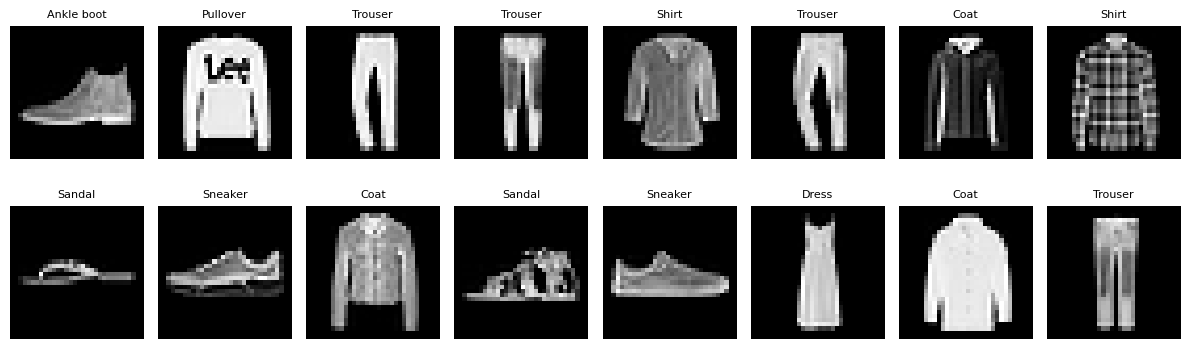

In [2]:
# @title 0-2. FashionMNIST: 28 -> 32 padding, [-1,1], labels
to_tensor = ToTensor()


def transform_image(image):
    image = to_tensor(image)
    padding = (IMAGE_SIZE - image.shape[-1]) // 2

    return F.pad(image, (padding,) * 4, value=0.0) * 2.0 - 1.0


def collate_fashion(batch):
    return (
        torch.stack([transform_image(row["image"]) for row in batch]),
        torch.tensor([row["label"] for row in batch], dtype=torch.long),
    )


try:
    dataset = load_dataset("zalando-datasets/fashion_mnist")
    train_data, test_data = dataset["train"], dataset["test"]
    collate_fn = collate_fashion
    print("FashionMNIST: Hugging Face")
except Exception as error:
    print("Hugging Face download failed; torchvision fallback:", type(error).__name__)
    transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Pad((IMAGE_SIZE - 28) // 2),
            transforms.Normalize((0.5,), (0.5,)),
        ]
    )
    train_data = tv_datasets.FashionMNIST(
        str(DATA_ROOT), train=True, download=True, transform=transform
    )
    test_data = tv_datasets.FashionMNIST(
        str(DATA_ROOT), train=False, download=True, transform=transform
    )
    collate_fn = None

loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
    collate_fn=collate_fn,
    generator=loader_generator,
)
test_loader = DataLoader(
    test_data,
    batch_size=DIAG_BATCH,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
)
preview_images, preview_labels = next(iter(test_loader))
assert preview_images.shape[1:] == (CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
assert preview_images.min() >= -1 and preview_images.max() <= 1
fig, axes = plt.subplots(2, 8, figsize=(12, 4))

for ax, image, label in zip(axes.flat, preview_images, preview_labels):
    ax.imshow((image[0] + 1) / 2, cmap="gray", vmin=0, vmax=1)
    ax.set_title(CLASS_NAMES[int(label)], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

### 공통 conditional DiT

minimal의 별도 시간·구간 임베딩, 클래스 임베딩, adaLN-Zero 초기화, JVP 대응 attention을 사용한다.
`model(z, t, interval, labels)`에서 FM/RF/CM은 `interval=0`, CTM/MeanFlow는 `t-s`, Shortcut은 전진 길이 `d`를 전달한다.
Shortcut은 noise=0 → data=1, 나머지 선형 Flow는 data=0 → noise=1 방향이다.
같은 구조를 공유하되 모델 파라미터는 각각 새로 만든다. 클래스 조건은 모든 teacher·target·sampling 호출에 유지한다.


In [3]:
class ScalarEmbed(nn.Module):
    def __init__(self, dim, fourier_dim=FOURIER_DIM):
        super().__init__()
        self.fourier_dim = fourier_dim
        self.mlp = nn.Sequential(
            nn.Linear(fourier_dim, dim),
            nn.SiLU(),
            nn.Linear(dim, dim),
        )

    def forward(self, scalar):
        half = self.fourier_dim // 2
        frequencies = torch.exp(
            -math.log(10000.0)
            * torch.arange(
                half,
                device=scalar.device,
                dtype=scalar.dtype,
            )
            / half
        )
        phase = scalar[:, None] * frequencies[None, :] * 2.0 * math.pi
        embedding = torch.cat(
            [phase.cos(), phase.sin()],
            dim=-1,
        )

        return self.mlp(embedding)


class Block(nn.Module):
    def __init__(self, dim=MODEL_DIM, heads=MODEL_HEADS):
        super().__init__()
        self.norm1 = nn.LayerNorm(
            dim,
            elementwise_affine=False,
            eps=1e-6,
        )
        self.norm2 = nn.LayerNorm(
            dim,
            elementwise_affine=False,
            eps=1e-6,
        )
        self.attn = nn.MultiheadAttention(
            dim,
            heads,
            batch_first=True,
        )
        self.mlp = nn.Sequential(
            nn.Linear(dim, 4 * dim),
            nn.GELU(approximate="tanh"),
            nn.Linear(4 * dim, dim),
        )
        self.mod = nn.Sequential(
            nn.SiLU(),
            nn.Linear(dim, 6 * dim),
        )
        nn.init.zeros_(self.mod[-1].weight)
        nn.init.zeros_(self.mod[-1].bias)

    def forward(self, tokens, conditioning):
        (
            shift1,
            scale1,
            gate1,
            shift2,
            scale2,
            gate2,
        ) = self.mod(conditioning).chunk(6, dim=-1)

        hidden = self.norm1(tokens)
        hidden = hidden * (1.0 + scale1[:, None, :]) + shift1[:, None, :]
        attended, _ = self.attn(
            hidden,
            hidden,
            hidden,
            need_weights=True,
        )
        tokens = tokens + gate1[:, None, :] * attended

        hidden = self.norm2(tokens)
        hidden = hidden * (1.0 + scale2[:, None, :]) + shift2[:, None, :]

        return tokens + gate2[:, None, :] * self.mlp(hidden)


class CondDiT(nn.Module):
    def __init__(self, dim=MODEL_DIM, depth=MODEL_DEPTH, patch=PATCH_SIZE):
        super().__init__()
        self.patch = patch
        self.grid = IMAGE_SIZE // patch
        self.pe = nn.Conv2d(
            CHANNELS,
            dim,
            patch,
            patch,
        )
        self.pos = nn.Parameter(torch.zeros(1, self.grid**2, dim))
        self.te = ScalarEmbed(dim)
        self.he = ScalarEmbed(dim)
        self.ye = nn.Embedding(NUM_CLASSES, dim)
        self.blocks = nn.ModuleList([Block(dim, MODEL_HEADS) for _ in range(depth)])
        self.norm = nn.LayerNorm(
            dim,
            elementwise_affine=False,
            eps=1e-6,
        )
        self.fmod = nn.Sequential(
            nn.SiLU(),
            nn.Linear(dim, 2 * dim),
        )
        self.out = nn.Linear(
            dim,
            patch * patch * CHANNELS,
        )
        nn.init.normal_(self.pos, std=0.02)
        nn.init.normal_(self.ye.weight, std=0.02)
        nn.init.zeros_(self.fmod[-1].weight)
        nn.init.zeros_(self.fmod[-1].bias)
        nn.init.zeros_(self.out.weight)
        nn.init.zeros_(self.out.bias)

    def forward(self, images, t, interval, labels):
        batch_size = images.shape[0]

        tokens = self.pe(images)
        tokens = tokens.flatten(2).transpose(1, 2)
        tokens = tokens + self.pos

        conditioning = self.te(t) + self.he(interval) + self.ye(labels)

        for block in self.blocks:
            tokens = block(tokens, conditioning)

        shift, scale = self.fmod(conditioning).chunk(2, dim=-1)
        tokens = self.norm(tokens)
        tokens = tokens * (1.0 + scale[:, None, :]) + shift[:, None, :]
        patches = self.out(tokens)
        patches = patches.view(
            batch_size,
            self.grid,
            self.grid,
            self.patch,
            self.patch,
            CHANNELS,
        )
        images_out = torch.einsum(
            "nhwpqc->nchpwq",
            patches,
        )

        return images_out.reshape(
            batch_size,
            CHANNELS,
            IMAGE_SIZE,
            IMAGE_SIZE,
        )


def fresh_model():
    seed_all(SEED)

    return CondDiT().to(DEVICE)

In [4]:
@torch.no_grad()
def ns5(gradient, steps=5, eps=1e-7):
    matrix = gradient.float()
    transpose_back = matrix.shape[0] > matrix.shape[1]

    if transpose_back:
        matrix = matrix.T

    matrix = matrix / (matrix.norm() + eps)

    a = 3.4445
    b = -4.775
    c = 2.0315

    for _ in range(steps):
        gram = matrix @ matrix.T
        matrix = a * matrix + (b * gram + c * gram @ gram) @ matrix

    if transpose_back:
        matrix = matrix.T

    return matrix.to(gradient.dtype)


class MuonFallback(torch.optim.Optimizer):
    def __init__(self, params, lr=0.02, momentum=0.95):
        super().__init__(
            params,
            {
                "lr": lr,
                "momentum": momentum,
            },
        )

    @torch.no_grad()
    def step(self, closure=None):
        for group in self.param_groups:
            for parameter in group["params"]:
                if parameter.grad is None:
                    continue

                state = self.state[parameter]
                buffer = state.setdefault(
                    "momentum_buffer",
                    torch.zeros_like(parameter.grad),
                )
                buffer.mul_(group["momentum"]).add_(parameter.grad)

                update = ns5(parameter.grad + group["momentum"] * buffer)
                update *= math.sqrt(
                    max(
                        1.0,
                        parameter.shape[0] / parameter.shape[1],
                    )
                )
                parameter.add_(
                    update,
                    alpha=-group["lr"],
                )


def build_optimizers(model):
    muon_params, adam_params, muon_names = [], [], []

    for name, parameter in model.named_parameters():
        if parameter.ndim == 2 and (".attn." in name or ".mlp." in name):
            muon_params.append(parameter)
            muon_names.append(name)
        else:
            adam_params.append(parameter)

    assert muon_params and adam_params
    assert len({id(p) for p in muon_params + adam_params}) == len(
        list(model.parameters())
    )
    native = hasattr(torch.optim, "Muon")

    if MUON_BACKEND not in ("auto", "native", "fallback"):
        raise ValueError("Unknown Muon backend")

    if MUON_BACKEND == "native" and not native:
        raise RuntimeError("This PyTorch runtime has no torch.optim.Muon")

    if native and MUON_BACKEND != "fallback":
        muon = torch.optim.Muon(
            muon_params, lr=MUON_LR, momentum=MUON_MOMENTUM, weight_decay=WEIGHT_DECAY
        )
        backend = "torch.optim.Muon"
    else:
        if WEIGHT_DECAY != 0:
            raise ValueError("minimal MuonFallback supports weight_decay=0 only")

        muon = MuonFallback(muon_params, lr=MUON_LR, momentum=MUON_MOMENTUM)
        backend = "minimal MuonFallback"

    adam = torch.optim.AdamW(
        adam_params, lr=ADAMW_LR, betas=ADAMW_BETAS, eps=1e-8, weight_decay=WEIGHT_DECAY
    )

    return (muon, adam), {
        "backend": backend,
        "muon_names": muon_names,
        "muon_tensors": len(muon_params),
        "adamw_tensors": len(adam_params),
    }

### 학습·생성 공통 처리


In [5]:
# @title 공통 함수 — 시간·난수·클래스별 생성
def expand_time(t):
    return t[:, None, None, None]


def infinite(loader):
    while True:
        yield from loader


def freeze_copy(model):
    target = copy.deepcopy(model).eval()
    target.requires_grad_(False)

    return target


@torch.no_grad()
def update_target(target, model):
    for target_p, online_p in zip(target.parameters(), model.parameters()):
        target_p.lerp_(online_p, 1.0 - TARGET_EMA_DECAY)


@contextmanager
def isolated_rng(seed=SEED + 10_000):
    python_state, numpy_state = random.getstate(), np.random.get_state()
    devices = [torch.cuda.current_device()] if DEVICE.type == "cuda" else []

    try:
        with torch.random.fork_rng(devices=devices):
            seed_all(seed)
            yield
    finally:
        random.setstate(python_state)
        np.random.set_state(numpy_state)


def balanced_labels(n):
    if n % NUM_CLASSES:
        raise ValueError("Use a sample count divisible by NUM_CLASSES")

    return torch.arange(NUM_CLASSES, device=DEVICE).repeat_interleave(n // NUM_CLASSES)


def make_noise(n, seed):
    generator = torch.Generator(device=DEVICE).manual_seed(seed)

    return torch.randn(
        n, CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE, generator=generator
    )


@torch.no_grad()
def generate_conditioned(model, sampler, labels, steps, seed=SEED + 10_000):
    labels = torch.as_tensor(labels, dtype=torch.long, device=DEVICE)

    if (
        labels.ndim != 1
        or len(labels) == 0
        or ((labels < 0) | (labels >= NUM_CLASSES)).any()
    ):
        raise ValueError("labels must be a nonempty 1D sequence of class IDs")

    noise = make_noise(len(labels), seed)
    was_training = model.training
    model.eval()

    try:
        outputs = []

        with isolated_rng(seed + 1):
            for start in range(0, len(labels), SAMPLE_BATCH):
                outputs.append(
                    sampler(
                        model,
                        noise[start : start + SAMPLE_BATCH],
                        labels[start : start + SAMPLE_BATCH],
                        steps,
                    ).cpu()
                )

        return torch.cat(outputs)
    finally:
        model.train(was_training)


def show_conditional(model, sampler, name, steps, step=None, save=True):
    labels = balanced_labels(NUM_CLASSES * SAMPLES_PER_CLASS)
    fake = generate_conditioned(model, sampler, labels, steps)
    fig, axes = plt.subplots(
        NUM_CLASSES,
        SAMPLES_PER_CLASS,
        figsize=(SAMPLES_PER_CLASS * 1.8, NUM_CLASSES * 1.35),
        squeeze=False,
    )

    for index, ax in enumerate(axes.flat):
        label = int(labels[index])
        ax.imshow(((fake[index, 0] + 1) / 2).clamp(0, 1), cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"y={label} {CLASS_NAMES[label]}", fontsize=8)
        ax.axis("off")

    caption = f"{name} | conditional | NFE={steps}"

    if step is not None:
        caption += f" | train step={step}"

    fig.suptitle(caption)
    fig.tight_layout()

    if save:
        folder = RUN_DIR / name
        folder.mkdir(parents=True, exist_ok=True)
        suffix = f"{step:05d}" if step is not None else "final"
        fig.savefig(folder / f"conditional_{suffix}_nfe{steps}.png", dpi=140)

    plt.show()
    plt.close(fig)

    return fake


def should_stop(name, step):
    stop_at = EARLY_STOP_AT.get(name)

    return stop_at is not None and step >= stop_at

In [6]:
# @title 체크포인트 — 설정과 학습 상태 저장


def checkpoint_config():
    names = (
        "SEED",
        "TRAIN_STEPS",
        "EARLY_STOP_AT",
        "BATCH_SIZE",
        "IMAGE_SIZE",
        "CHANNELS",
        "PATCH_SIZE",
        "MODEL_DIM",
        "MODEL_DEPTH",
        "MODEL_HEADS",
        "FOURIER_DIM",
        "NUM_CLASSES",
        "MUON_LR",
        "ADAMW_LR",
        "MUON_MOMENTUM",
        "MUON_BACKEND",
        "WEIGHT_DECAY",
        "ADAMW_BETAS",
        "TARGET_EMA_DECAY",
        "P_MEAN",
        "P_STD",
        "DATA_PROPORTION",
        "NORM_EPS",
        "CM_GRID_START",
        "CM_GRID_END",
        "RF_TEACHER_NFE",
        "CTM_TEACHER_NFE",
        "CTM_DENOISE_WEIGHT",
        "SHORTCUT_LEVELS",
        "SHORTCUT_FM_FRACTION",
    )
    config = {name: copy.deepcopy(globals()[name]) for name in names}

    for name in ("CM_SIGMA_MIN", "CM_SIGMA_MAX", "CM_SIGMA_DATA", "CM_RHO"):
        if name in globals():
            config[name] = globals()[name]

    return config


def save_checkpoint(name, model, optimizers, target, step, reason, optimizer_info):
    folder = RUN_DIR / name
    folder.mkdir(parents=True, exist_ok=True)
    state = {
        "method": name,
        "step": step,
        "stop_reason": reason,
        "model": model.state_dict(),
        "optimizers": [opt.state_dict() for opt in optimizers],
        "target": target.state_dict() if target is not None else None,
        "config": checkpoint_config(),
        "optimizer_info": optimizer_info,
        "torch_version": str(torch.__version__),
        "torch_rng": torch.get_rng_state(),
        "cuda_rng": torch.cuda.get_rng_state_all() if DEVICE.type == "cuda" else [],
        "loader_rng": loader_generator.get_state(),
    }
    temporary = folder / "last.tmp"
    torch.save(state, temporary)
    temporary.replace(folder / "last.pt")

In [7]:
# @title 공통 학습 루프 — 업데이트·진단·조기 종료


def train_method(name, model, loss_fn, sampler, target=None, diagnostic=None):
    stop_at = EARLY_STOP_AT.get(name)

    if stop_at is not None and (
        isinstance(stop_at, bool)
        or not isinstance(stop_at, int)
        or not 1 <= stop_at <= TRAIN_STEPS
    ):
        raise ValueError(
            f"{name}: early stop must be None or an integer in [1, TRAIN_STEPS]"
        )

    optimizers, optimizer_info = build_optimizers(model)
    seed_all(SEED)
    loader_generator.manual_seed(SEED)
    iterator = infinite(train_loader)
    logs, started, completed, reason = [], time.perf_counter(), 0, "max_steps"
    model.train()
    print(name, optimizer_info["backend"], "max=", TRAIN_STEPS, "stop_at=", stop_at)

    try:
        for step in range(1, TRAIN_STEPS + 1):
            images, labels = next(iterator)
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            for optimizer in optimizers:
                optimizer.zero_grad(set_to_none=True)
            # Match minimal: FP32 (TF32 allowed), no autocast or gradient clipping.

            loss, auxiliary = loss_fn(model, images, labels, step)

            if not torch.isfinite(loss):
                raise FloatingPointError(f"{name}: nonfinite loss at step {step}")

            loss.backward()
            norm_sq = torch.zeros((), device=DEVICE)

            for parameter in model.parameters():
                if parameter.grad is not None:
                    norm_sq += parameter.grad.detach().float().square().sum()

            if not torch.isfinite(norm_sq):
                raise FloatingPointError(
                    f"{name}: nonfinite gradient norm at step {step}"
                )

            for optimizer in optimizers:
                optimizer.step()

            if target is not None:
                update_target(target, model)

            completed = step
            final_step = should_stop(name, step) or step == TRAIN_STEPS
            log_now = step == 1 or step % LOG_EVERY == 0 or final_step

            if log_now:
                row = {
                    "step": step,
                    "loss": float(loss.detach()),
                    "grad_norm": float(norm_sq.sqrt()),
                }
                row.update({key: float(value) for key, value in auxiliary.items()})

                if diagnostic is not None and (step % DIAG_EVERY == 0 or final_step):
                    with isolated_rng():
                        row.update(diagnostic(model))

                logs.append(row)
                print(name, row)

            if step % SAMPLE_EVERY == 0 and not final_step:
                save_checkpoint(
                    name, model, optimizers, target, step, "running", optimizer_info
                )
                show_conditional(model, sampler, name, DEFAULT_NFE[name], step=step)

            if should_stop(name, step):
                reason = "early_stop_at"
                break
    except KeyboardInterrupt:
        reason = "interrupted"
        print(
            f"{name}: interrupted; saving current state after {completed} completed steps"
        )
    except Exception:
        save_checkpoint(
            name, model, optimizers, target, completed, "failed", optimizer_info
        )
        raise

    elapsed = time.perf_counter() - started
    save_checkpoint(name, model, optimizers, target, completed, reason, optimizer_info)
    frame = pd.DataFrame(logs)
    frame.to_csv(RUN_DIR / name / "training.csv", index=False)
    MODELS[name] = model.eval()
    LOGS[name] = frame
    RUN_INFO[name] = {
        "train_steps": completed,
        "train_s": elapsed,
        "stop_reason": reason,
        "optimizer_backend": optimizer_info["backend"],
    }
    print(name, RUN_INFO[name], "checkpoint:", RUN_DIR / name / "last.pt")

    return model


def show_training(name):
    frame = LOGS[name]
    display(frame.tail())

    if not frame.empty:
        columns = [
            c for c in ("loss", "raw_mse", "boundary_mse", "interval_mse") if c in frame
        ]
        frame.plot(x="step", y=columns, subplots=True, figsize=(8, 2.5 * len(columns)))
        plt.show()

In [8]:
# @title 0-4. Data-independent preflight: shape / independent conditions / JVP
def verify_common_model():
    model = fresh_model()
    z = make_noise(2, SEED)
    t = torch.full((2,), 0.7, device=DEVICE)
    r = torch.full((2,), 0.2, device=DEVICE)
    labels = torch.arange(2, device=DEVICE) % NUM_CLASSES
    assert model(z, t, t - r, labels).shape == z.shape
    # The zero output head intentionally makes all initial predictions zero.
    # Inspect conditioning itself instead of expecting different initial images.
    c1 = model.te(t) + model.he(r)
    c2 = model.te(r) + model.he(t)
    assert not torch.allclose(c1, c2)
    velocity = torch.randn_like(z)
    out, derivative = jvp(
        lambda zz, tt, rr: model(zz, tt, tt - rr, labels),
        (z, t, r),
        (velocity, torch.ones_like(t), torch.zeros_like(r)),
    )
    assert torch.isfinite(derivative).all()
    (
        out - (velocity - expand_time(t - r) * derivative).detach()
    ).square().mean().backward()
    assert (
        model.out.weight.grad is not None
        and torch.isfinite(model.out.weight.grad).all()
    )
    print("Common DiT forward / role separation / JVP backward: PASS")
    print("parameters:", sum(p.numel() for p in model.parameters()))


verify_common_model()

Common DiT forward / role separation / JVP backward: PASS
parameters: 3909488


### 공통 생성 평가

평가용 FashionMNIST 분류기는 중앙 28×28 영역을 사용한다. 생성 이미지에도 동일한 crop과 `[-1,1]` clipping을 적용한다.
feature-FID/KID는 이 분류기 특징에서 계산하는 실습 지표다. 원 논문의 Inception FID와 숫자를 비교하지 않는다.
클래스별 동일 개수의 실제·생성 샘플을 사용하고, 요청 라벨과 분류 예측의 일치율도 기록한다. 분류기 자체의 test accuracy를 먼저 확인한다.
최종 평가 데이터는 조기 종료 판단에 사용하지 않는다. 모든 방법에서 고정 noise·라벨·샘플 개수·NFE를 유지한다.


In [9]:
# @title 0-5. Feature classifier and balanced evaluation set
class FashionFeatures(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(CHANNELS, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Linear(64 * 7 * 7, 128)
        self.cls = nn.Linear(128, NUM_CLASSES)

    def forward(self, images, features=False):
        margin = (images.shape[-1] - 28) // 2
        images = images[..., margin : margin + 28, margin : margin + 28].clamp(-1, 1)
        hidden = F.relu(self.fc(self.conv(images).flatten(1)))

        return hidden if features else self.cls(hidden)


seed_all(SEED)
featnet = FashionFeatures().to(DEVICE)
feature_optimizer = torch.optim.Adam(featnet.parameters(), lr=1e-3)

for epoch in range(FEATURE_EPOCHS):
    featnet.train()

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        feature_optimizer.zero_grad(set_to_none=True)
        loss = F.cross_entropy(featnet(images), labels)
        loss.backward()
        feature_optimizer.step()

    print("feature classifier epoch", epoch + 1, "loss", float(loss.detach()))

featnet.eval().requires_grad_(False)


@torch.no_grad()
def collect_evaluation_data():
    if EVAL_N % NUM_CLASSES:
        raise ValueError("EVAL_N must be divisible by NUM_CLASSES")

    per_class = EVAL_N // NUM_CLASSES
    buckets = [[] for _ in range(NUM_CLASSES)]
    correct, total = 0, 0

    for images, labels in test_loader:
        predictions = featnet(images.to(DEVICE)).argmax(1).cpu()
        correct += (predictions == labels).sum().item()
        total += len(labels)

        for image, label in zip(images, labels):
            bucket = buckets[int(label)]

            if len(bucket) < per_class:
                bucket.append(image)

    assert all(len(bucket) == per_class for bucket in buckets)

    return torch.stack(
        [image for bucket in buckets for image in bucket]
    ), correct / total


real_eval, classifier_accuracy = collect_evaluation_data()
print("feature classifier test accuracy:", classifier_accuracy)


@torch.no_grad()
def extract_features(images):
    return (
        torch.cat(
            [
                featnet(batch.to(DEVICE), features=True).cpu()
                for batch in images.split(SAMPLE_BATCH)
            ]
        )
        .numpy()
        .astype(np.float64)
    )


real_features = extract_features(real_eval)


def fid_np(real, fake):
    delta = real.mean(0) - fake.mean(0)
    real_cov, fake_cov = np.cov(real, rowvar=False), np.cov(fake, rowvar=False)
    root = sqrtm(real_cov @ fake_cov)

    if np.iscomplexobj(root):
        root = root.real

    return float(delta @ delta + np.trace(real_cov + fake_cov - 2 * root))


def kid_np(real, fake):
    n, m, dim = len(real), len(fake), real.shape[1]
    aa, bb, ab = (
        (real @ real.T / dim + 1) ** 3,
        (fake @ fake.T / dim + 1) ** 3,
        (real @ fake.T / dim + 1) ** 3,
    )

    return float(
        (aa.sum() - np.trace(aa)) / (n * (n - 1))
        + (bb.sum() - np.trace(bb)) / (m * (m - 1))
        - 2 * ab.mean()
    )


@torch.no_grad()
def quality_metrics(fake, labels):
    fake = fake.cpu().clamp(-1, 1)
    features = extract_features(fake)
    predictions = torch.cat(
        [
            featnet(batch.to(DEVICE)).argmax(1).cpu()
            for batch in fake.split(SAMPLE_BATCH)
        ]
    )
    histogram = predictions.bincount(minlength=NUM_CLASSES).float() / len(predictions)

    return {
        "feature_fid": fid_np(real_features, features),
        "kid": kid_np(real_features, features),
        "condition_accuracy": float((predictions == labels.cpu()).float().mean()),
        "class_entropy": float(-(histogram * histogram.clamp_min(1e-12).log()).sum()),
    }


def evaluate_method(name, sampler, steps=None):
    steps = DEFAULT_NFE[name] if steps is None else steps
    labels = balanced_labels(EVAL_N)
    started = time.perf_counter()
    fake = generate_conditioned(MODELS[name], sampler, labels, steps)
    metrics = quality_metrics(fake, labels)
    metrics.update(RUN_INFO[name])
    metrics.update(nfe=steps, eval_s=time.perf_counter() - started)
    RESULTS[name] = metrics
    print(name, metrics)

    return fake

feature classifier epoch 1 loss 0.30369871854782104
feature classifier epoch 2 loss 0.2801416218280792
feature classifier epoch 3 loss 0.1900724321603775
feature classifier test accuracy: 0.8928


## 1. Flow Matching — 순간 속도

\(z_t=(1-t)x+t\epsilon\), \(v_t=\epsilon-x\)로 구성하고 \(v_\theta(z_t,t,y)\)를 MSE로 회귀한다.
조건부 생성은 고정 클래스 \(y\)에서 noise \(t=1\)부터 data \(t=0\)까지 ODE를 적분한다.
이 절의 conditional은 클래스 조건이다. 논문의 conditional probability path에서 말하는 conditional과 구분한다.
**적응:** 선형 path, 소형 conditional DiT, FashionMNIST, Muon+AdamW.


In [10]:
# @title FM — objective / sampler
def fm_loss(model, images, labels, step):
    t = torch.rand(len(images), device=DEVICE)
    noise = torch.randn_like(images)
    z = (1 - expand_time(t)) * images + expand_time(t) * noise
    prediction = model(z, t, torch.zeros_like(t), labels)
    loss = F.mse_loss(prediction, noise - images)

    return loss, {"raw_mse": loss.detach()}


@torch.no_grad()
def integrate_fm(model, z, t, s, labels, steps, return_traj=False):
    if steps < 1:
        raise ValueError("steps must be positive")

    trajectory = [z.cpu()] if return_traj else None
    dt = (s - t) / steps

    for k in range(steps):
        tau = t + (s - t) * (k / steps)
        z = z + expand_time(dt) * model(z, tau, torch.zeros_like(tau), labels)

        if return_traj:
            trajectory.append(z.cpu())

    return (z, torch.stack(trajectory)) if return_traj else z


@torch.no_grad()
def sample_fm(model, noise, labels, steps):
    t = torch.ones(len(noise), device=noise.device)

    return integrate_fm(model, noise, t, torch.zeros_like(t), labels, steps)

FM torch.optim.Muon max= 20000 stop_at= 5000
FM {'step': 1, 'loss': 1.7448891401290894, 'grad_norm': 3.2483253479003906, 'raw_mse': 1.7448891401290894}
FM {'step': 50, 'loss': 0.5905086994171143, 'grad_norm': 2.008925676345825, 'raw_mse': 0.5905086994171143}
FM {'step': 100, 'loss': 0.38682204484939575, 'grad_norm': 1.0074948072433472, 'raw_mse': 0.38682204484939575}
FM {'step': 150, 'loss': 0.3091067671775818, 'grad_norm': 0.6496219635009766, 'raw_mse': 0.3091067671775818}
FM {'step': 200, 'loss': 0.2799309492111206, 'grad_norm': 0.7709543704986572, 'raw_mse': 0.2799309492111206}
FM {'step': 250, 'loss': 0.27372533082962036, 'grad_norm': 0.7775213718414307, 'raw_mse': 0.27372533082962036}
FM {'step': 300, 'loss': 0.25589796900749207, 'grad_norm': 1.0496327877044678, 'raw_mse': 0.25589796900749207}
FM {'step': 350, 'loss': 0.25942590832710266, 'grad_norm': 0.9626057744026184, 'raw_mse': 0.25942590832710266}
FM {'step': 400, 'loss': 0.2442641407251358, 'grad_norm': 0.9499398469924927, '

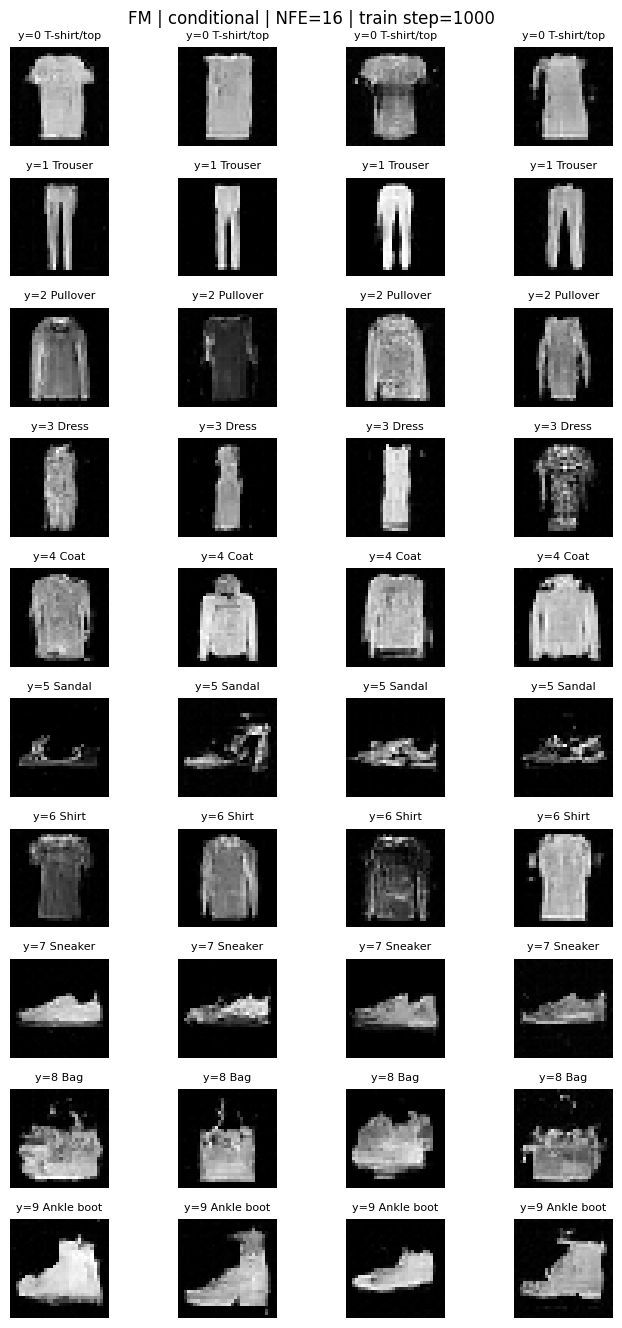

FM {'step': 1050, 'loss': 0.19868886470794678, 'grad_norm': 0.7708961367607117, 'raw_mse': 0.19868886470794678}
FM {'step': 1100, 'loss': 0.18538489937782288, 'grad_norm': 0.5446696281433105, 'raw_mse': 0.18538489937782288}
FM {'step': 1150, 'loss': 0.1889374703168869, 'grad_norm': 0.4715034067630768, 'raw_mse': 0.1889374703168869}
FM {'step': 1200, 'loss': 0.17095524072647095, 'grad_norm': 0.47941115498542786, 'raw_mse': 0.17095524072647095}
FM {'step': 1250, 'loss': 0.17418090999126434, 'grad_norm': 0.3801959156990051, 'raw_mse': 0.17418090999126434}
FM {'step': 1300, 'loss': 0.18399877846240997, 'grad_norm': 0.7889827489852905, 'raw_mse': 0.18399877846240997}
FM {'step': 1350, 'loss': 0.168954998254776, 'grad_norm': 0.4672037959098816, 'raw_mse': 0.168954998254776}
FM {'step': 1400, 'loss': 0.17966203391551971, 'grad_norm': 0.6024520993232727, 'raw_mse': 0.17966203391551971}
FM {'step': 1450, 'loss': 0.2063988894224167, 'grad_norm': 0.8542271256446838, 'raw_mse': 0.2063988894224167}

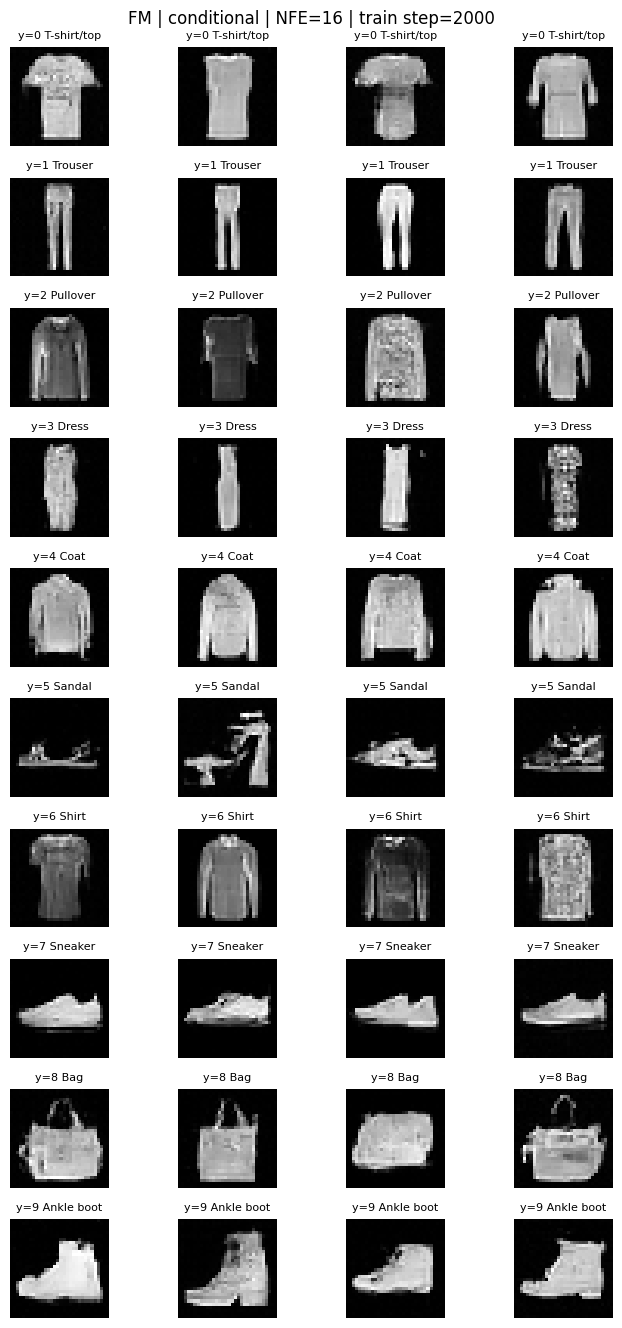

FM {'step': 2050, 'loss': 0.17542001605033875, 'grad_norm': 0.4556370973587036, 'raw_mse': 0.17542001605033875}
FM {'step': 2100, 'loss': 0.1719692200422287, 'grad_norm': 0.3611341118812561, 'raw_mse': 0.1719692200422287}
FM {'step': 2150, 'loss': 0.18594276905059814, 'grad_norm': 0.5071843862533569, 'raw_mse': 0.18594276905059814}
FM {'step': 2200, 'loss': 0.15789200365543365, 'grad_norm': 0.48384684324264526, 'raw_mse': 0.15789200365543365}
FM {'step': 2250, 'loss': 0.176435649394989, 'grad_norm': 0.3123907744884491, 'raw_mse': 0.176435649394989}
FM {'step': 2300, 'loss': 0.1716008484363556, 'grad_norm': 0.511378824710846, 'raw_mse': 0.1716008484363556}
FM {'step': 2350, 'loss': 0.1716681718826294, 'grad_norm': 0.5425945520401001, 'raw_mse': 0.1716681718826294}
FM {'step': 2400, 'loss': 0.16567644476890564, 'grad_norm': 0.3498865067958832, 'raw_mse': 0.16567644476890564}
FM {'step': 2450, 'loss': 0.17021773755550385, 'grad_norm': 0.5279520153999329, 'raw_mse': 0.17021773755550385}
FM

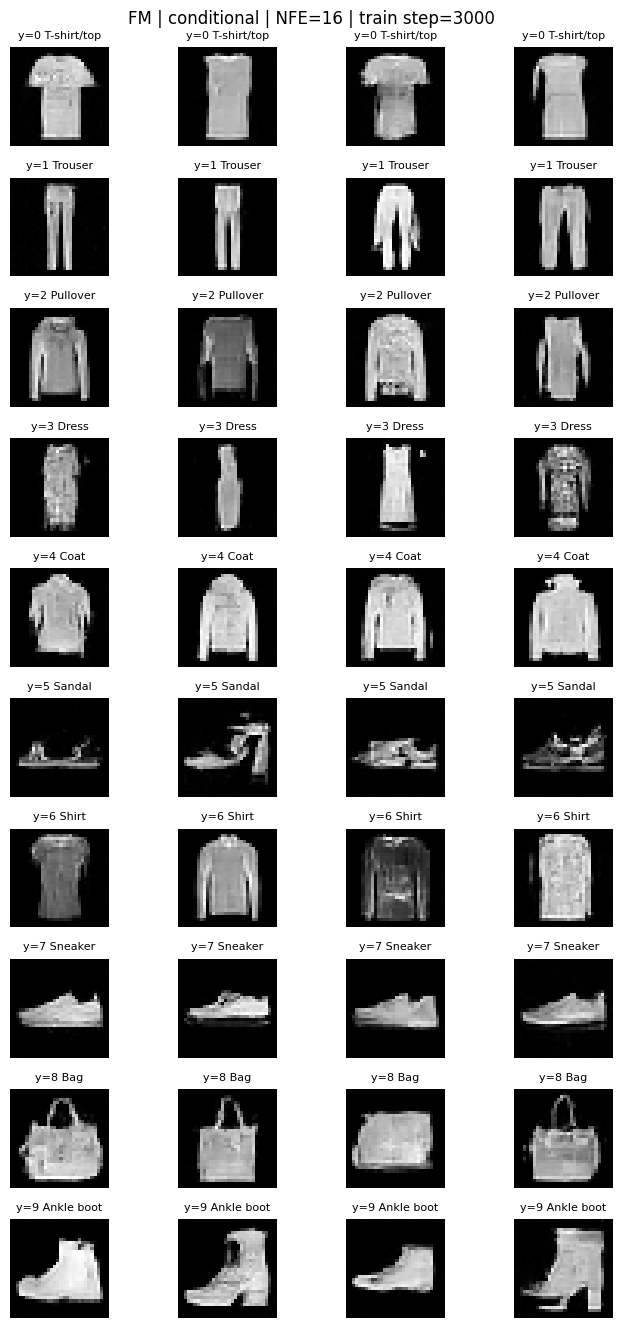

FM {'step': 3050, 'loss': 0.17444919049739838, 'grad_norm': 0.37476876378059387, 'raw_mse': 0.17444919049739838}
FM {'step': 3100, 'loss': 0.14790646731853485, 'grad_norm': 0.374257355928421, 'raw_mse': 0.14790646731853485}
FM {'step': 3150, 'loss': 0.16893018782138824, 'grad_norm': 0.4621734321117401, 'raw_mse': 0.16893018782138824}
FM {'step': 3200, 'loss': 0.1845238208770752, 'grad_norm': 0.4437066316604614, 'raw_mse': 0.1845238208770752}
FM {'step': 3250, 'loss': 0.16710299253463745, 'grad_norm': 0.46037232875823975, 'raw_mse': 0.16710299253463745}
FM {'step': 3300, 'loss': 0.15941265225410461, 'grad_norm': 0.4861096739768982, 'raw_mse': 0.15941265225410461}
FM {'step': 3350, 'loss': 0.1724468171596527, 'grad_norm': 0.4418128728866577, 'raw_mse': 0.1724468171596527}
FM {'step': 3400, 'loss': 0.1732495129108429, 'grad_norm': 0.38986530900001526, 'raw_mse': 0.1732495129108429}
FM {'step': 3450, 'loss': 0.17584986984729767, 'grad_norm': 0.5201621651649475, 'raw_mse': 0.175849869847297

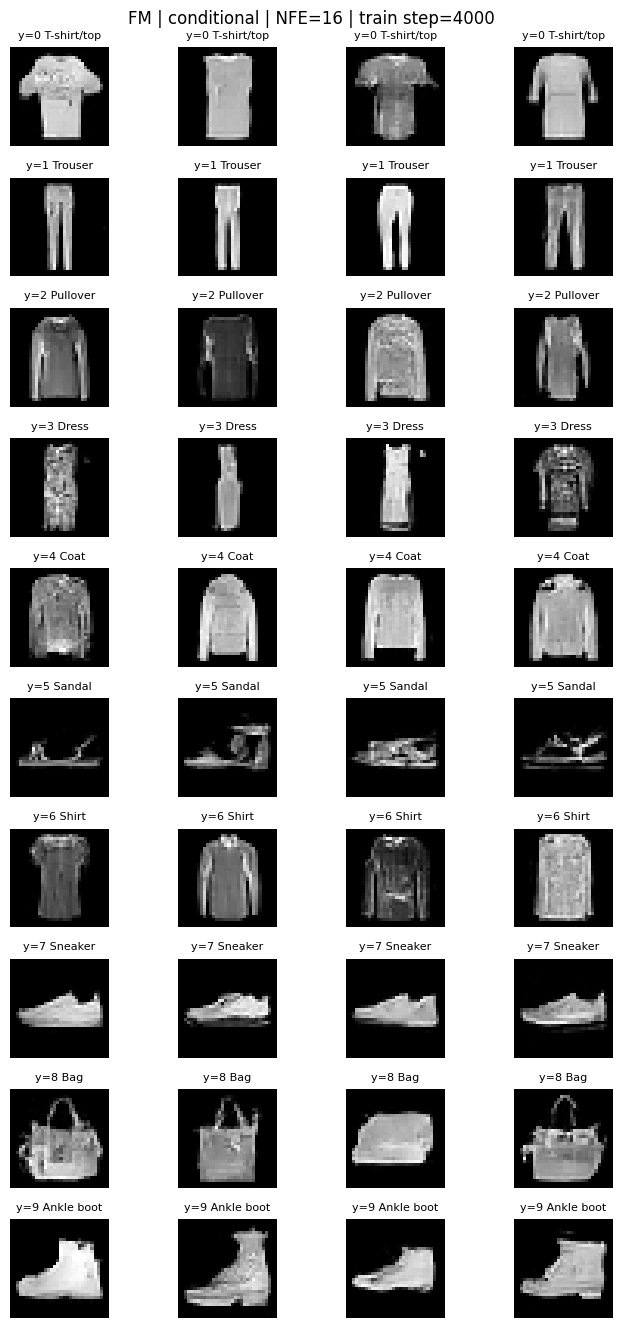

FM {'step': 4050, 'loss': 0.18481171131134033, 'grad_norm': 0.5860993266105652, 'raw_mse': 0.18481171131134033}
FM {'step': 4100, 'loss': 0.17476001381874084, 'grad_norm': 0.8384832143783569, 'raw_mse': 0.17476001381874084}
FM {'step': 4150, 'loss': 0.17099127173423767, 'grad_norm': 0.47815001010894775, 'raw_mse': 0.17099127173423767}
FM {'step': 4200, 'loss': 0.17959484457969666, 'grad_norm': 0.3817416727542877, 'raw_mse': 0.17959484457969666}
FM {'step': 4250, 'loss': 0.16918016970157623, 'grad_norm': 0.5125827193260193, 'raw_mse': 0.16918016970157623}
FM {'step': 4300, 'loss': 0.163030207157135, 'grad_norm': 0.46328628063201904, 'raw_mse': 0.163030207157135}
FM {'step': 4350, 'loss': 0.1573045551776886, 'grad_norm': 0.5749916434288025, 'raw_mse': 0.1573045551776886}
FM {'step': 4400, 'loss': 0.1682167798280716, 'grad_norm': 0.45767325162887573, 'raw_mse': 0.1682167798280716}
FM {'step': 4450, 'loss': 0.1766708642244339, 'grad_norm': 0.4188052713871002, 'raw_mse': 0.1766708642244339}

,step,loss,grad_norm,raw_mse
96,4800,0.183111,0.489943,0.183111
97,4850,0.176765,0.417896,0.176765
98,4900,0.157712,0.342923,0.157712
99,4950,0.152911,0.385041,0.152911
100,5000,0.169919,0.449039,0.169919


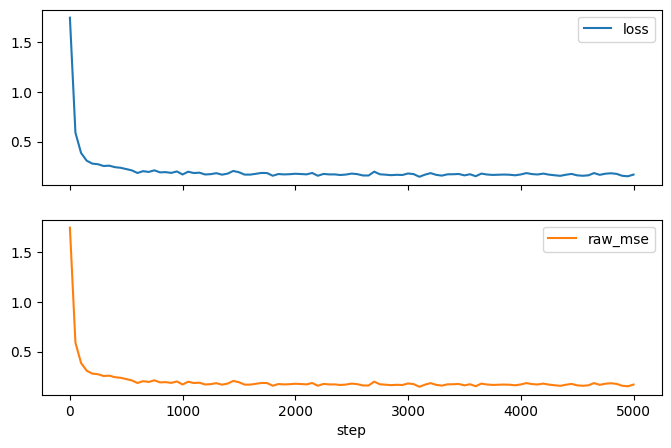

In [11]:
fm = train_method("FM", fresh_model(), fm_loss, sample_fm)
show_training("FM")

FM Euler sign / one-step update: PASS


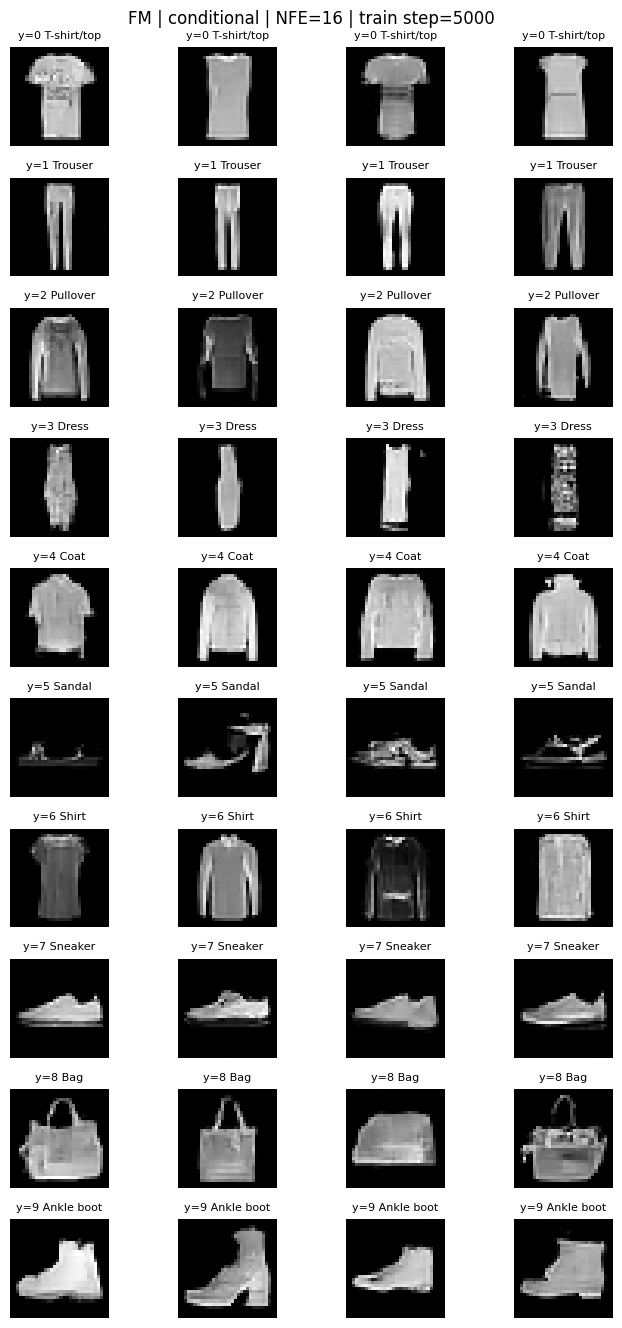

FM {'feature_fid': 16.4032913643443, 'kid': 11.831840693237211, 'condition_accuracy': 0.8759999871253967, 'class_entropy': 2.287550926208496, 'train_steps': 5000, 'train_s': 527.9020876010001, 'stop_reason': 'early_stop_at', 'optimizer_backend': 'torch.optim.Muon', 'nfe': 16, 'eval_s': 3.734361339999964}


/tmp/ipykernel_528/304162648.py:94: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root = sqrtm(real_cov @ fake_cov)


In [12]:
# @title FM — update verification and class-conditioned generation
z, y = make_noise(NUM_CLASSES, SEED), torch.arange(NUM_CLASSES, device=DEVICE)
t = torch.ones(NUM_CLASSES, device=DEVICE)

with torch.no_grad():
    assert torch.allclose(sample_fm(fm, z, y, 1), z - fm(z, t, torch.zeros_like(t), y))

print("FM Euler sign / one-step update: PASS")
show_conditional(fm, sample_fm, "FM", DEFAULT_NFE["FM"], RUN_INFO["FM"]["train_steps"])
fm_samples = evaluate_method("FM", sample_fm)

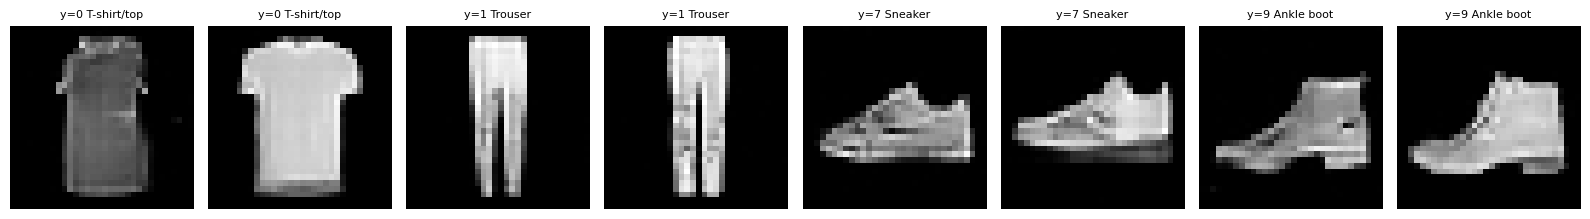

In [13]:
# @title FM — 원하는 클래스 직접 생성 (라벨·seed·NFE 수정)
# 0 T-shirt, 1 Trouser, 2 Pullover, 3 Dress, 4 Coat,
# 5 Sandal, 6 Shirt, 7 Sneaker, 8 Bag, 9 Ankle boot
requested_labels = [0, 0, 1, 1, 7, 7, 9, 9]
requested_nfe = DEFAULT_NFE["FM"]
requested_seed = SEED + 20_000
custom_images = generate_conditioned(
    MODELS["FM"], sample_fm, requested_labels, requested_nfe, seed=requested_seed
)
fig, axes = plt.subplots(
    1, len(requested_labels), figsize=(2 * len(requested_labels), 2.5), squeeze=False
)

for ax, image, label in zip(axes.flat, custom_images, requested_labels):
    ax.imshow(((image[0] + 1) / 2).clamp(0, 1), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"y={label} {CLASS_NAMES[label]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2. Rectified Flow + Reflow — coupling 바꾸기

1-RF의 선형 회귀식은 앞의 FM과 같다. 동일 초기화·seed·설정으로 학습하면 두 결과가 같아지는 것이 자연스럽다.
2-RF는 고정한 1-RF에서 \(\epsilon \mapsto \hat x\)를 생성하고 \((\epsilon,\hat x,y)\)를 유지해 새 직선 경로를 학습한다.
synthetic endpoint는 배치마다 생성한다. 재학습 비용에는 teacher 적분이 포함된다. 생성 시에도 같은 클래스 조건을 유지한다.


RF1 torch.optim.Muon max= 20000 stop_at= 5000
RF1 {'step': 1, 'loss': 1.7448891401290894, 'grad_norm': 3.2483253479003906, 'raw_mse': 1.7448891401290894}
RF1 {'step': 50, 'loss': 0.5897352695465088, 'grad_norm': 1.9905399084091187, 'raw_mse': 0.5897352695465088}
RF1 {'step': 100, 'loss': 0.38623476028442383, 'grad_norm': 0.9191213250160217, 'raw_mse': 0.38623476028442383}
RF1 {'step': 150, 'loss': 0.30967977643013, 'grad_norm': 0.7580433487892151, 'raw_mse': 0.30967977643013}
RF1 {'step': 200, 'loss': 0.27804699540138245, 'grad_norm': 0.6615052223205566, 'raw_mse': 0.27804699540138245}
RF1 {'step': 250, 'loss': 0.2752940058708191, 'grad_norm': 0.9413850903511047, 'raw_mse': 0.2752940058708191}
RF1 {'step': 300, 'loss': 0.25645706057548523, 'grad_norm': 0.9467335343360901, 'raw_mse': 0.25645706057548523}
RF1 {'step': 350, 'loss': 0.2560191750526428, 'grad_norm': 0.9401437044143677, 'raw_mse': 0.2560191750526428}
RF1 {'step': 400, 'loss': 0.24381385743618011, 'grad_norm': 0.9807672500610

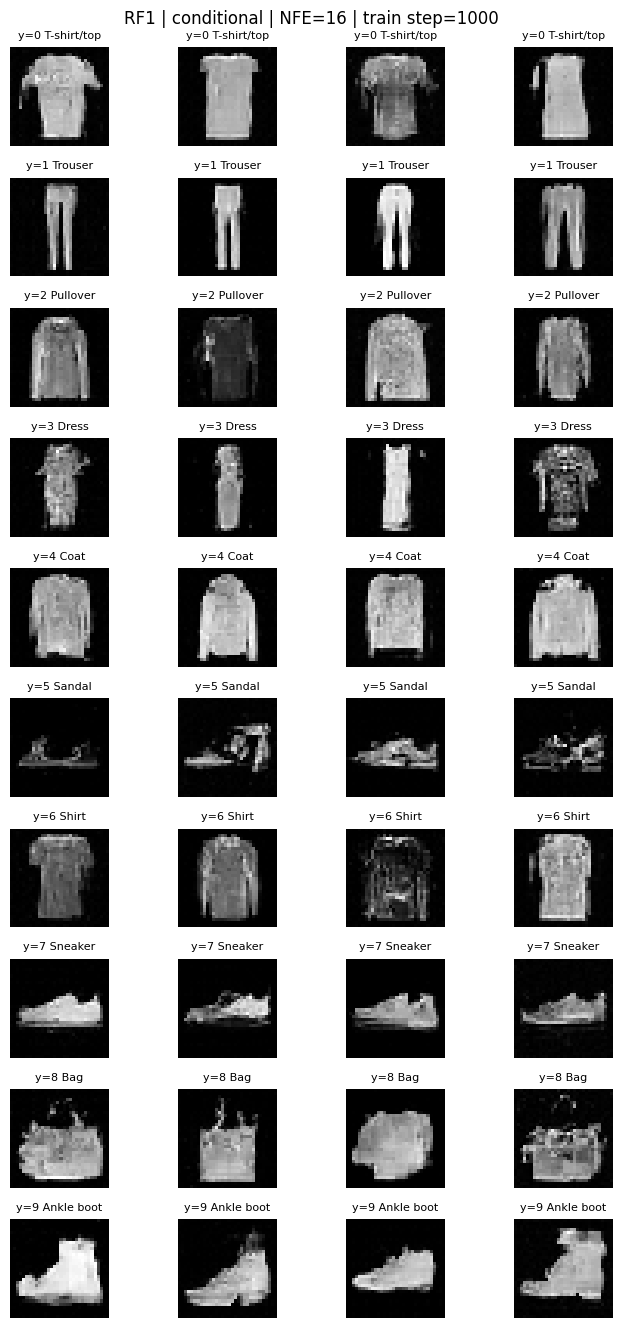

RF1 {'step': 1050, 'loss': 0.19721171259880066, 'grad_norm': 0.5363630056381226, 'raw_mse': 0.19721171259880066}
RF1 {'step': 1100, 'loss': 0.1846550852060318, 'grad_norm': 0.5390543341636658, 'raw_mse': 0.1846550852060318}
RF1 {'step': 1150, 'loss': 0.18846610188484192, 'grad_norm': 0.5532002449035645, 'raw_mse': 0.18846610188484192}
RF1 {'step': 1200, 'loss': 0.1714942753314972, 'grad_norm': 0.47824549674987793, 'raw_mse': 0.1714942753314972}
RF1 {'step': 1250, 'loss': 0.17456376552581787, 'grad_norm': 0.5055384635925293, 'raw_mse': 0.17456376552581787}
RF1 {'step': 1300, 'loss': 0.18224427103996277, 'grad_norm': 0.6008532643318176, 'raw_mse': 0.18224427103996277}
RF1 {'step': 1350, 'loss': 0.16964557766914368, 'grad_norm': 0.46336477994918823, 'raw_mse': 0.16964557766914368}
RF1 {'step': 1400, 'loss': 0.17974084615707397, 'grad_norm': 0.5805927515029907, 'raw_mse': 0.17974084615707397}
RF1 {'step': 1450, 'loss': 0.20628798007965088, 'grad_norm': 0.7040975689888, 'raw_mse': 0.2062879

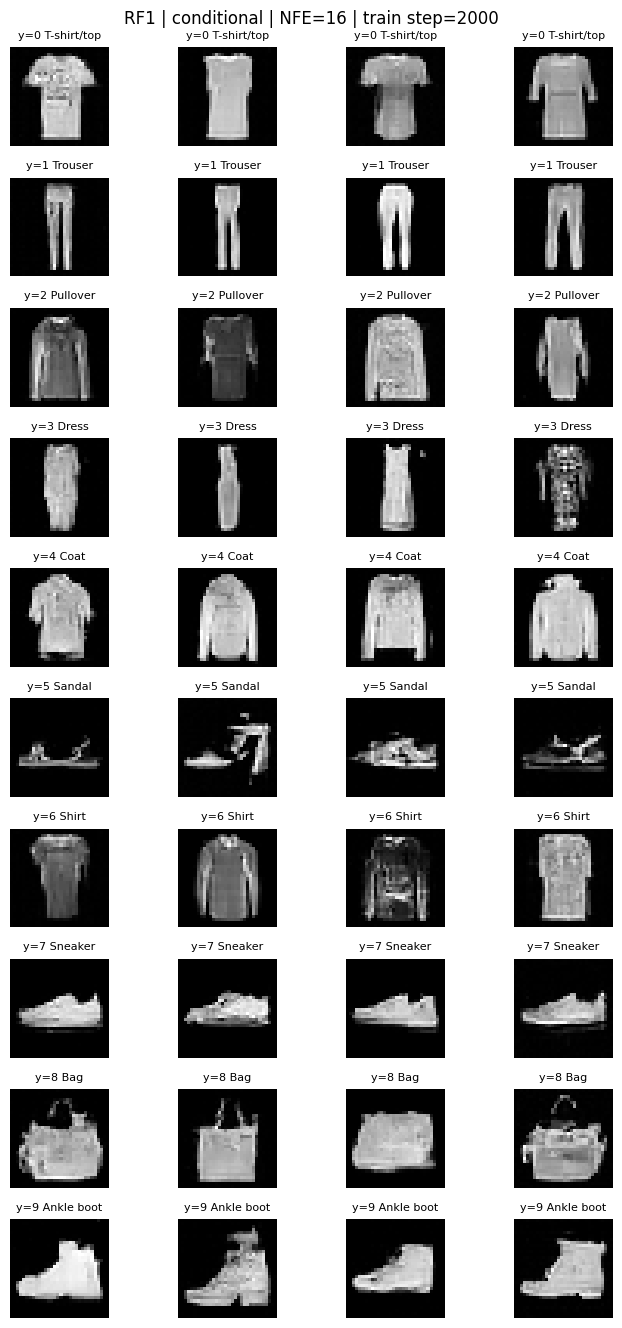

RF1 {'step': 2050, 'loss': 0.17380401492118835, 'grad_norm': 0.38688498735427856, 'raw_mse': 0.17380401492118835}
RF1 {'step': 2100, 'loss': 0.17207051813602448, 'grad_norm': 0.39828088879585266, 'raw_mse': 0.17207051813602448}
RF1 {'step': 2150, 'loss': 0.18411117792129517, 'grad_norm': 0.414076566696167, 'raw_mse': 0.18411117792129517}
RF1 {'step': 2200, 'loss': 0.15692918002605438, 'grad_norm': 0.4407632350921631, 'raw_mse': 0.15692918002605438}
RF1 {'step': 2250, 'loss': 0.17747318744659424, 'grad_norm': 0.3908502757549286, 'raw_mse': 0.17747318744659424}
RF1 {'step': 2300, 'loss': 0.17299659550189972, 'grad_norm': 0.47816193103790283, 'raw_mse': 0.17299659550189972}
RF1 {'step': 2350, 'loss': 0.17212805151939392, 'grad_norm': 0.613125741481781, 'raw_mse': 0.17212805151939392}
RF1 {'step': 2400, 'loss': 0.16628696024417877, 'grad_norm': 0.3382313549518585, 'raw_mse': 0.16628696024417877}
RF1 {'step': 2450, 'loss': 0.17098648846149445, 'grad_norm': 0.5709394216537476, 'raw_mse': 0.1

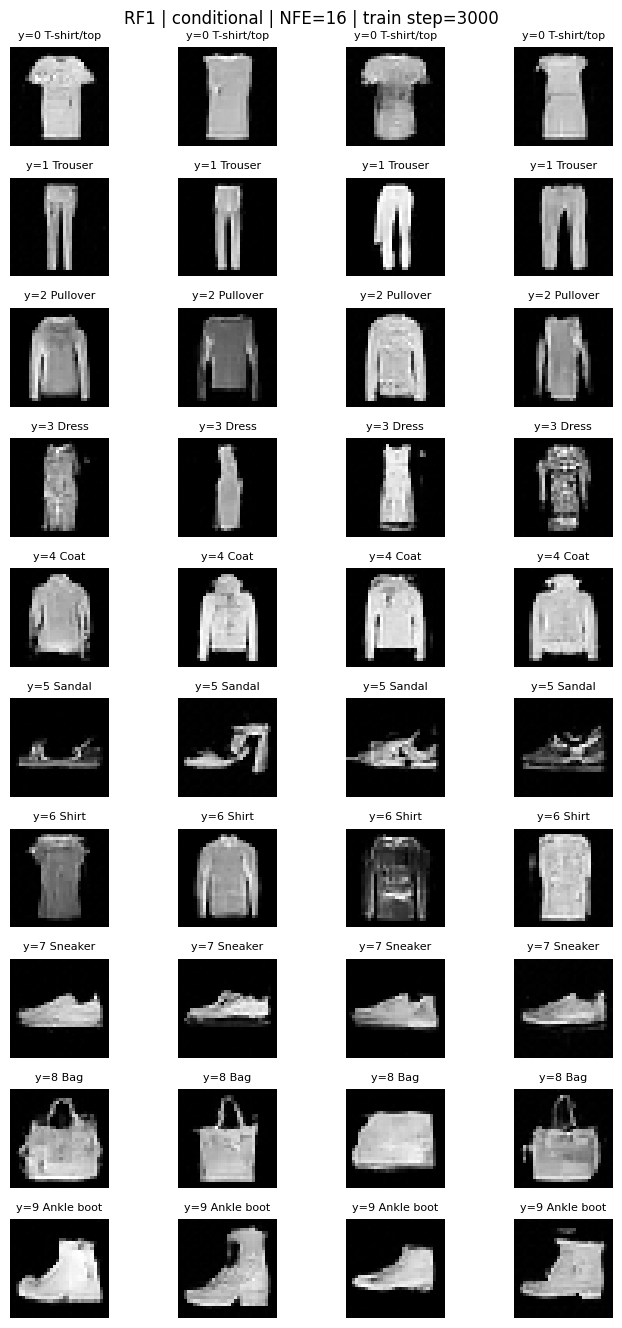

RF1 {'step': 3050, 'loss': 0.17501237988471985, 'grad_norm': 0.378738135099411, 'raw_mse': 0.17501237988471985}
RF1 {'step': 3100, 'loss': 0.1484111100435257, 'grad_norm': 0.4795255661010742, 'raw_mse': 0.1484111100435257}
RF1 {'step': 3150, 'loss': 0.1695461869239807, 'grad_norm': 0.3552950620651245, 'raw_mse': 0.1695461869239807}
RF1 {'step': 3200, 'loss': 0.18523627519607544, 'grad_norm': 0.4452346861362457, 'raw_mse': 0.18523627519607544}
RF1 {'step': 3250, 'loss': 0.16687366366386414, 'grad_norm': 0.5011655688285828, 'raw_mse': 0.16687366366386414}
RF1 {'step': 3300, 'loss': 0.16001898050308228, 'grad_norm': 0.5148687958717346, 'raw_mse': 0.16001898050308228}
RF1 {'step': 3350, 'loss': 0.17219090461730957, 'grad_norm': 0.439677894115448, 'raw_mse': 0.17219090461730957}
RF1 {'step': 3400, 'loss': 0.17292791604995728, 'grad_norm': 0.35451409220695496, 'raw_mse': 0.17292791604995728}
RF1 {'step': 3450, 'loss': 0.17663432657718658, 'grad_norm': 0.5413370132446289, 'raw_mse': 0.1766343

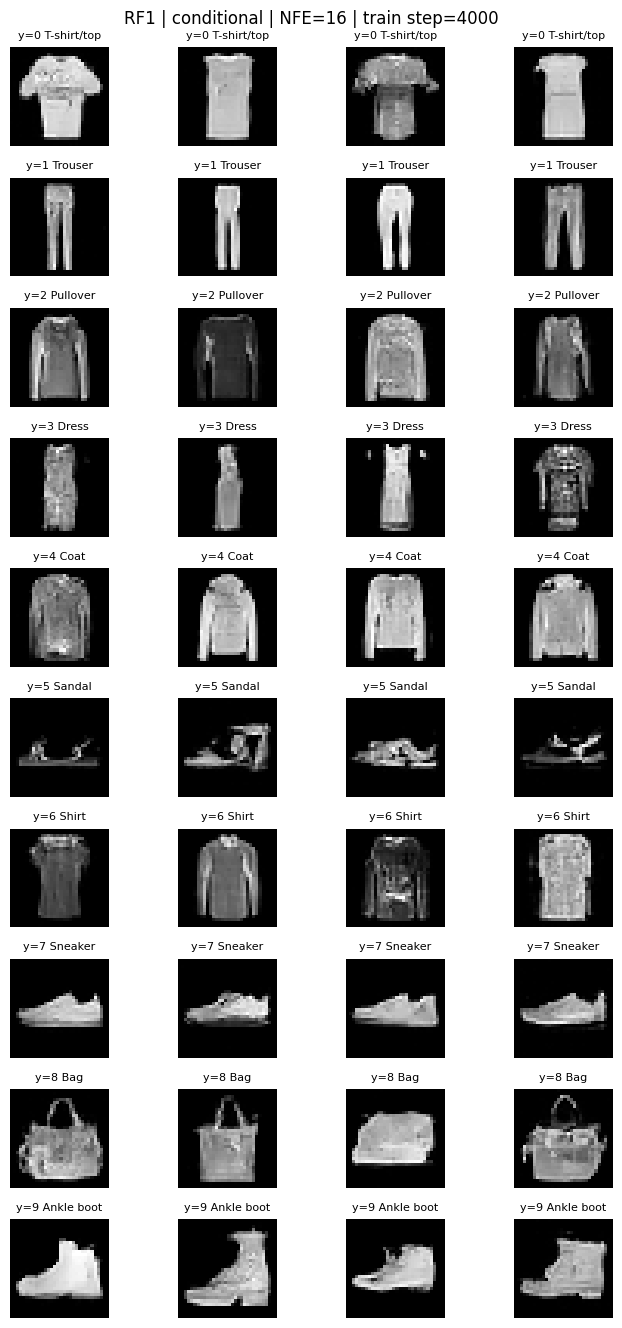

RF1 {'step': 4050, 'loss': 0.18410800397396088, 'grad_norm': 0.5733029842376709, 'raw_mse': 0.18410800397396088}
RF1 {'step': 4100, 'loss': 0.17356346547603607, 'grad_norm': 0.7614195346832275, 'raw_mse': 0.17356346547603607}
RF1 {'step': 4150, 'loss': 0.1718476414680481, 'grad_norm': 0.477183073759079, 'raw_mse': 0.1718476414680481}
RF1 {'step': 4200, 'loss': 0.1796765774488449, 'grad_norm': 0.4582134187221527, 'raw_mse': 0.1796765774488449}
RF1 {'step': 4250, 'loss': 0.17014506459236145, 'grad_norm': 0.4945243000984192, 'raw_mse': 0.17014506459236145}
RF1 {'step': 4300, 'loss': 0.1633041799068451, 'grad_norm': 0.5125266313552856, 'raw_mse': 0.1633041799068451}
RF1 {'step': 4350, 'loss': 0.15729054808616638, 'grad_norm': 0.3902371823787689, 'raw_mse': 0.15729054808616638}
RF1 {'step': 4400, 'loss': 0.1688401997089386, 'grad_norm': 0.43884798884391785, 'raw_mse': 0.1688401997089386}
RF1 {'step': 4450, 'loss': 0.17742374539375305, 'grad_norm': 0.31452929973602295, 'raw_mse': 0.177423745

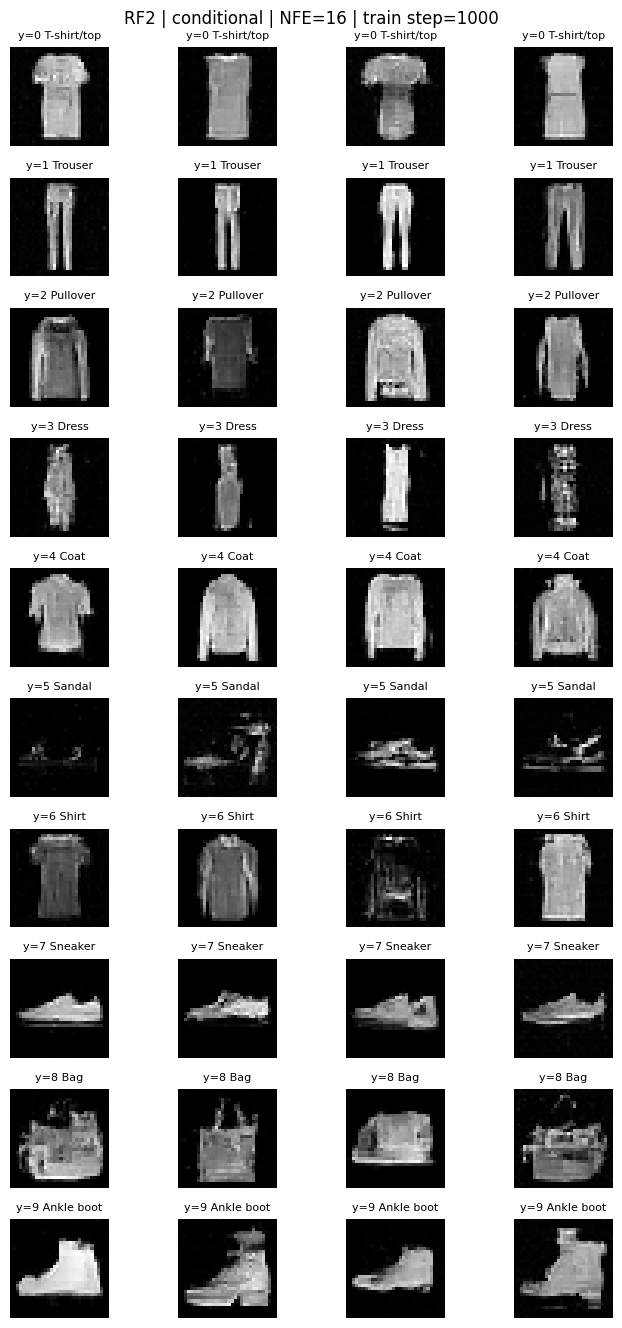

RF2 {'step': 1050, 'loss': 0.016210438683629036, 'grad_norm': 0.5482449531555176, 'raw_mse': 0.016210438683629036}
RF2 {'step': 1100, 'loss': 0.015060058794915676, 'grad_norm': 0.5946949124336243, 'raw_mse': 0.015060058794915676}
RF2 {'step': 1150, 'loss': 0.015383218415081501, 'grad_norm': 0.47720959782600403, 'raw_mse': 0.015383218415081501}
RF2 {'step': 1200, 'loss': 0.01566237024962902, 'grad_norm': 0.49641698598861694, 'raw_mse': 0.01566237024962902}
RF2 {'step': 1250, 'loss': 0.014584795571863651, 'grad_norm': 0.4216189384460449, 'raw_mse': 0.014584795571863651}
RF2 {'step': 1300, 'loss': 0.019723955541849136, 'grad_norm': 0.8172579407691956, 'raw_mse': 0.019723955541849136}
RF2 {'step': 1350, 'loss': 0.014643821865320206, 'grad_norm': 0.3078543245792389, 'raw_mse': 0.014643821865320206}
RF2 {'step': 1400, 'loss': 0.014664309099316597, 'grad_norm': 0.5941881537437439, 'raw_mse': 0.014664309099316597}
RF2 {'step': 1450, 'loss': 0.012399670667946339, 'grad_norm': 0.3875781297683716

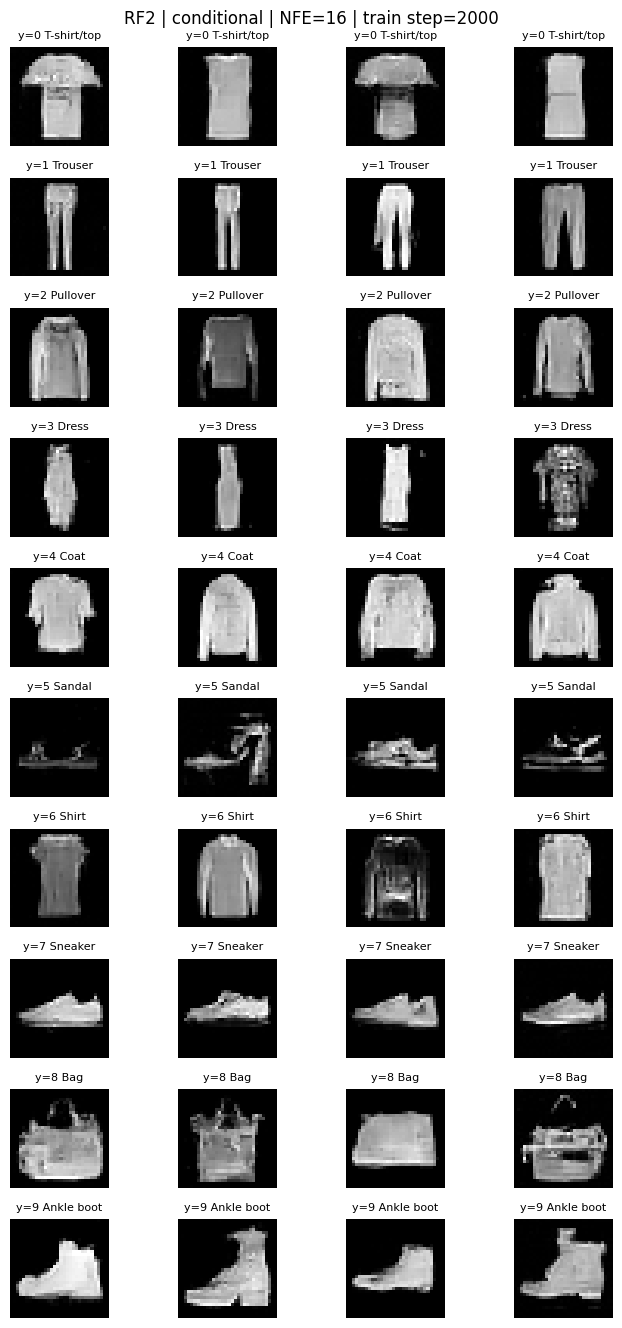

RF2 {'step': 2050, 'loss': 0.010365337133407593, 'grad_norm': 0.34251829981803894, 'raw_mse': 0.010365337133407593}
RF2 {'step': 2100, 'loss': 0.01196279190480709, 'grad_norm': 0.403851717710495, 'raw_mse': 0.01196279190480709}
RF2 {'step': 2150, 'loss': 0.009959347546100616, 'grad_norm': 0.4081904888153076, 'raw_mse': 0.009959347546100616}
RF2 {'step': 2200, 'loss': 0.011731515638530254, 'grad_norm': 0.4143781065940857, 'raw_mse': 0.011731515638530254}
RF2 {'step': 2250, 'loss': 0.011611799709498882, 'grad_norm': 0.5138517022132874, 'raw_mse': 0.011611799709498882}
RF2 {'step': 2300, 'loss': 0.010878343135118484, 'grad_norm': 0.3426591157913208, 'raw_mse': 0.010878343135118484}
RF2 {'step': 2350, 'loss': 0.012378731742501259, 'grad_norm': 0.5884730815887451, 'raw_mse': 0.012378731742501259}
RF2 {'step': 2400, 'loss': 0.01207081787288189, 'grad_norm': 0.5431954860687256, 'raw_mse': 0.01207081787288189}
RF2 {'step': 2450, 'loss': 0.011393618769943714, 'grad_norm': 0.3841165006160736, 'r

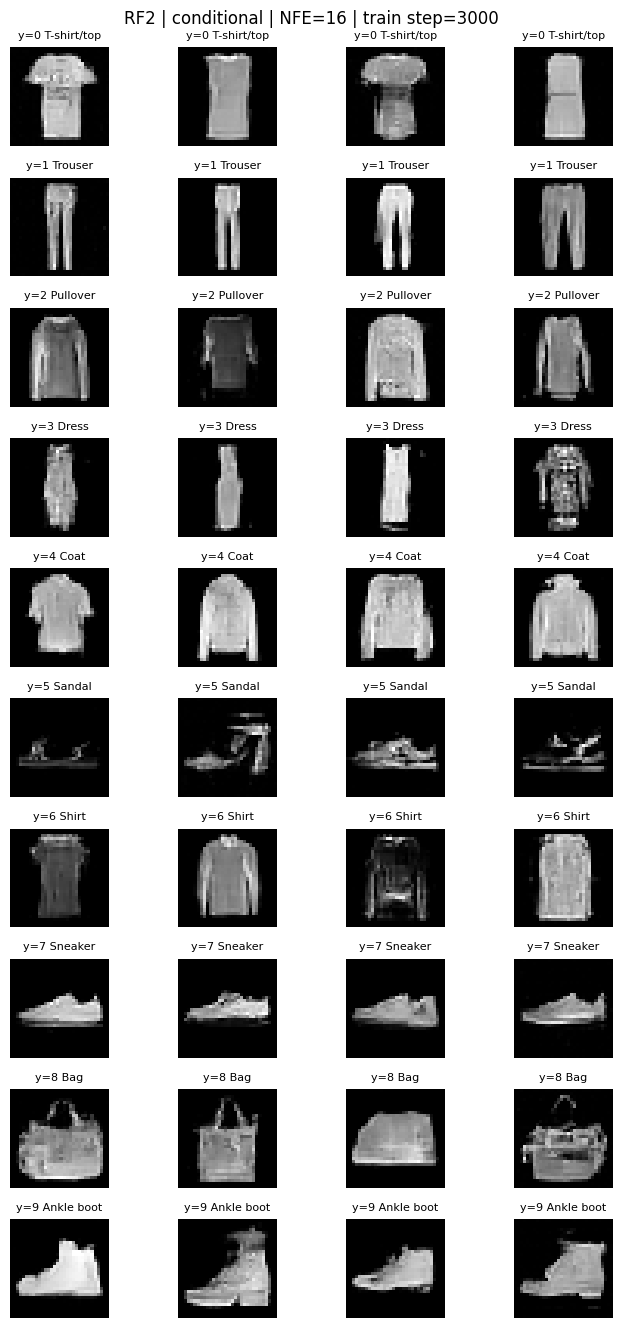

RF2 {'step': 3050, 'loss': 0.009079577401280403, 'grad_norm': 0.3376719057559967, 'raw_mse': 0.009079577401280403}
RF2 {'step': 3100, 'loss': 0.007561900187283754, 'grad_norm': 0.2938077747821808, 'raw_mse': 0.007561900187283754}
RF2 {'step': 3150, 'loss': 0.009477678686380386, 'grad_norm': 0.3595528304576874, 'raw_mse': 0.009477678686380386}
RF2 {'step': 3200, 'loss': 0.01020473800599575, 'grad_norm': 0.43863075971603394, 'raw_mse': 0.01020473800599575}
RF2 {'step': 3250, 'loss': 0.008412659168243408, 'grad_norm': 0.34339746832847595, 'raw_mse': 0.008412659168243408}
RF2 {'step': 3300, 'loss': 0.00957157276570797, 'grad_norm': 0.49055230617523193, 'raw_mse': 0.00957157276570797}
RF2 {'step': 3350, 'loss': 0.007471034768968821, 'grad_norm': 0.2917623519897461, 'raw_mse': 0.007471034768968821}
RF2 {'step': 3400, 'loss': 0.007331532891839743, 'grad_norm': 0.2918650507926941, 'raw_mse': 0.007331532891839743}
RF2 {'step': 3450, 'loss': 0.008367097936570644, 'grad_norm': 0.372468501329422, 

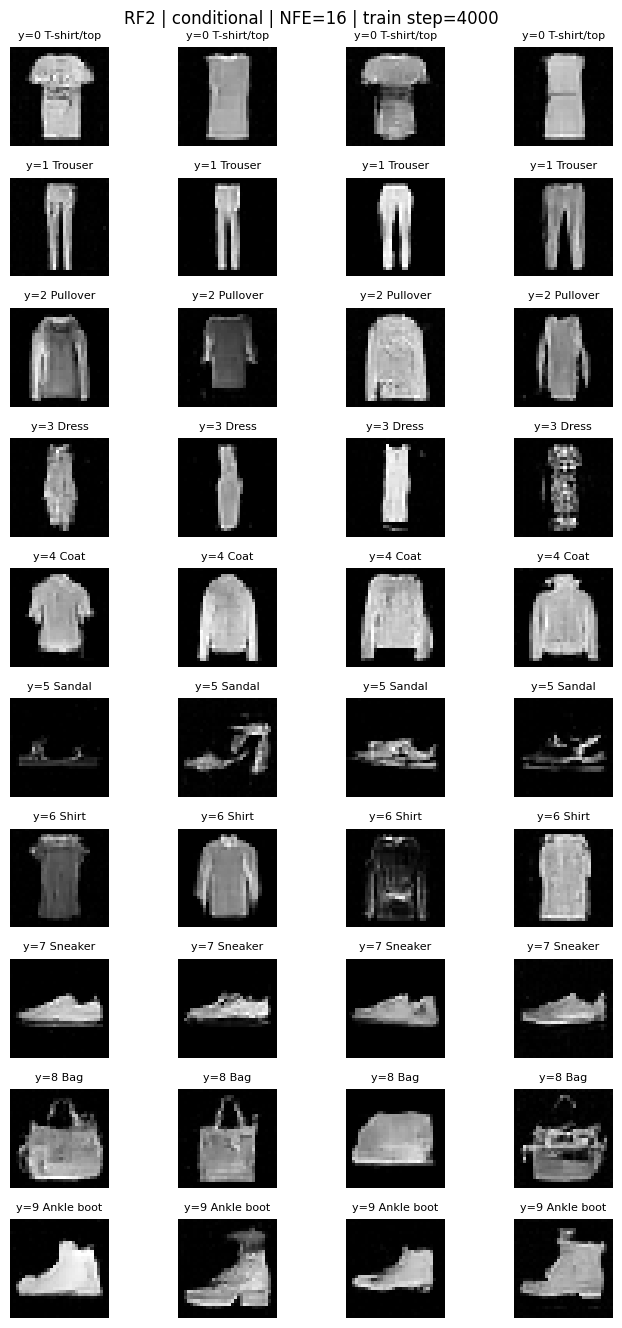

RF2 {'step': 4050, 'loss': 0.007504344917833805, 'grad_norm': 0.2680467963218689, 'raw_mse': 0.007504344917833805}
RF2 {'step': 4100, 'loss': 0.006929746828973293, 'grad_norm': 0.2999347150325775, 'raw_mse': 0.006929746828973293}
RF2 {'step': 4150, 'loss': 0.0067788404412567616, 'grad_norm': 0.23897750675678253, 'raw_mse': 0.0067788404412567616}
RF2 {'step': 4200, 'loss': 0.007371706888079643, 'grad_norm': 0.3750218451023102, 'raw_mse': 0.007371706888079643}
RF2 {'step': 4250, 'loss': 0.008689059875905514, 'grad_norm': 0.4627896547317505, 'raw_mse': 0.008689059875905514}
RF2 {'step': 4300, 'loss': 0.011827070266008377, 'grad_norm': 0.4540584683418274, 'raw_mse': 0.011827070266008377}
RF2 {'step': 4350, 'loss': 0.009851967915892601, 'grad_norm': 0.35138025879859924, 'raw_mse': 0.009851967915892601}
RF2 {'step': 4400, 'loss': 0.00748561741784215, 'grad_norm': 0.2779310643672943, 'raw_mse': 0.00748561741784215}
RF2 {'step': 4450, 'loss': 0.008435768075287342, 'grad_norm': 0.36715322732925

,step,loss,grad_norm,raw_mse
96,4800,0.184982,0.411305,0.184982
97,4850,0.176268,0.415904,0.176268
98,4900,0.157546,0.413652,0.157546
99,4950,0.152773,0.323403,0.152773
100,5000,0.170277,0.441214,0.170277


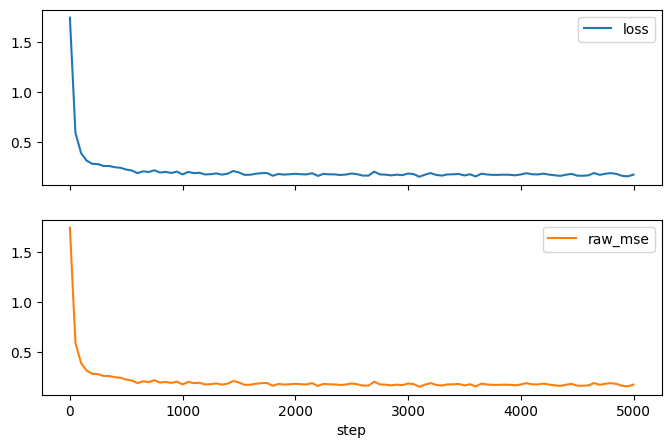

,step,loss,grad_norm,raw_mse
96,4800,0.006976,0.282425,0.006976
97,4850,0.007787,0.306187,0.007787
98,4900,0.008769,0.540147,0.008769
99,4950,0.007389,0.365912,0.007389
100,5000,0.010084,0.385305,0.010084


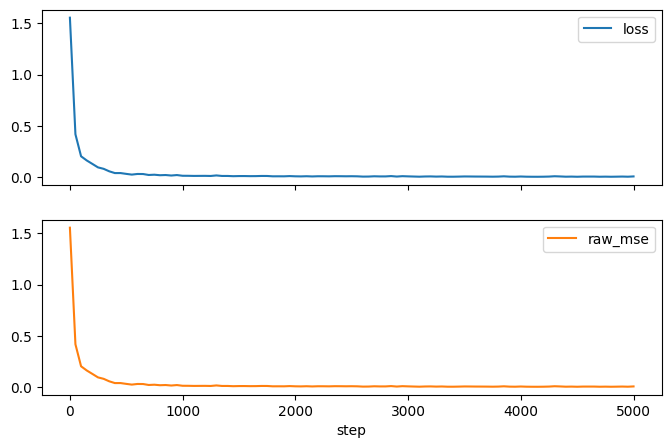

In [14]:
# @title RF — independent 1-RF, then conditional reflow
rf1 = train_method("RF1", fresh_model(), fm_loss, sample_fm)


def reflow_loss(model, images, labels, step):
    noise = torch.randn_like(images)

    with torch.no_grad():
        endpoint = sample_fm(rf1, noise, labels, RF_TEACHER_NFE)

    t = torch.rand(len(images), device=DEVICE)
    z = (1 - expand_time(t)) * endpoint + expand_time(t) * noise
    prediction = model(z, t, torch.zeros_like(t), labels)
    loss = F.mse_loss(prediction, noise - endpoint)

    return loss, {"raw_mse": loss.detach()}


rf2 = train_method("RF2", fresh_model(), reflow_loss, sample_fm)
show_training("RF1")
show_training("RF2")

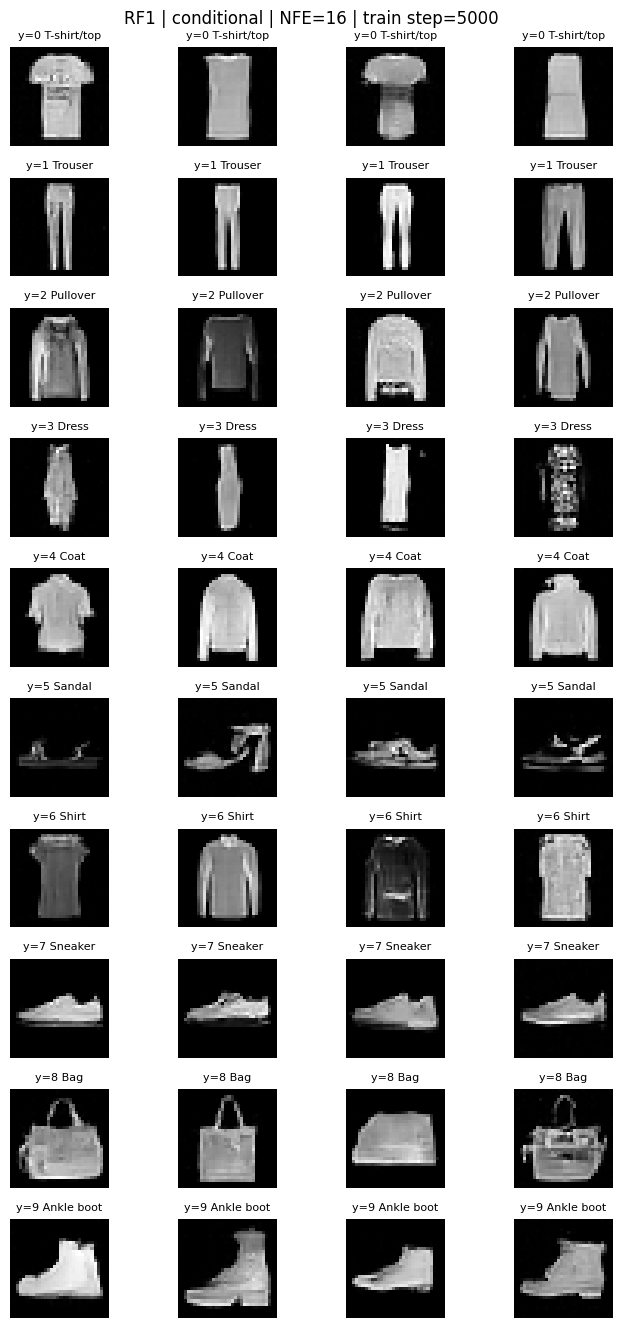

/tmp/ipykernel_528/304162648.py:94: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root = sqrtm(real_cov @ fake_cov)


RF1 {'feature_fid': 16.553736215270227, 'kid': 12.83219556107997, 'condition_accuracy': 0.8650000095367432, 'class_entropy': 2.28497314453125, 'train_steps': 5000, 'train_s': 526.696746556, 'stop_reason': 'early_stop_at', 'optimizer_backend': 'torch.optim.Muon', 'nfe': 16, 'eval_s': 3.4009552839997923}


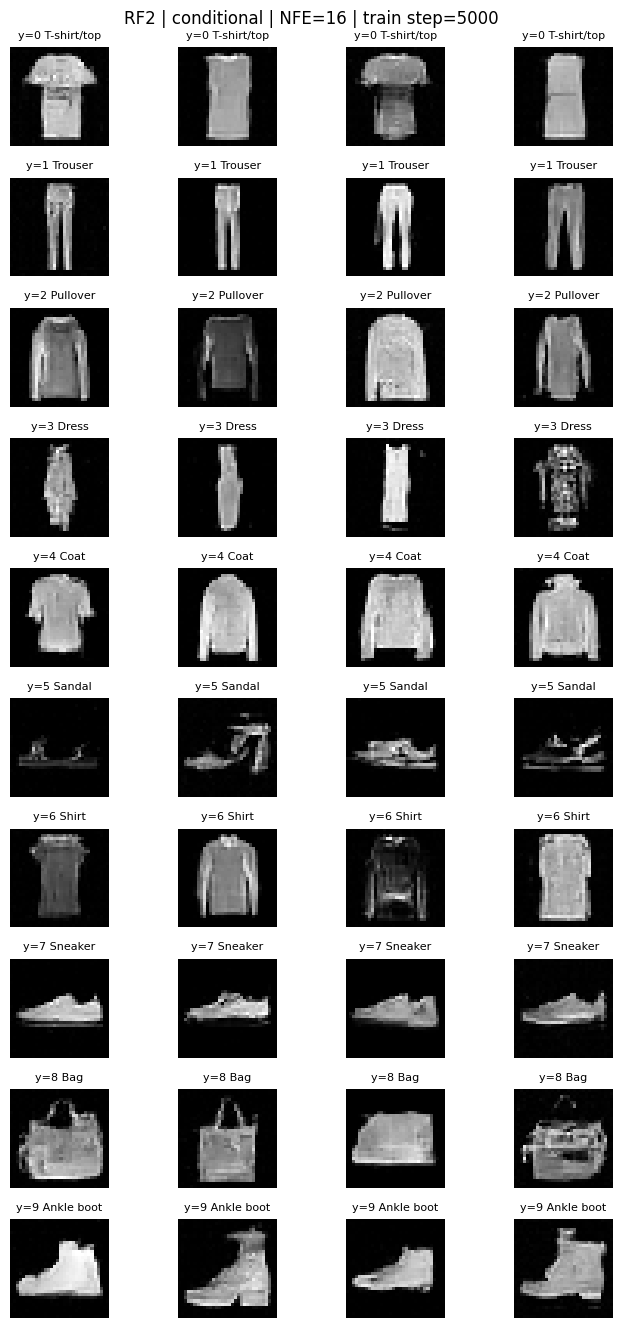

RF2 {'feature_fid': 22.723110158676644, 'kid': 18.878138967804205, 'condition_accuracy': 0.8429999947547913, 'class_entropy': 2.284320592880249, 'train_steps': 5000, 'train_s': 4387.703553730999, 'stop_reason': 'early_stop_at', 'optimizer_backend': 'torch.optim.Muon', 'nfe': 16, 'eval_s': 3.571045052000045}


In [15]:
# @title RF — conditional generation before/after reflow
for name in ("RF1", "RF2"):
    show_conditional(
        MODELS[name], sample_fm, name, DEFAULT_NFE[name], RUN_INFO[name]["train_steps"]
    )
    evaluate_method(name, sample_fm)

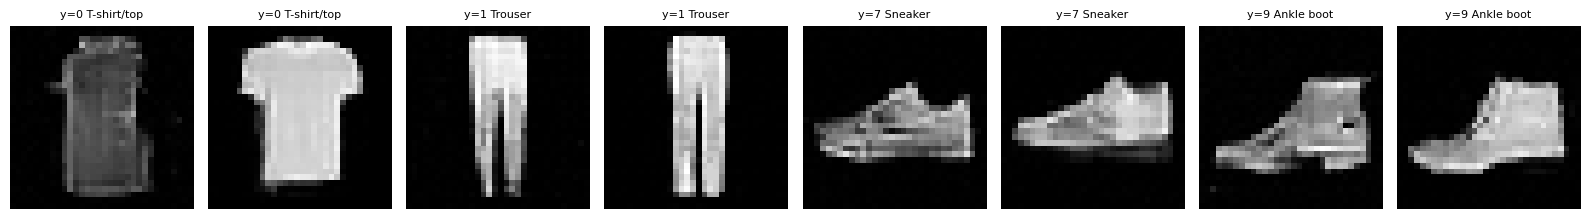

In [16]:
# @title RF2 — 원하는 클래스 직접 생성 (라벨·seed·NFE 수정)
# 0 T-shirt, 1 Trouser, 2 Pullover, 3 Dress, 4 Coat,
# 5 Sandal, 6 Shirt, 7 Sneaker, 8 Bag, 9 Ankle boot
requested_labels = [0, 0, 1, 1, 7, 7, 9, 9]
requested_nfe = DEFAULT_NFE["RF2"]
requested_seed = SEED + 20_000
custom_images = generate_conditioned(
    MODELS["RF2"], sample_fm, requested_labels, requested_nfe, seed=requested_seed
)
fig, axes = plt.subplots(
    1, len(requested_labels), figsize=(2 * len(requested_labels), 2.5), squeeze=False
)

for ax, image, label in zip(axes.flat, custom_images, requested_labels):
    ax.imshow(((image[0] + 1) / 2).clamp(0, 1), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"y={label} {CLASS_NAMES[label]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Consistency Models — endpoint consistency

standalone Consistency Training을 실습한다. 인접 noise level의 두 입력에서 online prediction과 stop-gradient EMA target을 일치시킨다.
원 논문의 additive corruption \(z_\sigma=x+\sigma\epsilon\)과 \(\sigma_\min\)에서 identity인 skip/output preconditioning을 사용한다.
같은 \(x,\epsilon\)에서 만든 인접 입력은 CT의 stochastic 근사 구성이다. 유한 간격에서 동일 marginal PF-ODE trajectory 위의 정확한 두 점이라는 뜻은 아니다.

이 절의 noise scale은 다른 Flow의 선형 \(t\)와 다르다. DiT에는 정규화한 log-noise level과 `interval=0`을 전달한다.
**적응:** MSE, 고정 target EMA decay, 소형 DiT/Muon. 격자는 학습 상한을 기준으로 증가한다. 원 benchmark 전체 recipe 재현은 아니다.


In [17]:
# @title CM — noise curriculum / standalone CT / boundary-preserving sampler
CM_SIGMA_MIN = 0.002
CM_SIGMA_MAX = 80.0
CM_SIGMA_DATA = 0.5
CM_RHO = 7.0


def cm_grid_size(step):
    stages = math.ceil(math.log2(CM_GRID_END / CM_GRID_START))
    stage = int(stages * (step - 1) / max(1, TRAIN_STEPS - 1))

    return min(CM_GRID_END, CM_GRID_START * 2**stage)


def cm_noise_levels(fraction):
    lo, hi = CM_SIGMA_MIN ** (1 / CM_RHO), CM_SIGMA_MAX ** (1 / CM_RHO)

    return (lo + fraction * (hi - lo)) ** CM_RHO


def cm_f(model, z, sigma, labels):
    sigma_image = expand_time(sigma)
    offset = sigma_image - CM_SIGMA_MIN
    cskip = CM_SIGMA_DATA**2 / (offset.square() + CM_SIGMA_DATA**2)
    cout = CM_SIGMA_DATA * offset / (sigma_image.square() + CM_SIGMA_DATA**2).sqrt()
    cin = (sigma_image.square() + CM_SIGMA_DATA**2).rsqrt()
    t = torch.log(sigma / CM_SIGMA_MIN) / math.log(CM_SIGMA_MAX / CM_SIGMA_MIN)

    return cskip * z + cout * model(cin * z, t, torch.zeros_like(t), labels)


@torch.no_grad()
def sample_cm(model, noise, labels, steps):
    if steps < 1:
        raise ValueError("steps must be positive")

    z = CM_SIGMA_MAX * noise
    levels = cm_noise_levels(torch.linspace(1, 0, steps + 1, device=noise.device))

    for k in range(steps):
        sigma = levels[k].expand(len(noise))
        endpoint = cm_f(model, z, sigma, labels)

        if k + 1 < steps:
            scale = (levels[k + 1].square() - CM_SIGMA_MIN**2).clamp_min(0).sqrt()
            z = endpoint + scale * torch.randn_like(noise)
        else:
            z = endpoint

    return z


cm = fresh_model()
cm_target = freeze_copy(cm)


def cm_loss(model, images, labels, step):
    grid_size = cm_grid_size(step)
    indices = torch.randint(1, grid_size + 1, (len(images),), device=DEVICE)
    sigma = cm_noise_levels(indices.float() / grid_size)
    lower = cm_noise_levels((indices.float() - 1) / grid_size)
    noise = torch.randn_like(images)
    prediction = cm_f(model, images + expand_time(sigma) * noise, sigma, labels)

    with torch.no_grad():
        target = cm_f(cm_target, images + expand_time(lower) * noise, lower, labels)

    loss = F.mse_loss(prediction, target)

    return loss, {"raw_mse": loss.detach(), "grid_intervals": grid_size}

CM torch.optim.Muon max= 20000 stop_at= 5000
CM {'step': 1, 'loss': 0.0030191726982593536, 'grad_norm': 0.04352738335728645, 'raw_mse': 0.0030191726982593536, 'grid_intervals': 32.0}
CM {'step': 50, 'loss': 0.0007014335133135319, 'grad_norm': 0.009671380743384361, 'raw_mse': 0.0007014335133135319, 'grid_intervals': 32.0}
CM {'step': 100, 'loss': 0.0004750408697873354, 'grad_norm': 0.0042508007027208805, 'raw_mse': 0.0004750408697873354, 'grid_intervals': 32.0}
CM {'step': 150, 'loss': 0.0003149373224005103, 'grad_norm': 0.004341080319136381, 'raw_mse': 0.0003149373224005103, 'grid_intervals': 32.0}
CM {'step': 200, 'loss': 0.00023665037588216364, 'grad_norm': 0.004328269511461258, 'raw_mse': 0.00023665037588216364, 'grid_intervals': 32.0}
CM {'step': 250, 'loss': 0.00021424240549094975, 'grad_norm': 0.002372965682297945, 'raw_mse': 0.00021424240549094975, 'grid_intervals': 32.0}
CM {'step': 300, 'loss': 0.0002483375428710133, 'grad_norm': 0.0042802924290299416, 'raw_mse': 0.00024833754

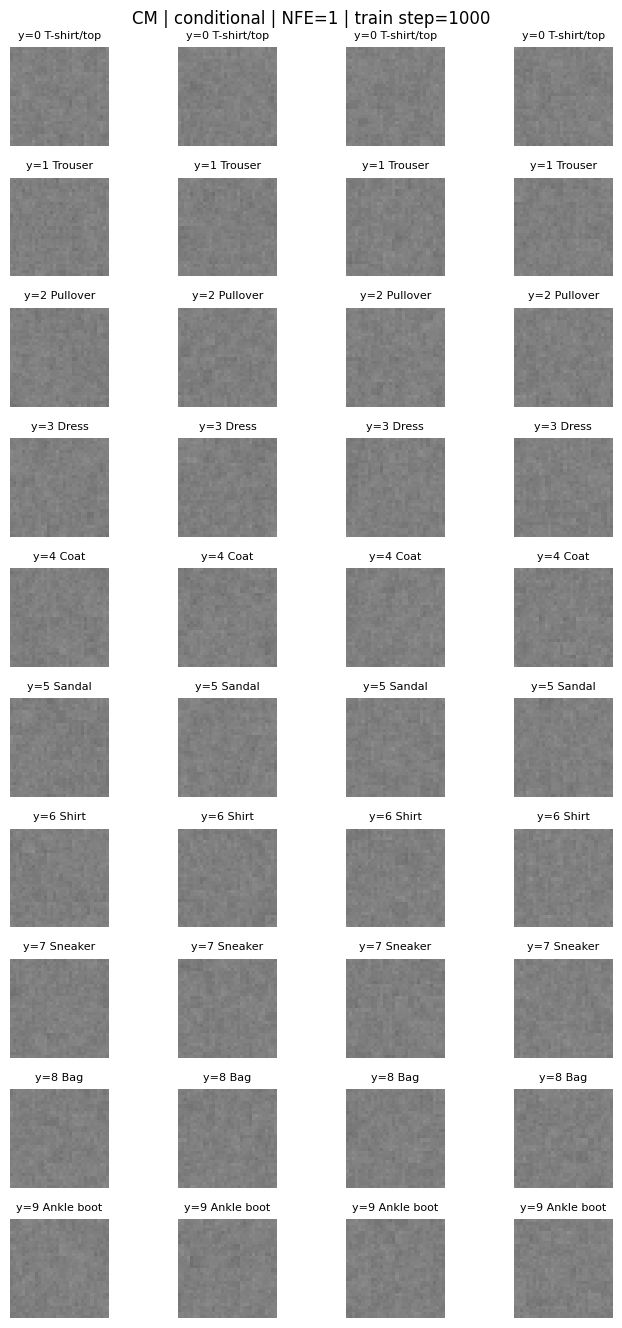

CM {'step': 1050, 'loss': 0.00022316479589790106, 'grad_norm': 0.00199141725897789, 'raw_mse': 0.00022316479589790106, 'grid_intervals': 32.0}
CM {'step': 1100, 'loss': 0.00018527457723394036, 'grad_norm': 0.0019819890148937702, 'raw_mse': 0.00018527457723394036, 'grid_intervals': 32.0}
CM {'step': 1150, 'loss': 0.0002445232239551842, 'grad_norm': 0.0035083575639873743, 'raw_mse': 0.0002445232239551842, 'grid_intervals': 32.0}
CM {'step': 1200, 'loss': 0.0001725895854178816, 'grad_norm': 0.001268085208721459, 'raw_mse': 0.0001725895854178816, 'grid_intervals': 32.0}
CM {'step': 1250, 'loss': 0.0002267396921524778, 'grad_norm': 0.0029481626115739346, 'raw_mse': 0.0002267396921524778, 'grid_intervals': 32.0}
CM {'step': 1300, 'loss': 0.00015607885143253952, 'grad_norm': 0.003294268622994423, 'raw_mse': 0.00015607885143253952, 'grid_intervals': 32.0}
CM {'step': 1350, 'loss': 0.0001779373560566455, 'grad_norm': 0.0023727593943476677, 'raw_mse': 0.0001779373560566455, 'grid_intervals': 32.

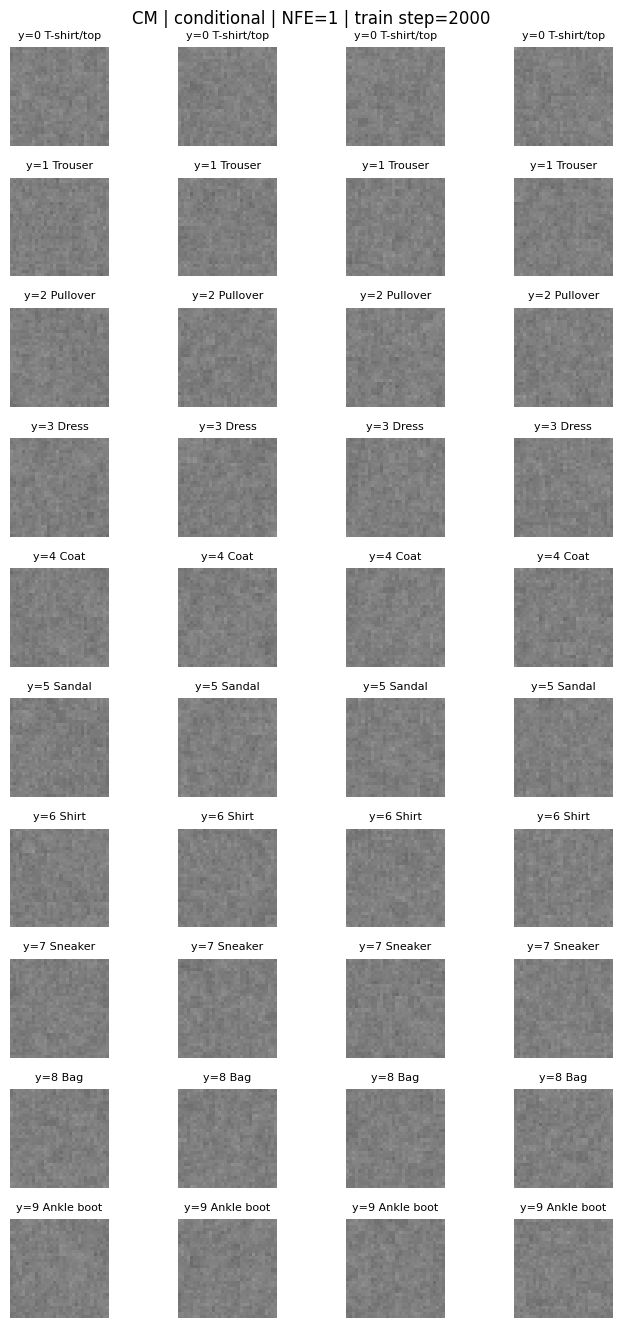

CM {'step': 2050, 'loss': 0.00021834320796187967, 'grad_norm': 0.0033404859714210033, 'raw_mse': 0.00021834320796187967, 'grid_intervals': 32.0}
CM {'step': 2100, 'loss': 0.00022815074771642685, 'grad_norm': 0.003430040320381522, 'raw_mse': 0.00022815074771642685, 'grid_intervals': 32.0}
CM {'step': 2150, 'loss': 0.0002622063911985606, 'grad_norm': 0.0036742277443408966, 'raw_mse': 0.0002622063911985606, 'grid_intervals': 32.0}
CM {'step': 2200, 'loss': 0.000262617104453966, 'grad_norm': 0.0019934605807065964, 'raw_mse': 0.000262617104453966, 'grid_intervals': 32.0}
CM {'step': 2250, 'loss': 0.00026629690546542406, 'grad_norm': 0.006182824727147818, 'raw_mse': 0.00026629690546542406, 'grid_intervals': 32.0}
CM {'step': 2300, 'loss': 0.00023667074856348336, 'grad_norm': 0.00439181923866272, 'raw_mse': 0.00023667074856348336, 'grid_intervals': 32.0}
CM {'step': 2350, 'loss': 0.0001997237268369645, 'grad_norm': 0.0028520815540105104, 'raw_mse': 0.0001997237268369645, 'grid_intervals': 32.

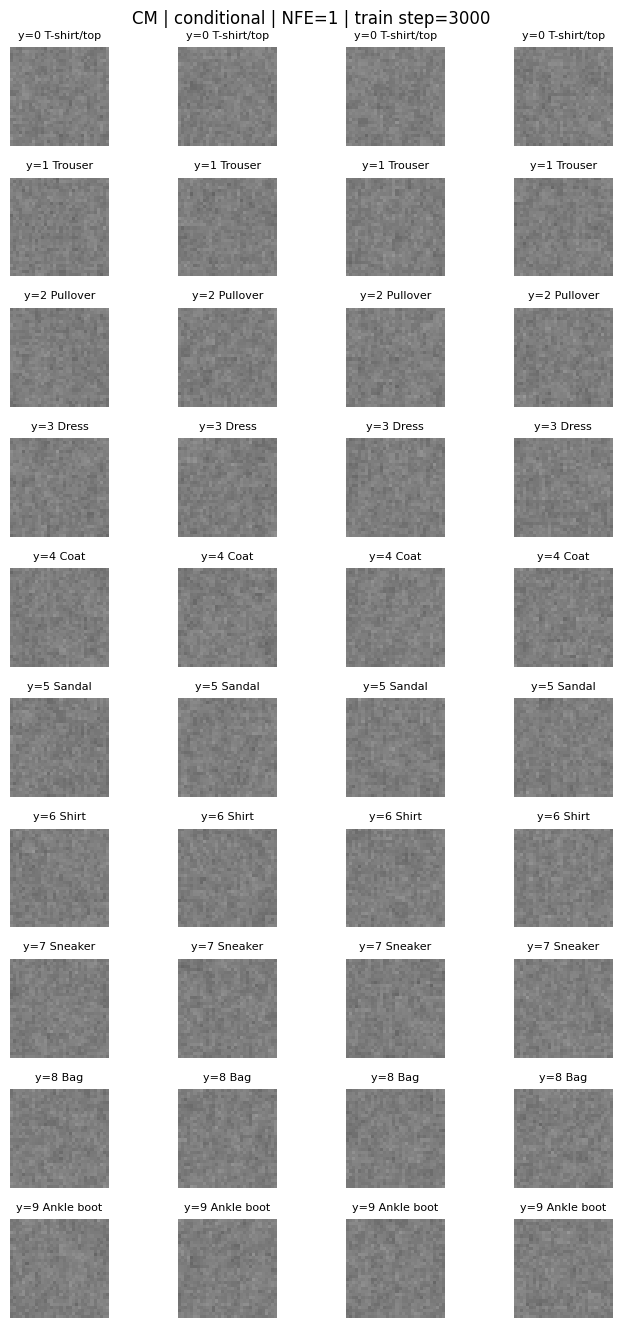

CM {'step': 3050, 'loss': 0.0002877789083868265, 'grad_norm': 0.002742643700912595, 'raw_mse': 0.0002877789083868265, 'grid_intervals': 32.0}
CM {'step': 3100, 'loss': 0.000271261902526021, 'grad_norm': 0.003356809727847576, 'raw_mse': 0.000271261902526021, 'grid_intervals': 32.0}
CM {'step': 3150, 'loss': 0.0002889279858209193, 'grad_norm': 0.003517910372465849, 'raw_mse': 0.0002889279858209193, 'grid_intervals': 32.0}
CM {'step': 3200, 'loss': 0.00030584665364585817, 'grad_norm': 0.0022065325174480677, 'raw_mse': 0.00030584665364585817, 'grid_intervals': 32.0}
CM {'step': 3250, 'loss': 0.00039891843334771693, 'grad_norm': 0.003449623938649893, 'raw_mse': 0.00039891843334771693, 'grid_intervals': 32.0}
CM {'step': 3300, 'loss': 0.00024786294670775533, 'grad_norm': 0.0033786657731980085, 'raw_mse': 0.00024786294670775533, 'grid_intervals': 32.0}
CM {'step': 3350, 'loss': 0.00012567368685267866, 'grad_norm': 0.0026726361829787493, 'raw_mse': 0.00012567368685267866, 'grid_intervals': 64.

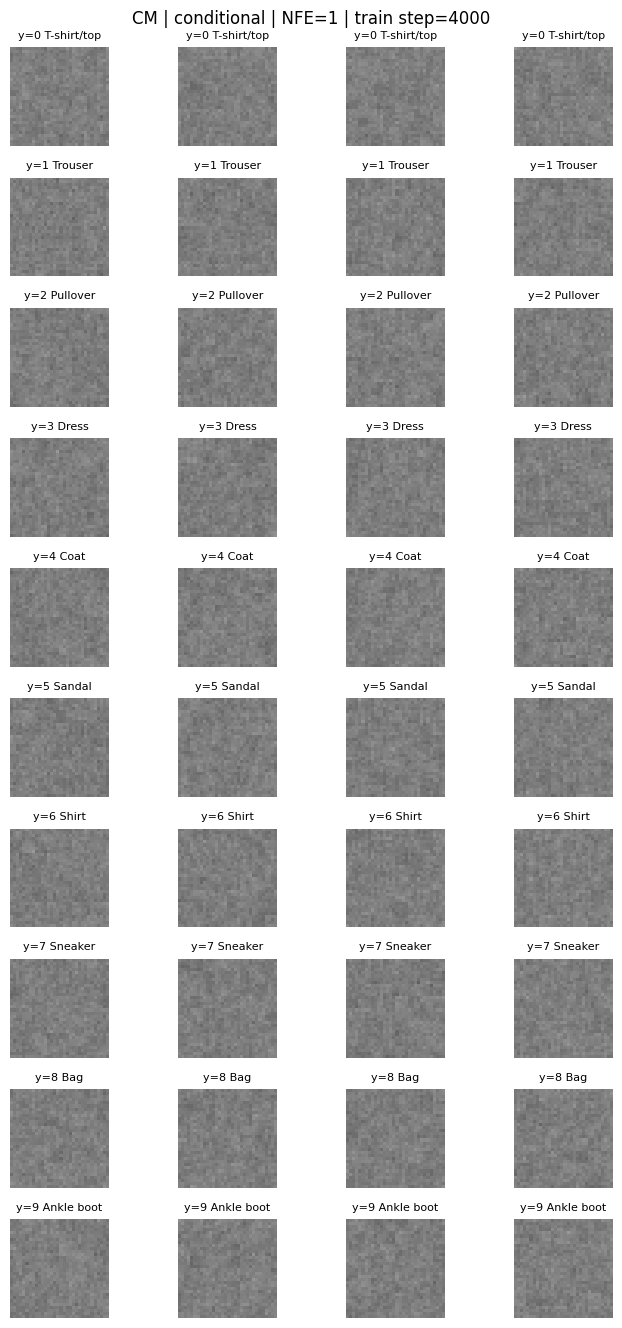

CM {'step': 4050, 'loss': 9.615792077966034e-05, 'grad_norm': 0.0034780835267156363, 'raw_mse': 9.615792077966034e-05, 'grid_intervals': 64.0}
CM {'step': 4100, 'loss': 0.00010570340236881748, 'grad_norm': 0.0022984487004578114, 'raw_mse': 0.00010570340236881748, 'grid_intervals': 64.0}
CM {'step': 4150, 'loss': 0.00012462421727832407, 'grad_norm': 0.0023132457863539457, 'raw_mse': 0.00012462421727832407, 'grid_intervals': 64.0}
CM {'step': 4200, 'loss': 0.00010940630454570055, 'grad_norm': 0.0033965520560741425, 'raw_mse': 0.00010940630454570055, 'grid_intervals': 64.0}
CM {'step': 4250, 'loss': 8.109420741675422e-05, 'grad_norm': 0.0022497870959341526, 'raw_mse': 8.109420741675422e-05, 'grid_intervals': 64.0}
CM {'step': 4300, 'loss': 7.715296669630334e-05, 'grad_norm': 0.002811129204928875, 'raw_mse': 7.715296669630334e-05, 'grid_intervals': 64.0}
CM {'step': 4350, 'loss': 0.00015121893375180662, 'grad_norm': 0.003986323717981577, 'raw_mse': 0.00015121893375180662, 'grid_intervals':

,step,loss,grad_norm,raw_mse,grid_intervals
96,4800,0.000124,0.002723,0.000124,64.0
97,4850,0.000114,0.003110,0.000114,64.0
98,4900,0.000166,0.004872,0.000166,64.0
99,4950,0.000113,0.004400,0.000113,64.0
100,5000,0.000135,0.003786,0.000135,64.0


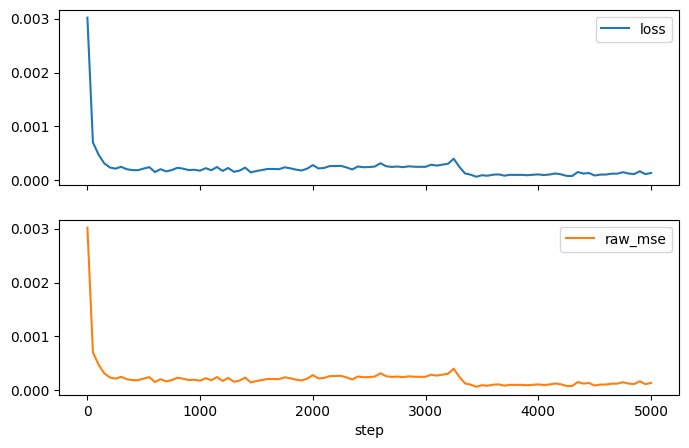

In [18]:
cm = train_method("CM", cm, cm_loss, sample_cm, target=cm_target)
show_training("CM")

CM boundary identity: PASS; CT approximation and benchmark adaptations remain


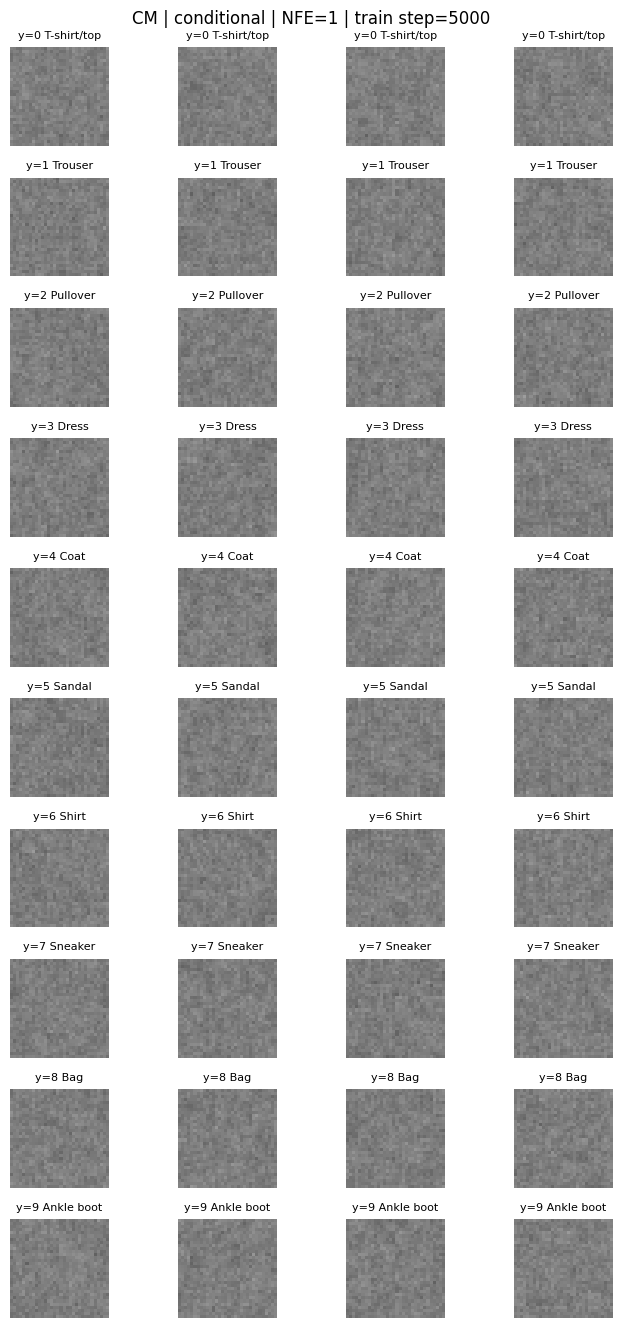

CM {'feature_fid': 989.9029507856031, 'kid': 272.3115934505919, 'condition_accuracy': 0.10000000149011612, 'class_entropy': -0.0, 'train_steps': 5000, 'train_s': 647.049655066, 'stop_reason': 'early_stop_at', 'optimizer_backend': 'torch.optim.Muon', 'nfe': 1, 'eval_s': 0.4262687330001427}


/tmp/ipykernel_528/304162648.py:94: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root = sqrtm(real_cov @ fake_cov)


In [19]:
# @title CM — boundary verification / conditional generation
z, y = make_noise(NUM_CLASSES, SEED), torch.arange(NUM_CLASSES, device=DEVICE)
sigma = torch.full((len(z),), CM_SIGMA_MIN, device=DEVICE)

with torch.no_grad():
    assert torch.allclose(cm_f(cm, z, sigma, y), z, atol=1e-6)

print("CM boundary identity: PASS; CT approximation and benchmark adaptations remain")
show_conditional(cm, sample_cm, "CM", DEFAULT_NFE["CM"], RUN_INFO["CM"]["train_steps"])
cm_samples = evaluate_method("CM", sample_cm)

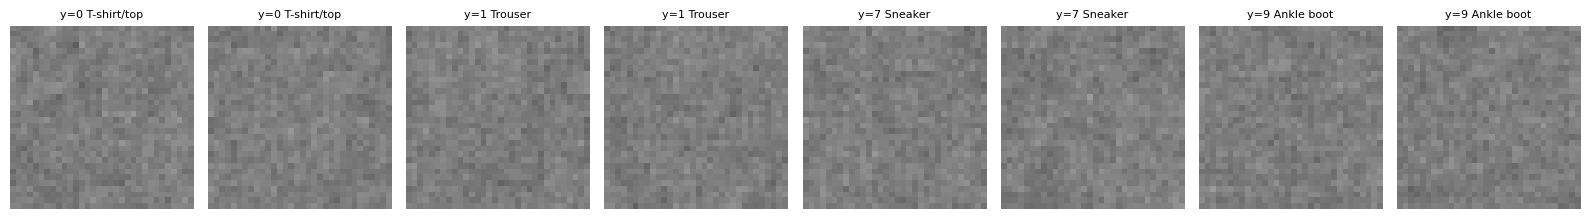

In [20]:
# @title CM — 원하는 클래스 직접 생성 (라벨·seed·NFE 수정)
# 0 T-shirt, 1 Trouser, 2 Pullover, 3 Dress, 4 Coat,
# 5 Sandal, 6 Shirt, 7 Sneaker, 8 Bag, 9 Ankle boot
requested_labels = [0, 0, 1, 1, 7, 7, 9, 9]
requested_nfe = DEFAULT_NFE["CM"]
requested_seed = SEED + 20_000
custom_images = generate_conditioned(
    MODELS["CM"], sample_cm, requested_labels, requested_nfe, seed=requested_seed
)
fig, axes = plt.subplots(
    1, len(requested_labels), figsize=(2 * len(requested_labels), 2.5), squeeze=False
)

for ax, image, label in zip(axes.flat, custom_images, requested_labels):
    ax.imshow(((image[0] + 1) / 2).clamp(0, 1), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"y={label} {CLASS_NAMES[label]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Consistency Trajectory Models — arbitrary-time soft consistency

고정 FM teacher로 \(t\to u\)를 적분하고, EMA student로 \(u\to s\)를 이동한 결과를 online student의 \(t\to s\)와 맞춘다.
두 \(s\)-시점 예측을 frozen student로 endpoint까지 옮겨 MSE로 비교한다. **online 쪽 endpoint projection은 파라미터만 고정하고 입력 미분은 유지한다.**

\[
G_\theta(z,t,s)=z-(t-s)q_\theta(z,t,t-s,y)
=\frac{s}{t}z+(1-\frac{s}{t})g_\theta(z,t,s),\quad g_\theta=z-tq_\theta.
\]

이 residual 표현은 \(G(z,t,t)=z\)를 정확히 만족하며 zero-initialized DiT에서도 identity로 시작한다.
대각선 denoising 항 \(\|g_\theta(z_t,t,t)-x\|^2\)을 더한다.
**적응:** diffusion teacher 대신 linear FM teacher, pixel MSE, 고정 보조 손실 가중치, GAN 생략. 원 CTM의 full recipe와 구분한다.


In [21]:
# @title CTM — soft consistency and diagonal denoising
def ctm_map(model, z, t, s, labels):
    return z - expand_time(t - s) * model(z, t, t - s, labels)


@torch.no_grad()
def sample_ctm(model, noise, labels, steps):
    if steps < 1:
        raise ValueError("steps must be positive")

    z = noise

    for k in range(steps):
        t = torch.full((len(z),), 1 - k / steps, device=z.device)
        s = torch.full_like(t, 1 - (k + 1) / steps)
        z = ctm_map(model, z, t, s, labels)

    return z


ctm = fresh_model()
ctm_target = freeze_copy(ctm)


def ctm_loss(model, images, labels, step):
    t = torch.rand(len(images), device=DEVICE)
    s = torch.rand_like(t) * t
    u = s + torch.rand_like(t) * (t - s)
    noise = torch.randn_like(images)
    z = (1 - expand_time(t)) * images + expand_time(t) * noise

    with torch.no_grad():
        at_u = integrate_fm(fm, z, t, u, labels, CTM_TEACHER_NFE)
        target_s = ctm_map(ctm_target, at_u, u, s, labels)
        target_zero = ctm_map(ctm_target, target_s, s, torch.zeros_like(s), labels)

    prediction_s = ctm_map(model, z, t, s, labels)
    # Frozen parameters, but preserve d(projection)/d(prediction_s).
    prediction_zero = ctm_map(ctm_target, prediction_s, s, torch.zeros_like(s), labels)
    consistency = F.mse_loss(prediction_zero, target_zero)
    denoised = z - expand_time(t) * model(z, t, torch.zeros_like(t), labels)
    denoise = F.mse_loss(denoised, images)

    return consistency + CTM_DENOISE_WEIGHT * denoise, {
        "soft_consistency": consistency.detach(),
        "denoise_mse": denoise.detach(),
    }

CTM torch.optim.Muon max= 20000 stop_at= 5000
CTM {'step': 1, 'loss': 0.6140891313552856, 'grad_norm': 0.8630461692810059, 'soft_consistency': 0.0555659718811512, 'denoise_mse': 0.5585231781005859}
CTM {'step': 50, 'loss': 0.2124626189470291, 'grad_norm': 0.3732946813106537, 'soft_consistency': 0.035820186138153076, 'denoise_mse': 0.17664243280887604}
CTM {'step': 100, 'loss': 0.12502813339233398, 'grad_norm': 0.2175615280866623, 'soft_consistency': 0.014939984306693077, 'denoise_mse': 0.11008815467357635}
CTM {'step': 150, 'loss': 0.12526719272136688, 'grad_norm': 0.20786736905574799, 'soft_consistency': 0.019411036744713783, 'denoise_mse': 0.10585615038871765}
CTM {'step': 200, 'loss': 0.09099647402763367, 'grad_norm': 0.27524906396865845, 'soft_consistency': 0.010938631370663643, 'denoise_mse': 0.08005784451961517}
CTM {'step': 250, 'loss': 0.09928235411643982, 'grad_norm': 0.2298963963985443, 'soft_consistency': 0.017044084146618843, 'denoise_mse': 0.08223827183246613}
CTM {'step':

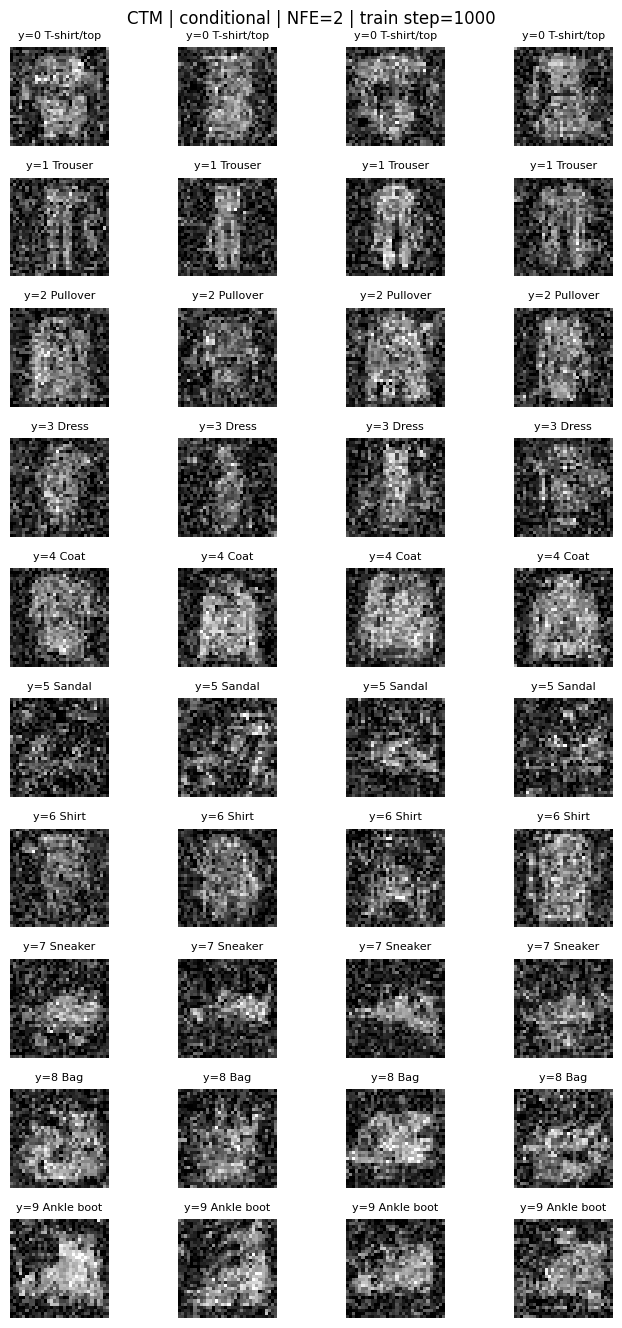

CTM {'step': 1050, 'loss': 0.054900649935007095, 'grad_norm': 0.1434878259897232, 'soft_consistency': 0.007427052594721317, 'denoise_mse': 0.04747359827160835}
CTM {'step': 1100, 'loss': 0.0562932975590229, 'grad_norm': 0.1649980992078781, 'soft_consistency': 0.006496799644082785, 'denoise_mse': 0.04979649931192398}
CTM {'step': 1150, 'loss': 0.06836450845003128, 'grad_norm': 0.26292625069618225, 'soft_consistency': 0.007072108797729015, 'denoise_mse': 0.06129239872097969}
CTM {'step': 1200, 'loss': 0.06791055202484131, 'grad_norm': 0.14005298912525177, 'soft_consistency': 0.011814221739768982, 'denoise_mse': 0.05609632655978203}
CTM {'step': 1250, 'loss': 0.06320428103208542, 'grad_norm': 0.15494829416275024, 'soft_consistency': 0.009072794578969479, 'denoise_mse': 0.054131485521793365}
CTM {'step': 1300, 'loss': 0.056175630539655685, 'grad_norm': 0.16704876720905304, 'soft_consistency': 0.008288566023111343, 'denoise_mse': 0.04788706451654434}
CTM {'step': 1350, 'loss': 0.05500664561

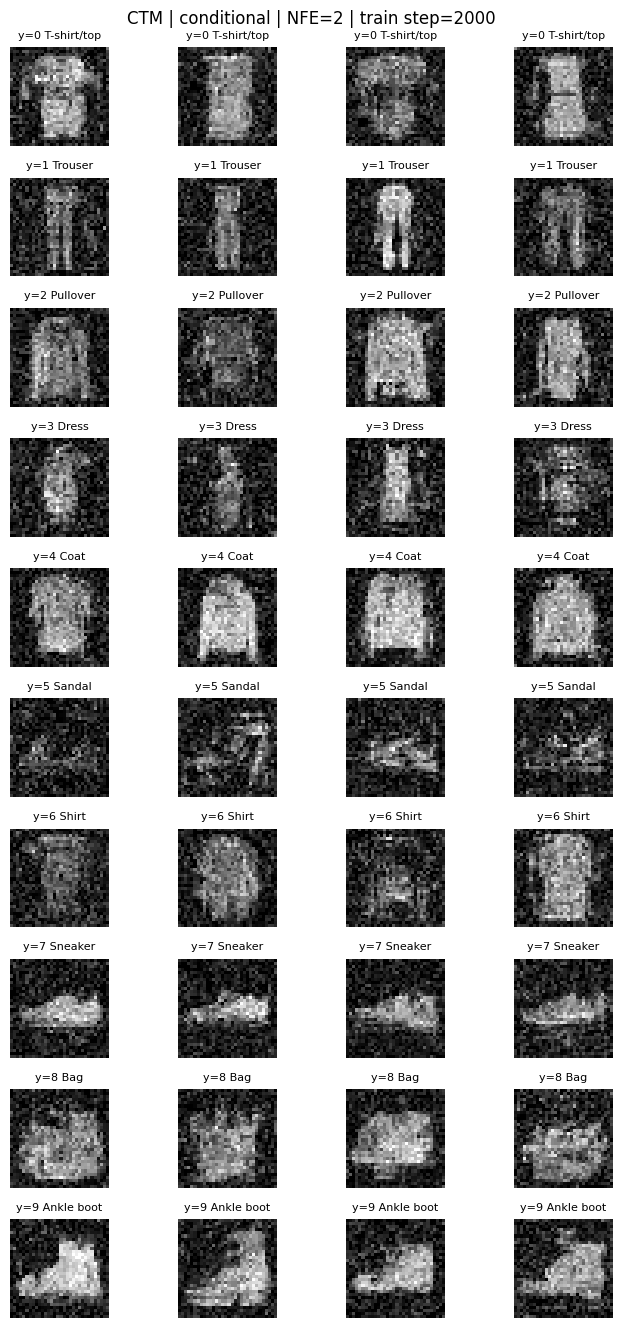

CTM {'step': 2050, 'loss': 0.05939198657870293, 'grad_norm': 0.13440537452697754, 'soft_consistency': 0.004579548723995686, 'denoise_mse': 0.054812438786029816}
CTM {'step': 2100, 'loss': 0.0513976514339447, 'grad_norm': 0.16502487659454346, 'soft_consistency': 0.0049305688589811325, 'denoise_mse': 0.04646708071231842}
CTM {'step': 2150, 'loss': 0.06524597853422165, 'grad_norm': 0.2754671573638916, 'soft_consistency': 0.004103763960301876, 'denoise_mse': 0.0611422136425972}
CTM {'step': 2200, 'loss': 0.042179666459560394, 'grad_norm': 0.1259288340806961, 'soft_consistency': 0.0038079724181443453, 'denoise_mse': 0.03837169334292412}
CTM {'step': 2250, 'loss': 0.05607053264975548, 'grad_norm': 0.17907880246639252, 'soft_consistency': 0.0038375291042029858, 'denoise_mse': 0.052233003079891205}
CTM {'step': 2300, 'loss': 0.05440988764166832, 'grad_norm': 0.16906240582466125, 'soft_consistency': 0.004862528759986162, 'denoise_mse': 0.049547359347343445}
CTM {'step': 2350, 'loss': 0.05816096

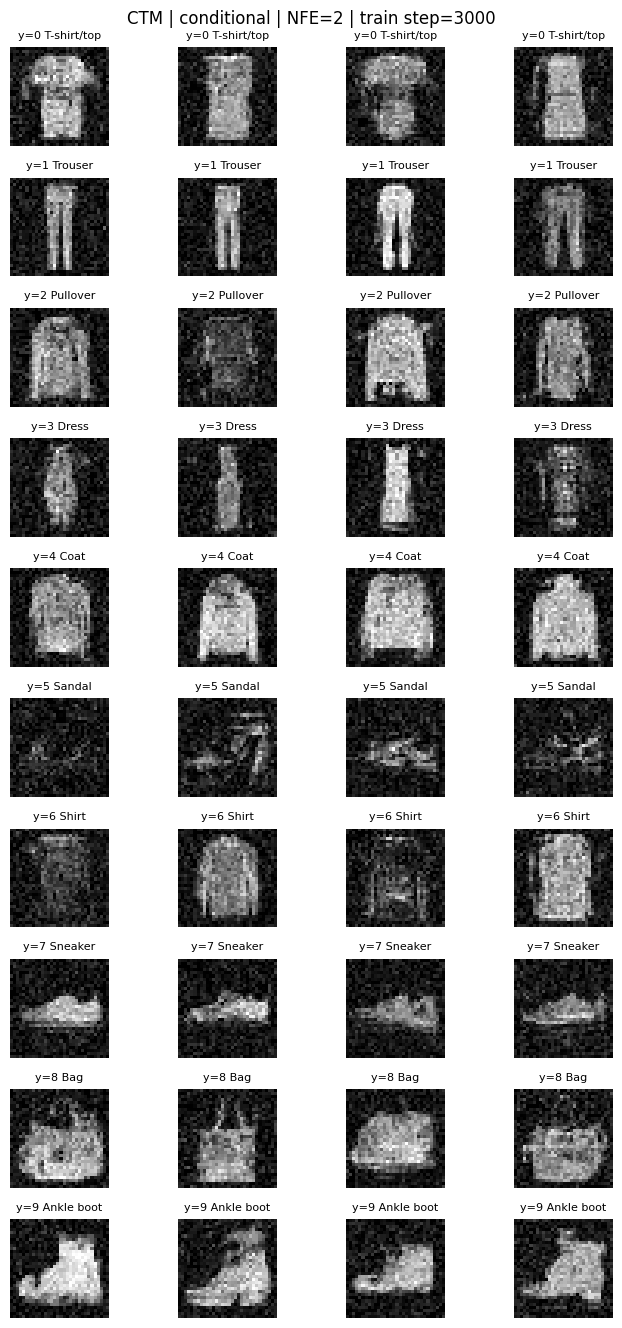

CTM {'step': 3050, 'loss': 0.05367457866668701, 'grad_norm': 0.1299816370010376, 'soft_consistency': 0.0028871512040495872, 'denoise_mse': 0.05078742653131485}
CTM {'step': 3100, 'loss': 0.04609488323330879, 'grad_norm': 0.13620586693286896, 'soft_consistency': 0.003382484894245863, 'denoise_mse': 0.04271239787340164}
CTM {'step': 3150, 'loss': 0.06885534524917603, 'grad_norm': 0.14038272202014923, 'soft_consistency': 0.004128932952880859, 'denoise_mse': 0.06472641229629517}
CTM {'step': 3200, 'loss': 0.051754847168922424, 'grad_norm': 0.1345302164554596, 'soft_consistency': 0.0029759102035313845, 'denoise_mse': 0.04877893626689911}
CTM {'step': 3250, 'loss': 0.0524776354432106, 'grad_norm': 0.1440427601337433, 'soft_consistency': 0.0028694304637610912, 'denoise_mse': 0.04960820451378822}
CTM {'step': 3300, 'loss': 0.05774533376097679, 'grad_norm': 0.2365720272064209, 'soft_consistency': 0.003898442955687642, 'denoise_mse': 0.05384689196944237}
CTM {'step': 3350, 'loss': 0.061304237693

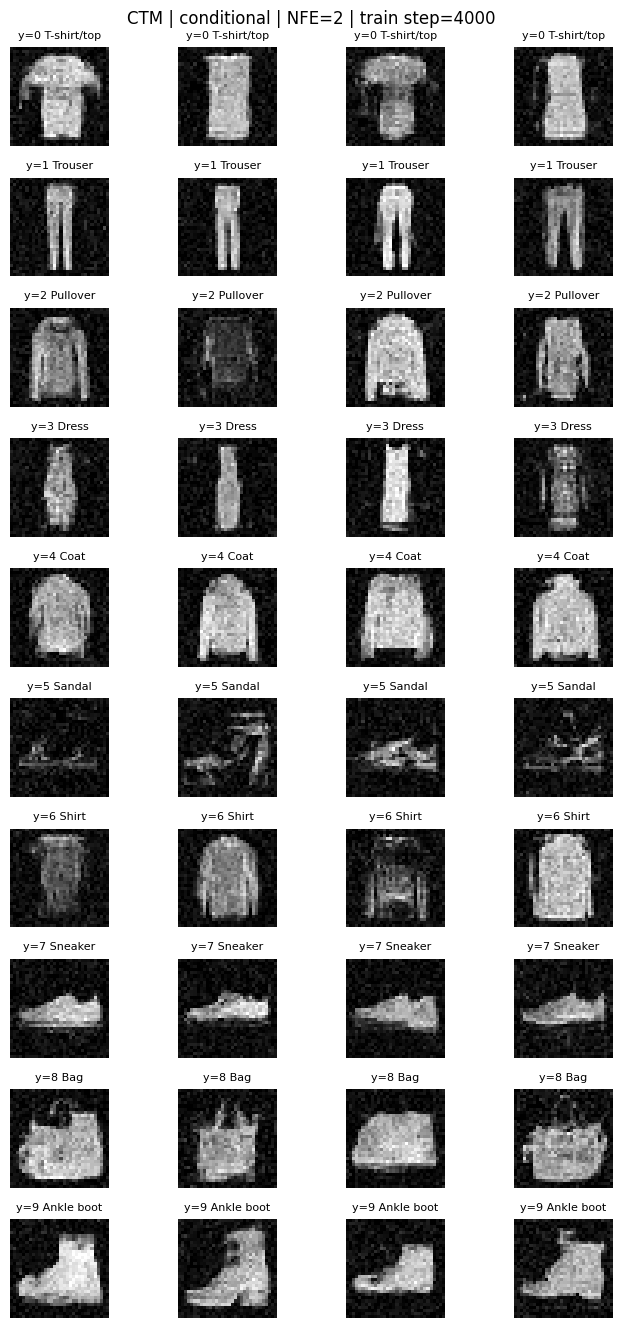

CTM {'step': 4050, 'loss': 0.059105344116687775, 'grad_norm': 0.19750913977622986, 'soft_consistency': 0.0034674620255827904, 'denoise_mse': 0.05563788115978241}
CTM {'step': 4100, 'loss': 0.04089441895484924, 'grad_norm': 0.12623028457164764, 'soft_consistency': 0.0024150852113962173, 'denoise_mse': 0.038479335606098175}
CTM {'step': 4150, 'loss': 0.049014799296855927, 'grad_norm': 0.10985026508569717, 'soft_consistency': 0.0016029110411182046, 'denoise_mse': 0.04741188883781433}
CTM {'step': 4200, 'loss': 0.055619142949581146, 'grad_norm': 0.14541667699813843, 'soft_consistency': 0.0023254898842424154, 'denoise_mse': 0.05329365283250809}
CTM {'step': 4250, 'loss': 0.057180847972631454, 'grad_norm': 0.15864218771457672, 'soft_consistency': 0.0031432530377060175, 'denoise_mse': 0.05403759330511093}
CTM {'step': 4300, 'loss': 0.05408808961510658, 'grad_norm': 0.14781393110752106, 'soft_consistency': 0.0018980257445946336, 'denoise_mse': 0.05219006538391113}
CTM {'step': 4350, 'loss': 0.

,step,loss,grad_norm,soft_consistency,denoise_mse
96,4800,0.040412,0.108859,0.001409,0.039003
97,4850,0.043174,0.161133,0.001482,0.041692
98,4900,0.062047,0.175339,0.003515,0.058532
99,4950,0.051203,0.131229,0.002424,0.048779
100,5000,0.053356,0.145442,0.001781,0.051574


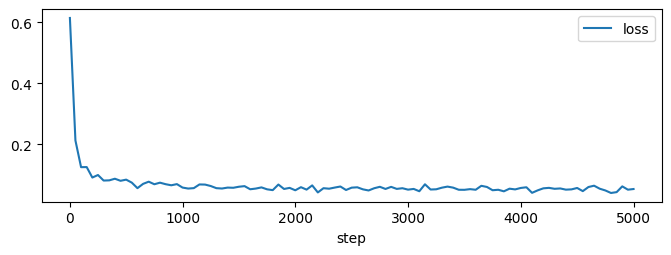

In [22]:
ctm = train_method("CTM", ctm, ctm_loss, sample_ctm, target=ctm_target)
show_training("CTM")

CTM identity / frozen target: PASS


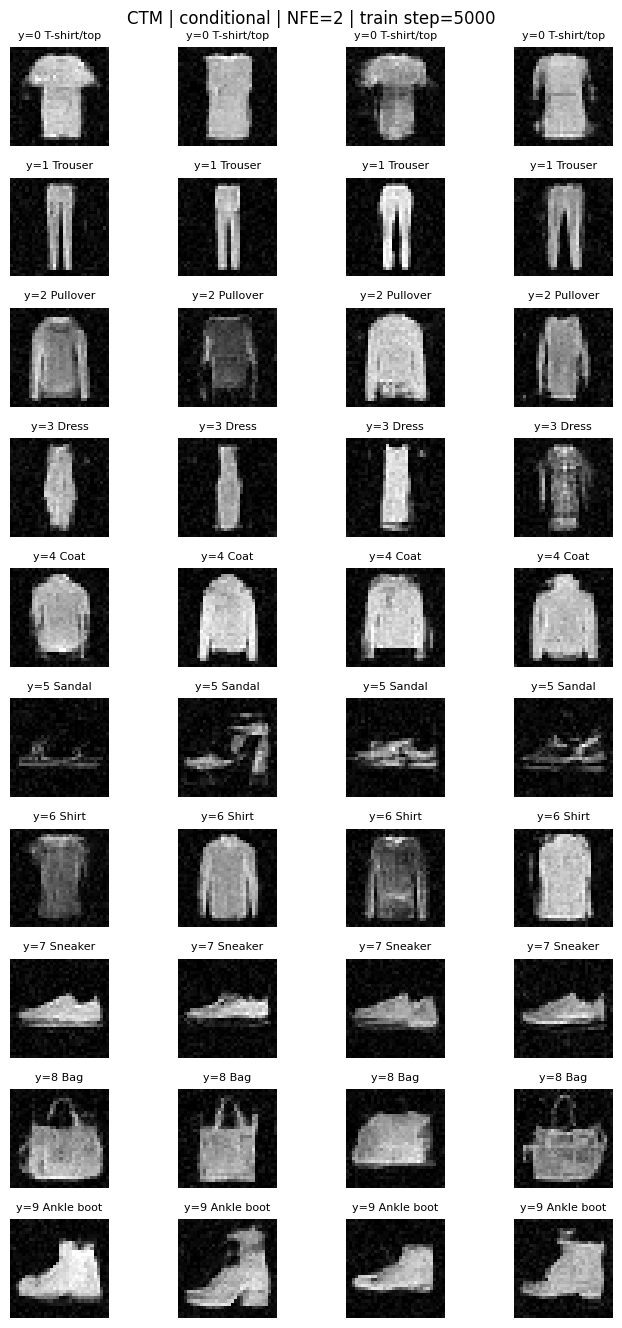

CTM {'feature_fid': 77.77760773568512, 'kid': 70.3394188480396, 'condition_accuracy': 0.8519999980926514, 'class_entropy': 2.262575387954712, 'train_steps': 5000, 'train_s': 2348.620046371, 'stop_reason': 'early_stop_at', 'optimizer_backend': 'torch.optim.Muon', 'nfe': 2, 'eval_s': 0.6332360230007907}


/tmp/ipykernel_528/304162648.py:94: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root = sqrtm(real_cov @ fake_cov)


In [23]:
# @title CTM — identity verification / conditional generation
z, y = make_noise(NUM_CLASSES, SEED), torch.arange(NUM_CLASSES, device=DEVICE)
t = torch.full((len(z),), 0.6, device=DEVICE)

with torch.no_grad():
    assert torch.allclose(ctm_map(ctm, z, t, t, y), z)

assert all(p.grad is None for p in ctm_target.parameters())
print("CTM identity / frozen target: PASS")
show_conditional(
    ctm, sample_ctm, "CTM", DEFAULT_NFE["CTM"], RUN_INFO["CTM"]["train_steps"]
)
ctm_samples = evaluate_method("CTM", sample_ctm)

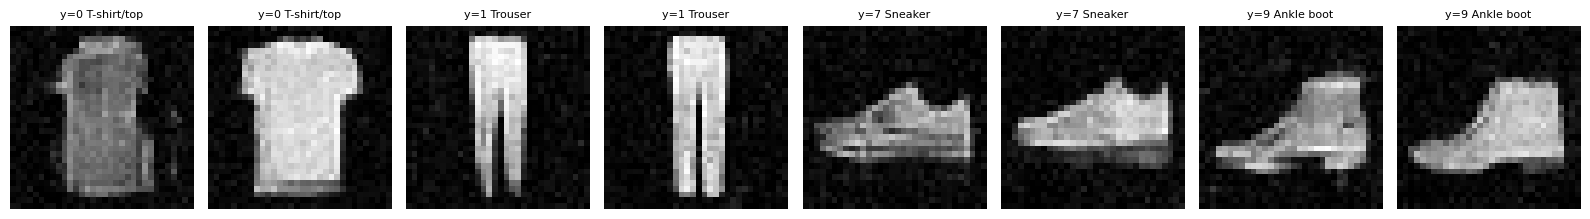

In [24]:
# @title CTM — 원하는 클래스 직접 생성 (라벨·seed·NFE 수정)
# 0 T-shirt, 1 Trouser, 2 Pullover, 3 Dress, 4 Coat,
# 5 Sandal, 6 Shirt, 7 Sneaker, 8 Bag, 9 Ankle boot
requested_labels = [0, 0, 1, 1, 7, 7, 9, 9]
requested_nfe = DEFAULT_NFE["CTM"]
requested_seed = SEED + 20_000
custom_images = generate_conditioned(
    MODELS["CTM"], sample_ctm, requested_labels, requested_nfe, seed=requested_seed
)
fig, axes = plt.subplots(
    1, len(requested_labels), figsize=(2 * len(requested_labels), 2.5), squeeze=False
)

for ax, image, label in zip(axes.flat, custom_images, requested_labels):
    ax.imshow(((image[0] + 1) / 2).clamp(0, 1), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"y={label} {CLASS_NAMES[label]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Shortcut Models — 두 작은 이동으로 큰 이동 학습

이 절은 noise=0 → data=1 방향이다. `d=0` 표본은 FM target \(x-\epsilon\)을 학습한다.
나머지는 두 번의 \(d/2\) 이동에서 얻은 평균 속도를 stop-gradient target으로 사용해 \(d\) 이동을 학습한다.
bootstrap의 두 번째 호출은 첫 번째 예측으로 이동한 위치에서 수행하며, 두 호출 모두 같은 클래스 조건을 사용한다.
**적응:** 16단계 dyadic hierarchy, 공통 DiT와 Muon. MeanFlow의 시간 분포·adaptive weighting은 적용하지 않는다.


In [25]:
# @title Shortcut — bootstrap objective and dyadic sampler
def shortcut_loss(model, images, labels, step):
    if SHORTCUT_LEVELS < 2 or SHORTCUT_LEVELS & (SHORTCUT_LEVELS - 1):
        raise ValueError("SHORTCUT_LEVELS must be a power of two >= 2")

    n = len(images)
    noise = torch.randn_like(images)
    t = torch.rand(n, device=DEVICE)
    mask = torch.rand(n, device=DEVICE) < SHORTCUT_FM_FRACTION
    d = torch.zeros_like(t)
    indices = (~mask).nonzero(as_tuple=True)[0]
    levels = int(math.log2(SHORTCUT_LEVELS))
    half_steps = (
        2.0 ** torch.randint(0, levels, (len(indices),), device=DEVICE)
        / SHORTCUT_LEVELS
    )
    slots = torch.round(1 / half_steps).long() - 1
    k = torch.floor(torch.rand(len(indices), device=DEVICE) * slots).long()
    t[indices] = k * half_steps
    d[indices] = 2 * half_steps
    z = (1 - expand_time(t)) * noise + expand_time(t) * images
    target = noise.neg() + images

    if len(indices):
        with torch.no_grad():
            first = model(z[indices], t[indices], half_steps, labels[indices])
            middle = z[indices] + expand_time(half_steps) * first
            second = model(middle, t[indices] + half_steps, half_steps, labels[indices])
            target[indices] = (first + second) / 2

    prediction = model(z, t, d, labels)
    loss = F.mse_loss(prediction, target)

    return loss, {
        "raw_mse": loss.detach(),
        "fm_fraction": mask.float().mean(),
        "mean_d": d.mean(),
    }


@torch.no_grad()
def sample_shortcut(model, noise, labels, steps):
    if steps < 1 or steps > SHORTCUT_LEVELS or steps & (steps - 1):
        raise ValueError("Use a power-of-two NFE within the trained hierarchy")

    z = noise

    for k in range(steps):
        t = torch.full((len(z),), k / steps, device=z.device)
        d = torch.full_like(t, 1 / steps)
        z = z + expand_time(d) * model(z, t, d, labels)

    return z

Shortcut torch.optim.Muon max= 20000 stop_at= 5000
Shortcut {'step': 1, 'loss': 1.1477959156036377, 'grad_norm': 2.1506826877593994, 'raw_mse': 1.1477959156036377, 'fm_fraction': 0.65625, 'mean_d': 0.1611328125}
Shortcut {'step': 50, 'loss': 0.46551430225372314, 'grad_norm': 1.0745738744735718, 'raw_mse': 0.46551430225372314, 'fm_fraction': 0.78125, 'mean_d': 0.0986328125}
Shortcut {'step': 100, 'loss': 0.29358476400375366, 'grad_norm': 0.6203648447990417, 'raw_mse': 0.29358476400375366, 'fm_fraction': 0.7421875, 'mean_d': 0.130859375}
Shortcut {'step': 150, 'loss': 0.24306705594062805, 'grad_norm': 0.6234115958213806, 'raw_mse': 0.24306705594062805, 'fm_fraction': 0.7109375, 'mean_d': 0.123046875}
Shortcut {'step': 200, 'loss': 0.22445958852767944, 'grad_norm': 0.650295615196228, 'raw_mse': 0.22445958852767944, 'fm_fraction': 0.75, 'mean_d': 0.11328125}
Shortcut {'step': 250, 'loss': 0.1864955574274063, 'grad_norm': 0.5191258788108826, 'raw_mse': 0.1864955574274063, 'fm_fraction': 0.7

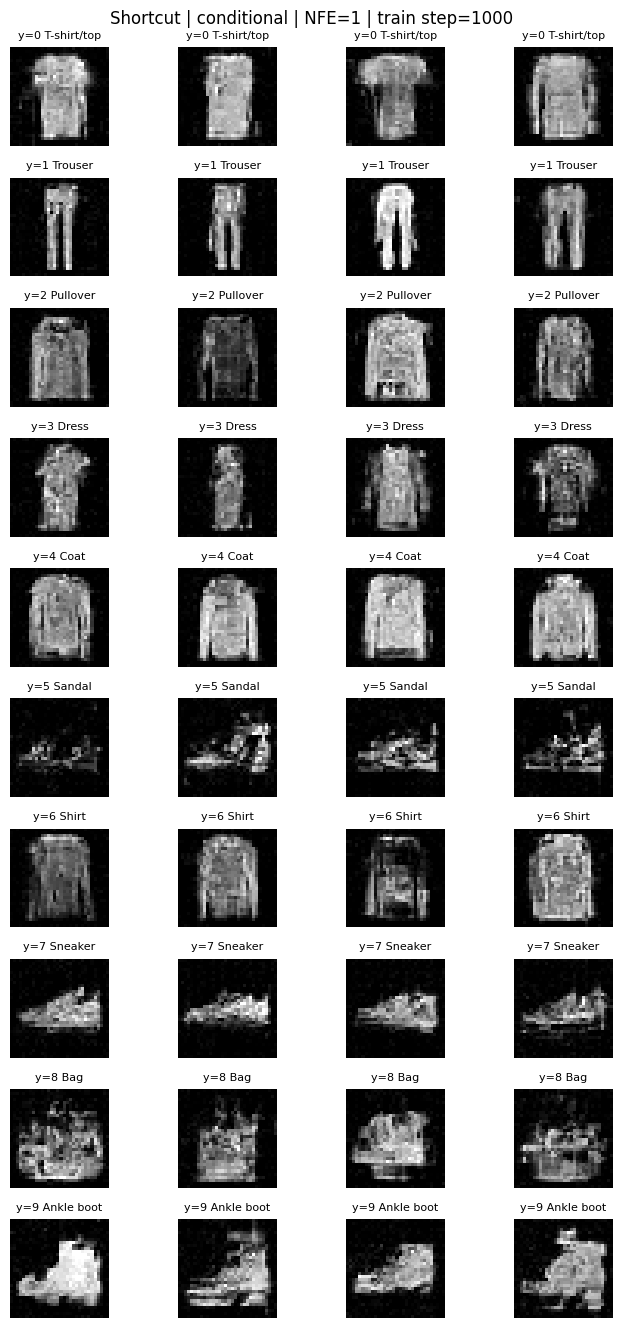

Shortcut {'step': 1050, 'loss': 0.12296949326992035, 'grad_norm': 0.38042110204696655, 'raw_mse': 0.12296949326992035, 'fm_fraction': 0.671875, 'mean_d': 0.1640625}
Shortcut {'step': 1100, 'loss': 0.13941705226898193, 'grad_norm': 0.5796101689338684, 'raw_mse': 0.13941705226898193, 'fm_fraction': 0.71875, 'mean_d': 0.1708984375}
Shortcut {'step': 1150, 'loss': 0.15588435530662537, 'grad_norm': 0.3772757649421692, 'raw_mse': 0.15588435530662537, 'fm_fraction': 0.765625, 'mean_d': 0.1142578125}
Shortcut {'step': 1200, 'loss': 0.14219947159290314, 'grad_norm': 0.3918924331665039, 'raw_mse': 0.14219947159290314, 'fm_fraction': 0.7421875, 'mean_d': 0.134765625}
Shortcut {'step': 1250, 'loss': 0.14548510313034058, 'grad_norm': 0.4880133271217346, 'raw_mse': 0.14548510313034058, 'fm_fraction': 0.71875, 'mean_d': 0.130859375}
Shortcut {'step': 1300, 'loss': 0.14351193606853485, 'grad_norm': 0.41920021176338196, 'raw_mse': 0.14351193606853485, 'fm_fraction': 0.703125, 'mean_d': 0.1552734375}
Sh

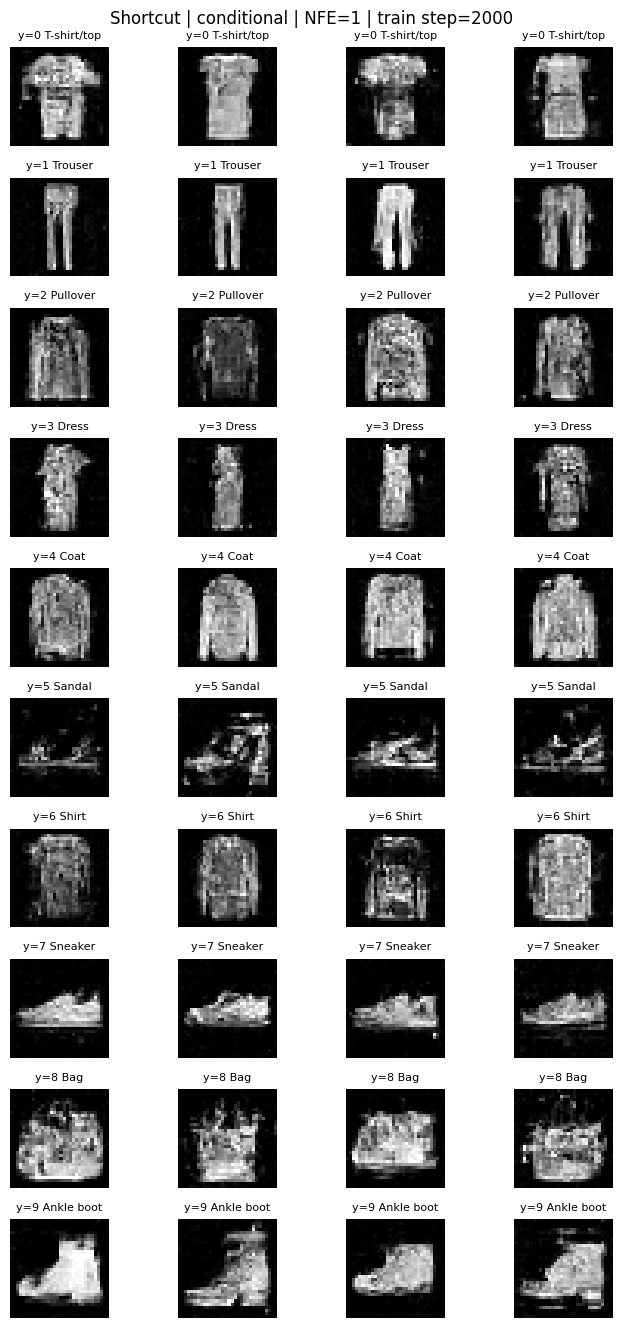

Shortcut {'step': 2050, 'loss': 0.15737012028694153, 'grad_norm': 0.31188246607780457, 'raw_mse': 0.15737012028694153, 'fm_fraction': 0.8046875, 'mean_d': 0.0966796875}
Shortcut {'step': 2100, 'loss': 0.12181331217288971, 'grad_norm': 0.3016723692417145, 'raw_mse': 0.12181331217288971, 'fm_fraction': 0.7421875, 'mean_d': 0.1025390625}
Shortcut {'step': 2150, 'loss': 0.13872623443603516, 'grad_norm': 0.41195932030677795, 'raw_mse': 0.13872623443603516, 'fm_fraction': 0.75, 'mean_d': 0.13671875}
Shortcut {'step': 2200, 'loss': 0.12166488915681839, 'grad_norm': 0.22948279976844788, 'raw_mse': 0.12166488915681839, 'fm_fraction': 0.71875, 'mean_d': 0.1201171875}
Shortcut {'step': 2250, 'loss': 0.14915627241134644, 'grad_norm': 0.32222113013267517, 'raw_mse': 0.14915627241134644, 'fm_fraction': 0.765625, 'mean_d': 0.15234375}
Shortcut {'step': 2300, 'loss': 0.1446208357810974, 'grad_norm': 0.3230366110801697, 'raw_mse': 0.1446208357810974, 'fm_fraction': 0.765625, 'mean_d': 0.1064453125}
Sho

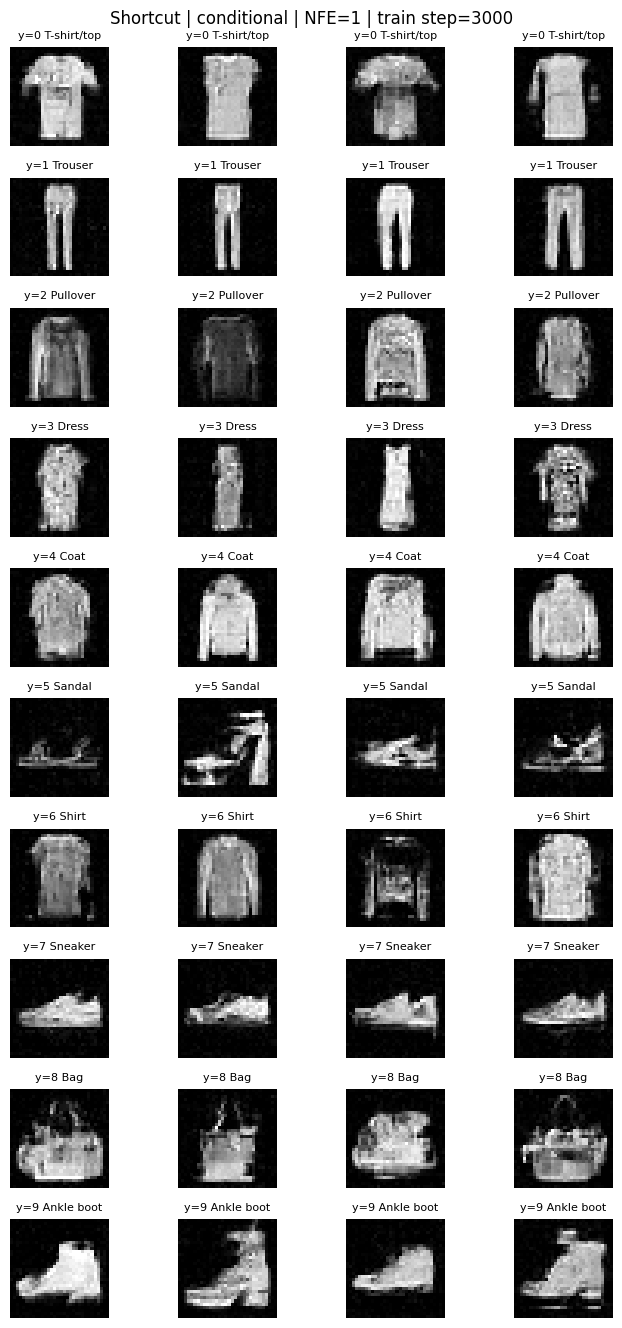

Shortcut {'step': 3050, 'loss': 0.1430993676185608, 'grad_norm': 0.358913779258728, 'raw_mse': 0.1430993676185608, 'fm_fraction': 0.7578125, 'mean_d': 0.107421875}
Shortcut {'step': 3100, 'loss': 0.1244816929101944, 'grad_norm': 0.31113162636756897, 'raw_mse': 0.1244816929101944, 'fm_fraction': 0.734375, 'mean_d': 0.119140625}
Shortcut {'step': 3150, 'loss': 0.11567097157239914, 'grad_norm': 0.23842494189739227, 'raw_mse': 0.11567097157239914, 'fm_fraction': 0.6796875, 'mean_d': 0.138671875}
Shortcut {'step': 3200, 'loss': 0.11471740901470184, 'grad_norm': 0.3109250068664551, 'raw_mse': 0.11471740901470184, 'fm_fraction': 0.703125, 'mean_d': 0.095703125}
Shortcut {'step': 3250, 'loss': 0.11968441307544708, 'grad_norm': 0.2206333428621292, 'raw_mse': 0.11968441307544708, 'fm_fraction': 0.703125, 'mean_d': 0.1279296875}
Shortcut {'step': 3300, 'loss': 0.13050562143325806, 'grad_norm': 0.21350795030593872, 'raw_mse': 0.13050562143325806, 'fm_fraction': 0.765625, 'mean_d': 0.138671875}
Sho

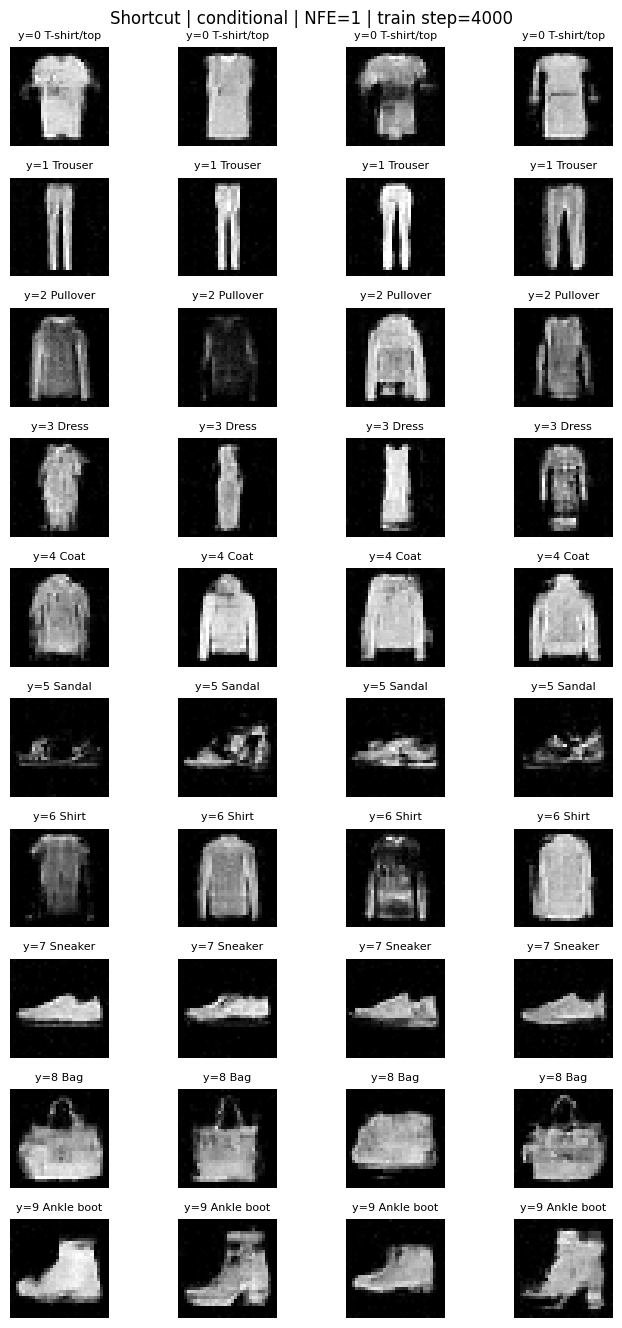

Shortcut {'step': 4050, 'loss': 0.15774773061275482, 'grad_norm': 0.4529217481613159, 'raw_mse': 0.15774773061275482, 'fm_fraction': 0.8359375, 'mean_d': 0.08203125}
Shortcut {'step': 4100, 'loss': 0.11377868056297302, 'grad_norm': 0.25467443466186523, 'raw_mse': 0.11377868056297302, 'fm_fraction': 0.7578125, 'mean_d': 0.0947265625}
Shortcut {'step': 4150, 'loss': 0.11878395080566406, 'grad_norm': 0.23459652066230774, 'raw_mse': 0.11878395080566406, 'fm_fraction': 0.734375, 'mean_d': 0.1083984375}
Shortcut {'step': 4200, 'loss': 0.1341329663991928, 'grad_norm': 0.4341357946395874, 'raw_mse': 0.1341329663991928, 'fm_fraction': 0.78125, 'mean_d': 0.10546875}
Shortcut {'step': 4250, 'loss': 0.13135191798210144, 'grad_norm': 0.36861753463745117, 'raw_mse': 0.13135191798210144, 'fm_fraction': 0.8046875, 'mean_d': 0.109375}
Shortcut {'step': 4300, 'loss': 0.1223839819431305, 'grad_norm': 0.26818856596946716, 'raw_mse': 0.1223839819431305, 'fm_fraction': 0.7109375, 'mean_d': 0.130859375}
Shor

,step,loss,grad_norm,raw_mse,fm_fraction,mean_d
96,4800,0.125433,0.371510,0.125433,0.679688,0.140625
97,4850,0.141145,0.302773,0.141145,0.812500,0.086914
98,4900,0.124484,0.226481,0.124484,0.734375,0.147461
99,4950,0.116120,0.291098,0.116120,0.687500,0.127930
100,5000,0.120394,0.208820,0.120394,0.757812,0.089844


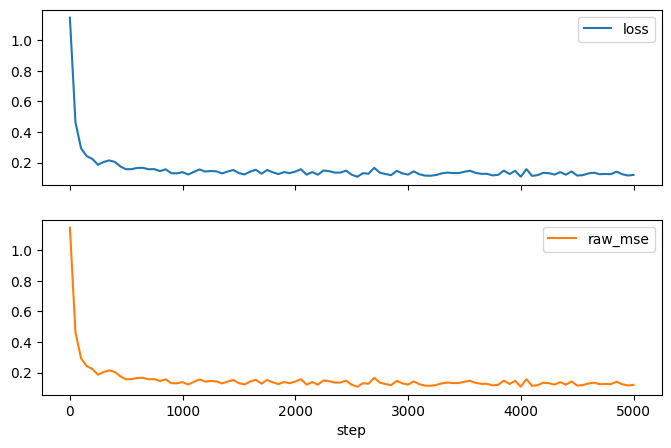

In [26]:
shortcut = train_method("Shortcut", fresh_model(), shortcut_loss, sample_shortcut)
show_training("Shortcut")

Shortcut forward-time one-step update: PASS


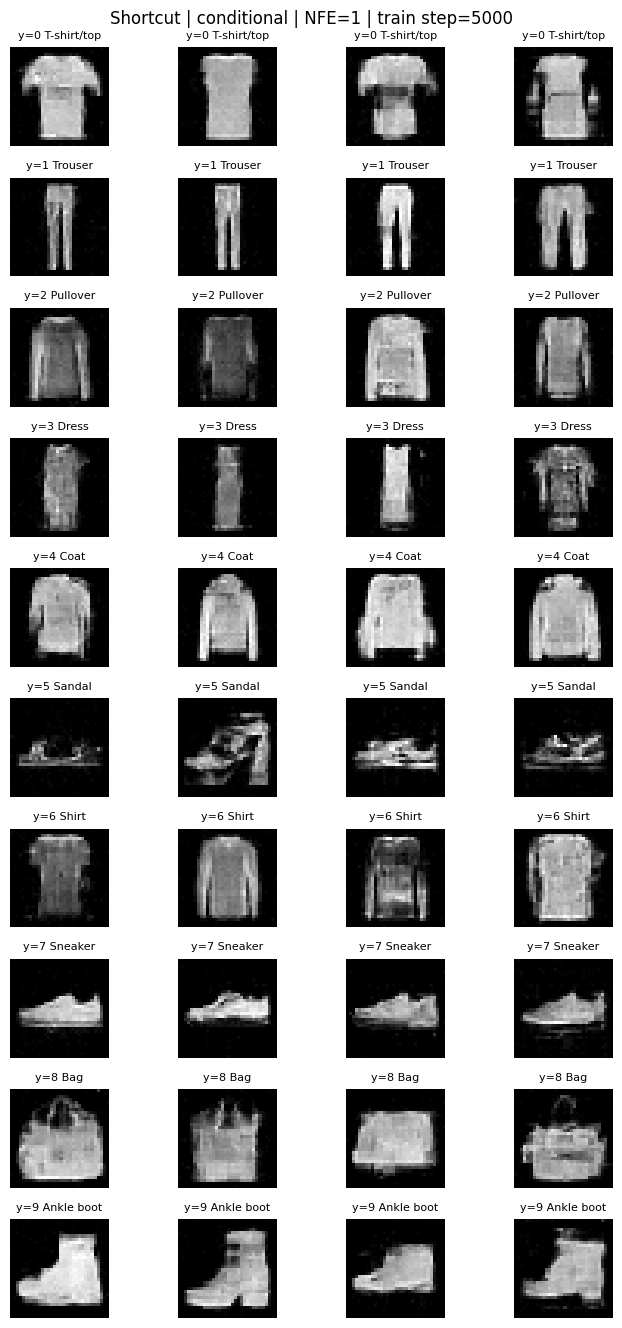

Shortcut {'feature_fid': 49.8974299249919, 'kid': 42.38333025538293, 'condition_accuracy': 0.8600000143051147, 'class_entropy': 2.291754722595215, 'train_steps': 5000, 'train_s': 597.493981992, 'stop_reason': 'early_stop_at', 'optimizer_backend': 'torch.optim.Muon', 'nfe': 1, 'eval_s': 0.5464154069995857}


/tmp/ipykernel_528/304162648.py:94: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root = sqrtm(real_cov @ fake_cov)


In [27]:
# @title Shortcut — one-step verification / conditional generation
z, y = make_noise(NUM_CLASSES, SEED), torch.arange(NUM_CLASSES, device=DEVICE)
t = torch.zeros(len(z), device=DEVICE)

with torch.no_grad():
    assert torch.allclose(
        sample_shortcut(shortcut, z, y, 1), z + shortcut(z, t, torch.ones_like(t), y)
    )

print("Shortcut forward-time one-step update: PASS")
show_conditional(
    shortcut,
    sample_shortcut,
    "Shortcut",
    DEFAULT_NFE["Shortcut"],
    RUN_INFO["Shortcut"]["train_steps"],
)
shortcut_samples = evaluate_method("Shortcut", sample_shortcut)

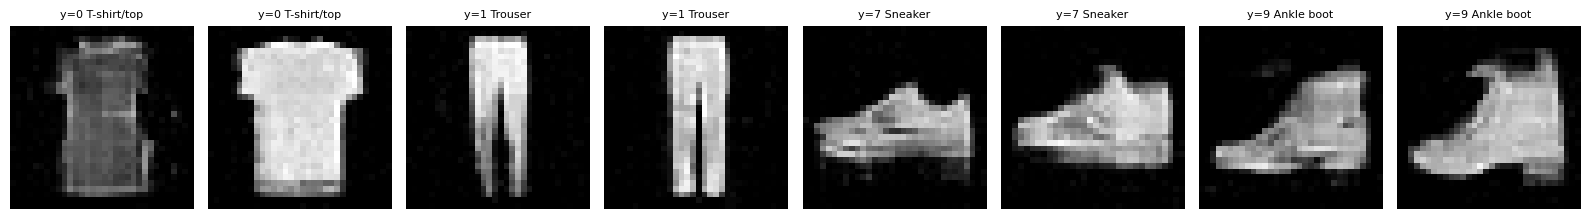

In [28]:
# @title Shortcut — 원하는 클래스 직접 생성 (라벨·seed·NFE 수정)
# 0 T-shirt, 1 Trouser, 2 Pullover, 3 Dress, 4 Coat,
# 5 Sandal, 6 Shirt, 7 Sneaker, 8 Bag, 9 Ankle boot
requested_labels = [0, 0, 1, 1, 7, 7, 9, 9]
requested_nfe = DEFAULT_NFE["Shortcut"]
requested_seed = SEED + 20_000
custom_images = generate_conditioned(
    MODELS["Shortcut"],
    sample_shortcut,
    requested_labels,
    requested_nfe,
    seed=requested_seed,
)
fig, axes = plt.subplots(
    1, len(requested_labels), figsize=(2 * len(requested_labels), 2.5), squeeze=False
)

for ax, image, label in zip(axes.flat, custom_images, requested_labels):
    ax.imshow(((image[0] + 1) / 2).clamp(0, 1), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"y={label} {CLASS_NAMES[label]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6. MeanFlow — 평균 속도


\[
u_\text{target}=v_t-(t-r)\frac{d}{dt}u_\theta(z_t,r,t,y),\qquad v_t=\epsilon-x.
\]

minimal의 logit-normal pair, 75% `r=t` 표본, adaptive weighting, 현재 모델 생성 방식을 따른다.
네트워크 입력은 `(z,t,t-r,y)`이며 JVP는 `(z,t,r)` 좌표에서 tangent `(v,1,0)`을 사용한다. `t-r`은 JVP 함수 안에서 계산한다.
target 전체를 detach하고, label은 고정한다. 클래스 조건만 사용하며 classifier-free guidance는 추가하지 않는다.

adaptive loss는 `SSE/(stopgrad(SSE)+0.01)`이므로 값이 거의 1이어도 학습될 수 있다.
고정 진단 배치의 raw MSE·boundary MSE·interval MSE·cosine과 조건부 생성 그림을 함께 본다.
상한 20,000 step을 유지하고 기본적으로 5,000번째 업데이트·저장을 마친 뒤 중단한다.


In [29]:
# @title MeanFlow — minimal objective, derivative, diagnostic, sampler
def logit_normal(n):
    return torch.sigmoid(torch.randn(n, device=DEVICE) * P_STD + P_MEAN)


def sample_meanflow_tuple(images):
    first = logit_normal(len(images))
    second = logit_normal(len(images))
    t = torch.maximum(first, second)
    r = torch.minimum(first, second)
    boundary_count = int(len(images) * DATA_PROPORTION)
    r[:boundary_count] = t[:boundary_count]
    noise = torch.randn_like(images)
    z = (1 - expand_time(t)) * images + expand_time(t) * noise

    return z, noise - images, r, t


def meanflow_outputs(model, z, velocity, r, t, labels):
    def fn(z_arg, t_arg, r_arg):
        return model(z_arg, t_arg, t_arg - r_arg, labels)

    prediction, derivative = jvp(
        fn, (z, t, r), (velocity, torch.ones_like(t), torch.zeros_like(r))
    )
    target = (velocity - expand_time(t - r) * derivative).detach()

    return prediction, target


def meanflow_loss(model, images, labels, step):
    z, velocity, r, t = sample_meanflow_tuple(images)
    prediction, target = meanflow_outputs(model, z, velocity, r, t, labels)
    sse = (prediction - target).square().flatten(1).sum(1)
    weight = (sse.detach() + NORM_EPS).reciprocal()

    return (sse * weight).mean(), {"raw_mse": sse.mean().detach() / images[0].numel()}


@torch.no_grad()
def sample_meanflow(model, noise, labels, steps):
    if steps < 1:
        raise ValueError("steps must be positive")

    z = noise

    for k in range(steps):
        t = torch.full((len(z),), 1 - k / steps, device=z.device)
        r = torch.full_like(t, 1 - (k + 1) / steps)
        z = z - expand_time(t - r) * model(z, t, t - r, labels)

    return z


# Use train data for diagnostics; final test evaluation does not choose stop steps.

with isolated_rng():
    diag_iterator = iter(train_loader)
    diag_images, diag_labels = next(diag_iterator)
    diag_images, diag_labels = (
        diag_images[:DIAG_BATCH].to(DEVICE),
        diag_labels[:DIAG_BATCH].to(DEVICE),
    )
    diag_tuple = sample_meanflow_tuple(diag_images)


@torch.no_grad()
def meanflow_diagnostic(model):
    z, velocity, r, t = diag_tuple
    prediction, target = meanflow_outputs(model, z, velocity, r, t, diag_labels)
    mse = (prediction - target).square().flatten(1).mean(1)
    cosine = F.cosine_similarity(prediction.flatten(1), target.flatten(1), dim=1)
    boundary = r == t
    interval = r < t

    return {
        "boundary_mse": float(mse[boundary].mean()),
        "interval_mse": float(mse[interval].mean()),
        "interval_cosine": float(cosine[interval].mean()),
    }

MeanFlow torch.optim.Muon max= 20000 stop_at= 5000
MeanFlow {'step': 1, 'loss': 0.9999943971633911, 'grad_norm': 1.9592127799987793, 'raw_mse': 1.748896598815918}
MeanFlow {'step': 50, 'loss': 0.9999794960021973, 'grad_norm': 2.4162418842315674, 'raw_mse': 0.592176079750061}
MeanFlow {'step': 100, 'loss': 0.9999691247940063, 'grad_norm': 2.3713083267211914, 'raw_mse': 0.43041539192199707}
MeanFlow {'step': 150, 'loss': 0.999960720539093, 'grad_norm': 2.5234110355377197, 'raw_mse': 0.33864426612854004}
MeanFlow {'step': 200, 'loss': 0.999955415725708, 'grad_norm': 4.067476272583008, 'raw_mse': 0.35694071650505066}
MeanFlow {'step': 250, 'loss': 0.9999465942382812, 'grad_norm': 3.078434944152832, 'raw_mse': 0.2474328875541687, 'boundary_mse': 0.20603999495506287, 'interval_mse': 0.667598307132721, 'interval_cosine': 0.8844411969184875}
MeanFlow {'step': 300, 'loss': 0.9999479055404663, 'grad_norm': 2.833681106567383, 'raw_mse': 0.2872810959815979}
MeanFlow {'step': 350, 'loss': 0.9999439

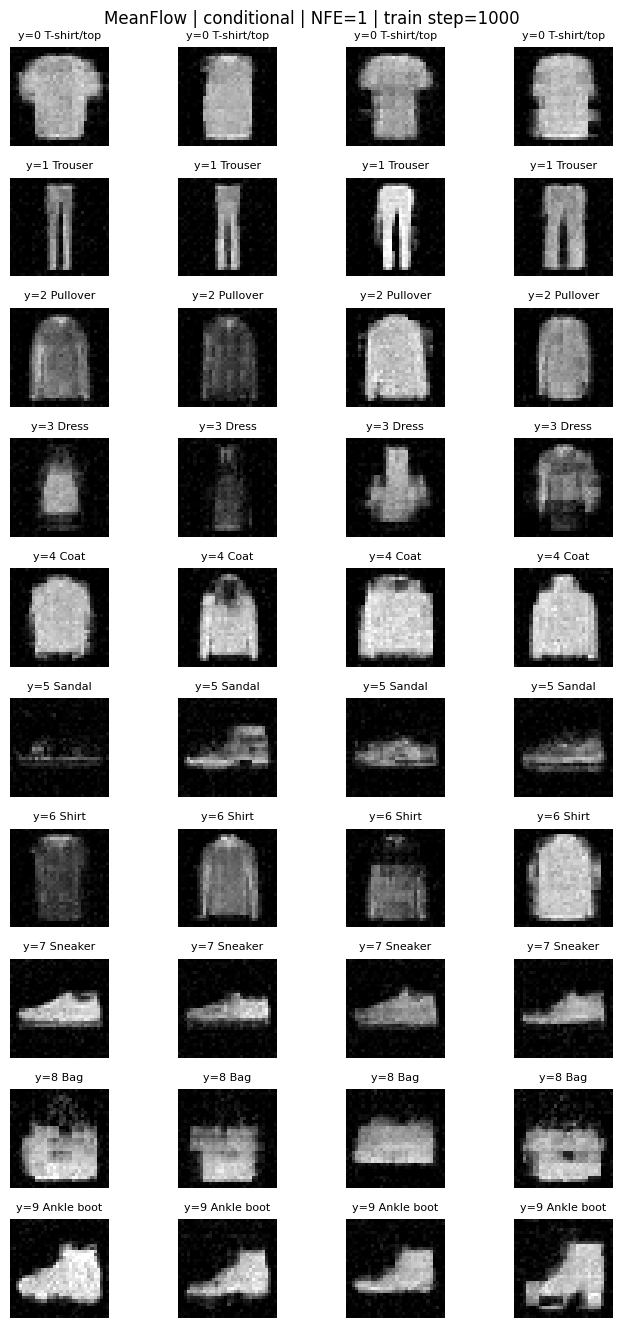

MeanFlow {'step': 1050, 'loss': 0.9999175071716309, 'grad_norm': 3.5060558319091797, 'raw_mse': 0.17917512357234955}
MeanFlow {'step': 1100, 'loss': 0.9999178051948547, 'grad_norm': 3.1048779487609863, 'raw_mse': 0.19438232481479645}
MeanFlow {'step': 1150, 'loss': 0.9999226927757263, 'grad_norm': 2.970707416534424, 'raw_mse': 0.16719099879264832}
MeanFlow {'step': 1200, 'loss': 0.9999251365661621, 'grad_norm': 3.33988881111145, 'raw_mse': 0.3756183385848999}
MeanFlow {'step': 1250, 'loss': 0.999923586845398, 'grad_norm': 2.661797523498535, 'raw_mse': 0.21159830689430237, 'boundary_mse': 0.1497974991798401, 'interval_mse': 0.20335081219673157, 'interval_cosine': 0.9462348222732544}
MeanFlow {'step': 1300, 'loss': 0.9999219179153442, 'grad_norm': 3.6491782665252686, 'raw_mse': 0.23078787326812744}
MeanFlow {'step': 1350, 'loss': 0.9999269247055054, 'grad_norm': 3.5721662044525146, 'raw_mse': 0.2382587045431137}
MeanFlow {'step': 1400, 'loss': 0.9999245405197144, 'grad_norm': 3.318725585

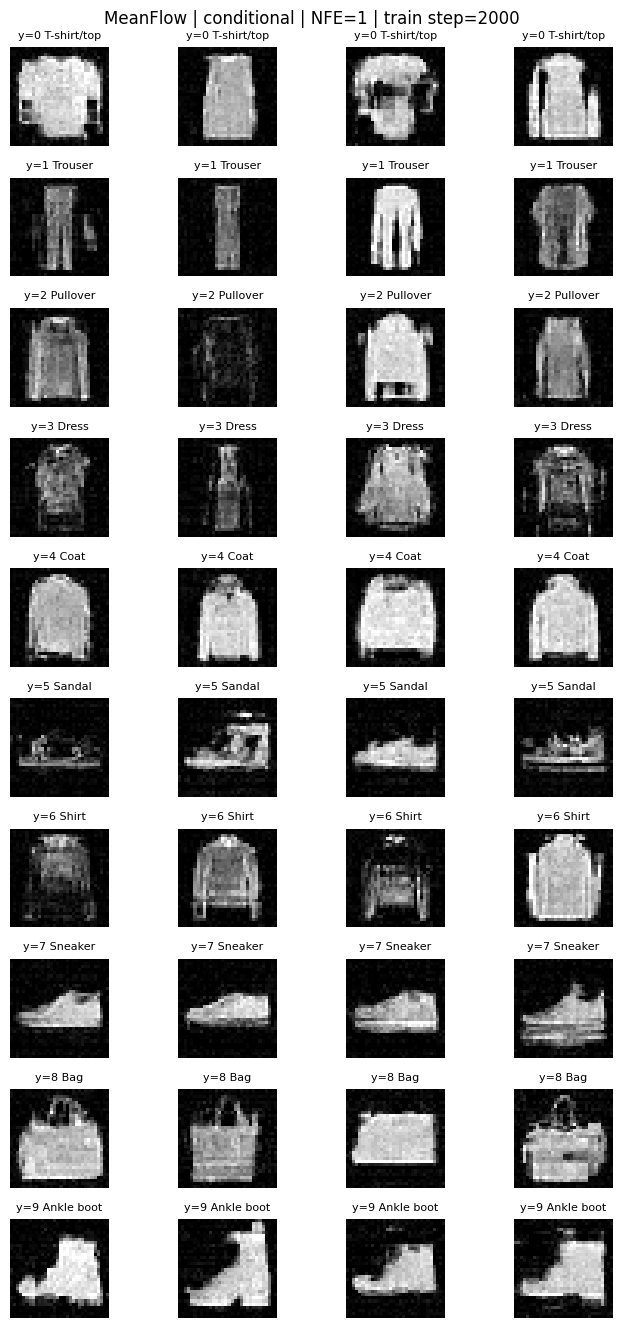

MeanFlow {'step': 2050, 'loss': 0.9999257326126099, 'grad_norm': 3.901949167251587, 'raw_mse': 0.20656633377075195}
MeanFlow {'step': 2100, 'loss': 0.9999197721481323, 'grad_norm': 3.2464747428894043, 'raw_mse': 0.19567391276359558}
MeanFlow {'step': 2150, 'loss': 0.9999188184738159, 'grad_norm': 3.65520977973938, 'raw_mse': 0.20338992774486542}
MeanFlow {'step': 2200, 'loss': 0.999916136264801, 'grad_norm': 3.1698009967803955, 'raw_mse': 0.16227836906909943}
MeanFlow {'step': 2250, 'loss': 0.9999184012413025, 'grad_norm': 2.8606858253479004, 'raw_mse': 0.1744300127029419, 'boundary_mse': 0.14208471775054932, 'interval_mse': 0.17008960247039795, 'interval_cosine': 0.9513412117958069}
MeanFlow {'step': 2300, 'loss': 0.9999161958694458, 'grad_norm': 3.511476993560791, 'raw_mse': 0.1647505760192871}
MeanFlow {'step': 2350, 'loss': 0.9999200701713562, 'grad_norm': 3.604097843170166, 'raw_mse': 0.19752910733222961}
MeanFlow {'step': 2400, 'loss': 0.9999186992645264, 'grad_norm': 4.245091438

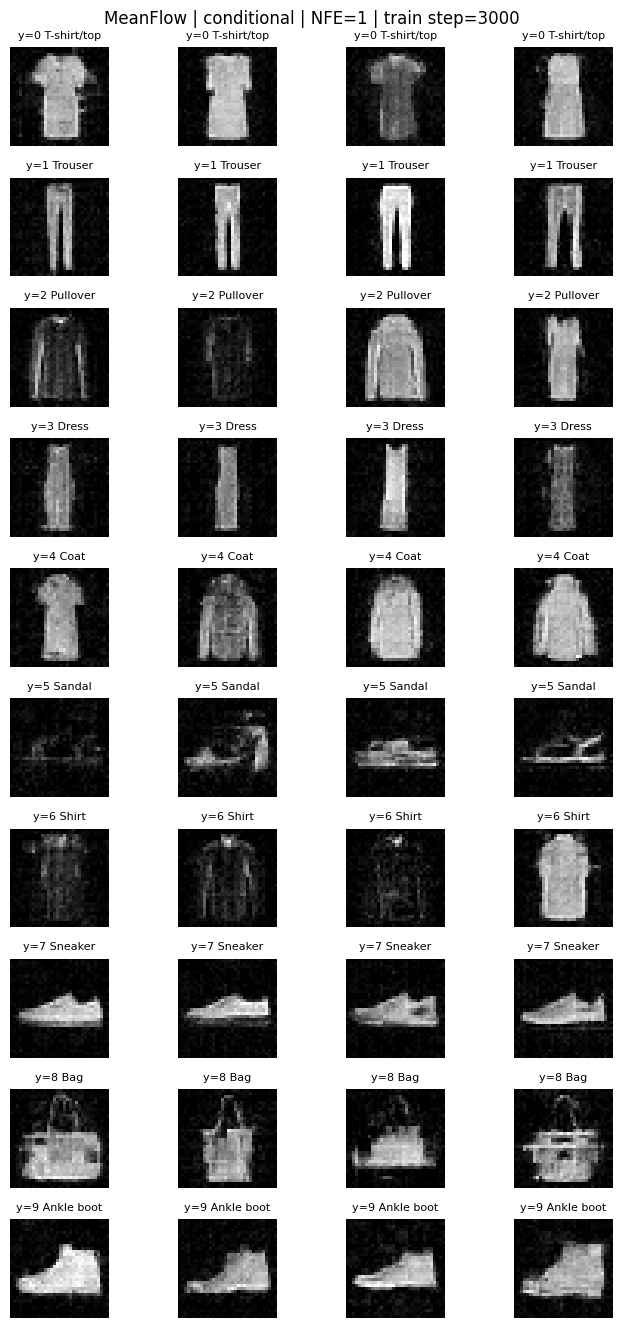

MeanFlow {'step': 3050, 'loss': 0.999919593334198, 'grad_norm': 3.1910128593444824, 'raw_mse': 0.17647863924503326}
MeanFlow {'step': 3100, 'loss': 0.9999092221260071, 'grad_norm': 3.7320494651794434, 'raw_mse': 0.16700491309165955}
MeanFlow {'step': 3150, 'loss': 0.9999147653579712, 'grad_norm': 3.0148708820343018, 'raw_mse': 0.3305635154247284}
MeanFlow {'step': 3200, 'loss': 0.9999172687530518, 'grad_norm': 4.022040367126465, 'raw_mse': 0.16544252634048462}
MeanFlow {'step': 3250, 'loss': 0.99991375207901, 'grad_norm': 3.2998838424682617, 'raw_mse': 0.1556594967842102, 'boundary_mse': 0.13838699460029602, 'interval_mse': 0.25290268659591675, 'interval_cosine': 0.9416316747665405}
MeanFlow {'step': 3300, 'loss': 0.9999125003814697, 'grad_norm': 3.8981168270111084, 'raw_mse': 0.16795441508293152}
MeanFlow {'step': 3350, 'loss': 0.999922513961792, 'grad_norm': 3.106501817703247, 'raw_mse': 0.1862422376871109}
MeanFlow {'step': 3400, 'loss': 0.9999181628227234, 'grad_norm': 3.7661678791

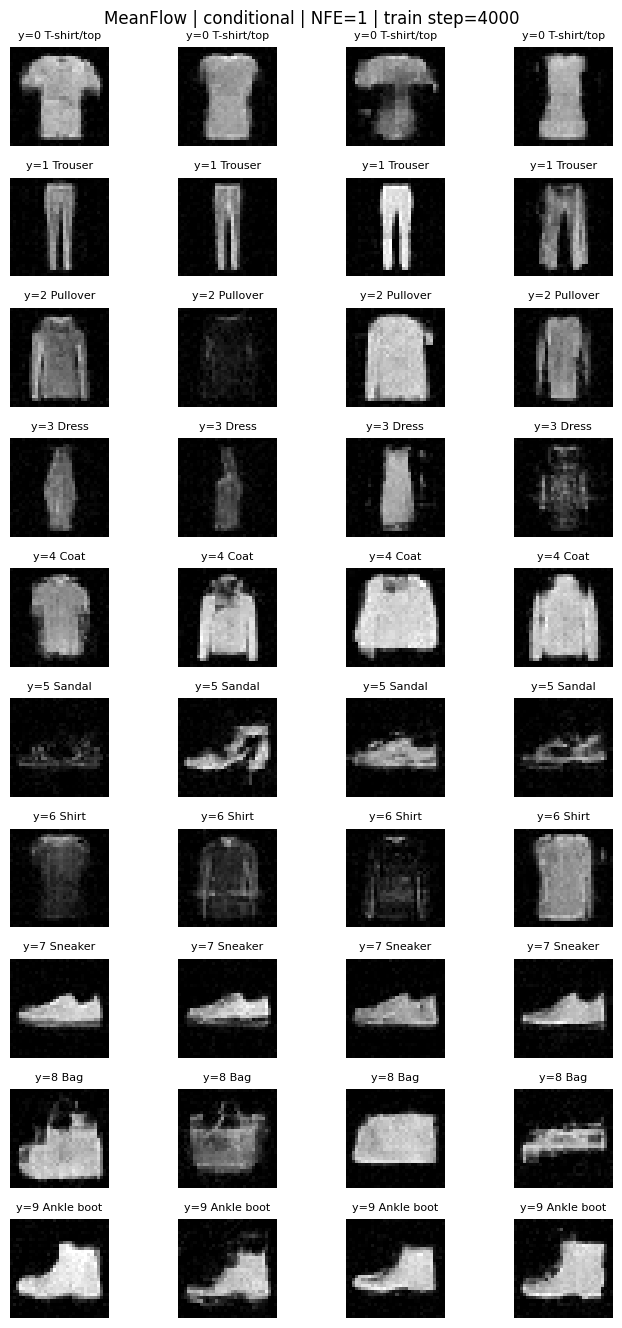

MeanFlow {'step': 4050, 'loss': 0.9999169111251831, 'grad_norm': 4.0500054359436035, 'raw_mse': 0.2075461447238922}
MeanFlow {'step': 4100, 'loss': 0.9999085664749146, 'grad_norm': 3.849442720413208, 'raw_mse': 0.1919325888156891}
MeanFlow {'step': 4150, 'loss': 0.9999204277992249, 'grad_norm': 3.2383148670196533, 'raw_mse': 0.20403340458869934}
MeanFlow {'step': 4200, 'loss': 0.999905526638031, 'grad_norm': 3.061751365661621, 'raw_mse': 0.28095829486846924}
MeanFlow {'step': 4250, 'loss': 0.999910295009613, 'grad_norm': 3.134561538696289, 'raw_mse': 0.1458415538072586, 'boundary_mse': 0.13428637385368347, 'interval_mse': 0.17879344522953033, 'interval_cosine': 0.9510912895202637}
MeanFlow {'step': 4300, 'loss': 0.9999150037765503, 'grad_norm': 3.4818687438964844, 'raw_mse': 0.16408155858516693}
MeanFlow {'step': 4350, 'loss': 0.9999139308929443, 'grad_norm': 3.7097694873809814, 'raw_mse': 0.2202521115541458}
MeanFlow {'step': 4400, 'loss': 0.9999086856842041, 'grad_norm': 3.2817339897

,step,loss,grad_norm,raw_mse,boundary_mse,interval_mse,interval_cosine
96,4800,0.999917,3.280114,0.180715,NaN,NaN,NaN
97,4850,0.999910,3.098518,0.235803,NaN,NaN,NaN
98,4900,0.999915,4.481594,0.208771,NaN,NaN,NaN
99,4950,0.999916,3.273142,0.219693,NaN,NaN,NaN
100,5000,0.999916,4.135655,0.189070,0.138118,0.177673,0.950401


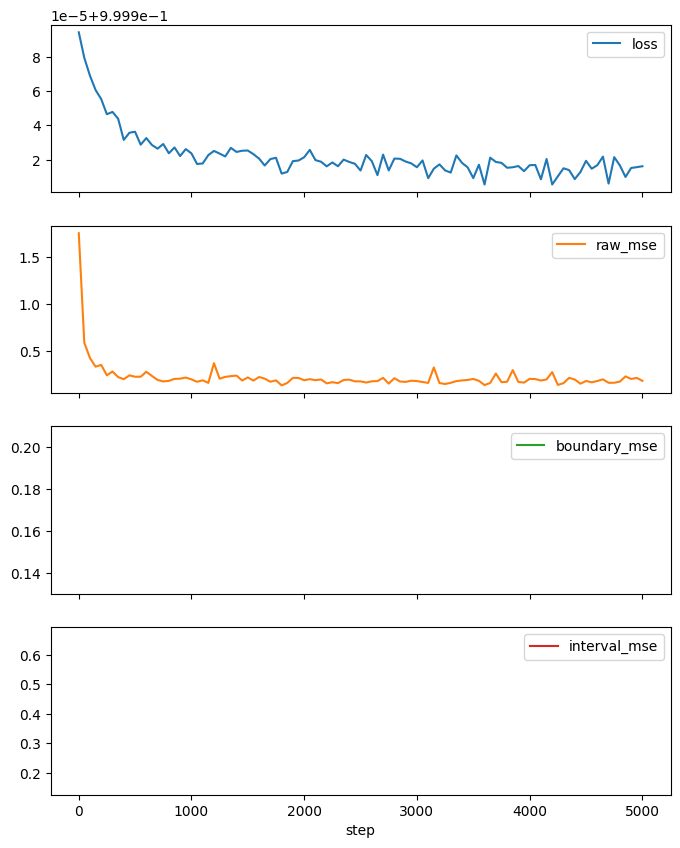

In [30]:
meanflow = train_method(
    "MeanFlow",
    fresh_model(),
    meanflow_loss,
    sample_meanflow,
    diagnostic=meanflow_diagnostic,
)
show_training("MeanFlow")

MeanFlow chain rule / r=t target / one-step update: PASS


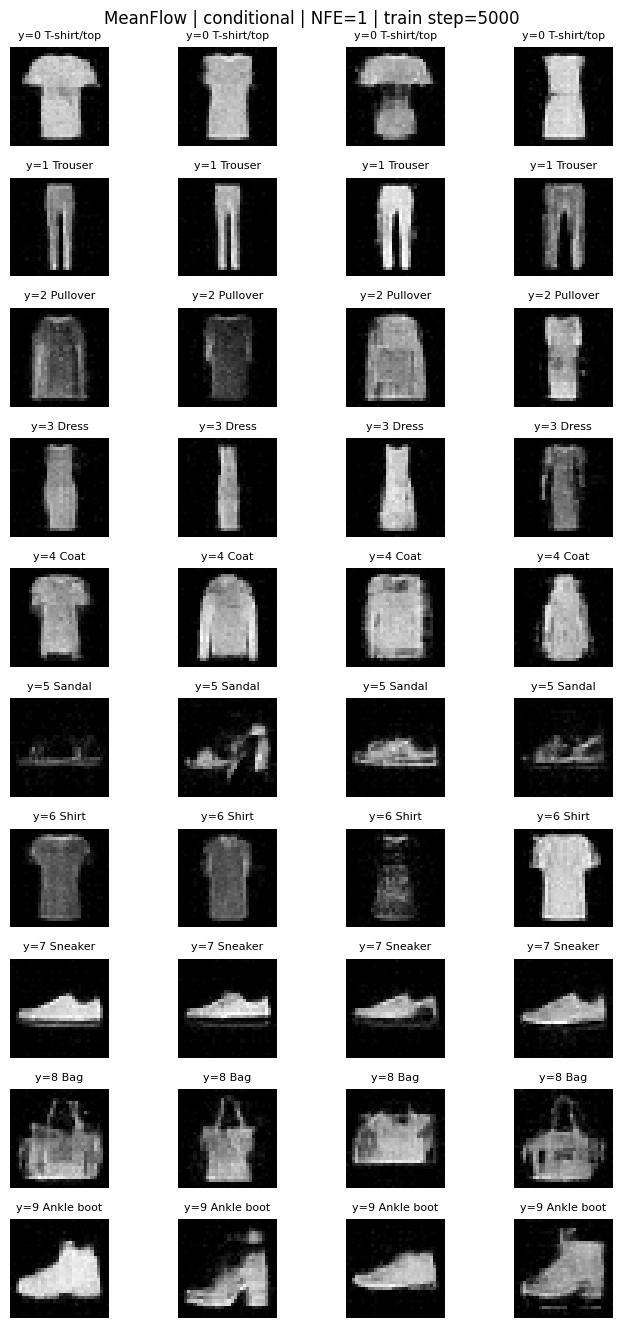

MeanFlow {'feature_fid': 105.95638597457753, 'kid': 78.80963255855539, 'condition_accuracy': 0.8050000071525574, 'class_entropy': 2.2306578159332275, 'train_steps': 5000, 'train_s': 864.8431891119999, 'stop_reason': 'early_stop_at', 'optimizer_backend': 'torch.optim.Muon', 'nfe': 1, 'eval_s': 0.41939095099951373}


/tmp/ipykernel_528/304162648.py:94: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root = sqrtm(real_cov @ fake_cov)


In [31]:
# @title MeanFlow — JVP chain rule / boundary / one-step generation
z, y = make_noise(NUM_CLASSES, SEED), torch.arange(NUM_CLASSES, device=DEVICE)
t = torch.full((len(z),), 0.6, device=DEVICE)
velocity = torch.randn_like(z)
_, boundary_target = meanflow_outputs(meanflow, z, velocity, t, t, y)
assert torch.allclose(boundary_target, velocity)


def analytic_fn(zz, tt, rr):
    return zz + expand_time(tt) + 2 * expand_time(tt - rr)


_, analytic_derivative = jvp(
    analytic_fn, (z, t, t / 2), (velocity, torch.ones_like(t), torch.zeros_like(t))
)
assert torch.allclose(analytic_derivative, velocity + 3)

with torch.no_grad():
    one = torch.ones_like(t)
    assert torch.allclose(
        sample_meanflow(meanflow, z, y, 1), z - meanflow(z, one, one, y)
    )

print("MeanFlow chain rule / r=t target / one-step update: PASS")
show_conditional(
    meanflow,
    sample_meanflow,
    "MeanFlow",
    DEFAULT_NFE["MeanFlow"],
    RUN_INFO["MeanFlow"]["train_steps"],
)
meanflow_samples = evaluate_method("MeanFlow", sample_meanflow)

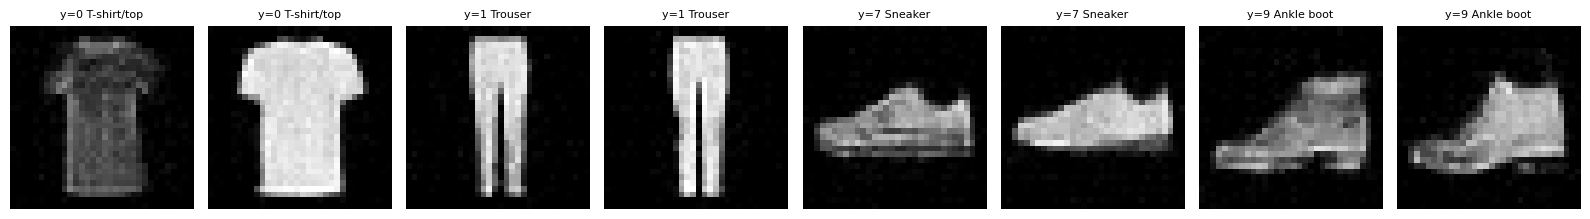

In [32]:
# @title MeanFlow — 원하는 클래스 직접 생성 (라벨·seed·NFE 수정)
# 0 T-shirt, 1 Trouser, 2 Pullover, 3 Dress, 4 Coat,
# 5 Sandal, 6 Shirt, 7 Sneaker, 8 Bag, 9 Ankle boot
requested_labels = [0, 0, 1, 1, 7, 7, 9, 9]
requested_nfe = DEFAULT_NFE["MeanFlow"]
requested_seed = SEED + 20_000
custom_images = generate_conditioned(
    MODELS["MeanFlow"],
    sample_meanflow,
    requested_labels,
    requested_nfe,
    seed=requested_seed,
)
fig, axes = plt.subplots(
    1, len(requested_labels), figsize=(2 * len(requested_labels), 2.5), squeeze=False
)

for ax, image, label in zip(axes.flat, custom_images, requested_labels):
    ax.imshow(((image[0] + 1) / 2).clamp(0, 1), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"y={label} {CLASS_NAMES[label]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. 질문별 비교

공통 표에서는 생성 품질·클래스 일치율·실제 학습 step·시간을 본다. 조기 종료 시점이 다르면 동일 학습 budget의 우열 비교로 해석하지 않는다.
RF2의 총 비용에는 RF1, CTM에는 FM teacher 학습 비용을 더한다. `train_s`에는 해당 절의 teacher 추론·진단·주기적 그림 저장이 포함된다.
CM과 CTM의 EMA target은 학습 목표의 구성 요소다. 최종 생성은 모든 방법에서 마지막 online 가중치를 사용한다.
클래스 조건부 생성은 guidance 추가 호출이 없어 현재 sampler에서는 step 수와 NFE가 같다.


In [33]:
# @title Compare A — final quality and actual training cost
summary = pd.DataFrame(RESULTS).T
summary["total_train_s"] = summary["train_s"]
summary.loc["RF2", "total_train_s"] += RUN_INFO["RF1"]["train_s"]
summary.loc["CTM", "total_train_s"] += RUN_INFO["FM"]["train_s"]
summary["dependency"] = ""
summary.loc["RF2", "dependency"] = "RF1"
summary.loc["CTM", "dependency"] = "FM"
display(
    summary[
        [
            "train_steps",
            "stop_reason",
            "nfe",
            "feature_fid",
            "kid",
            "condition_accuracy",
            "train_s",
            "total_train_s",
            "dependency",
            "optimizer_backend",
        ]
    ]
)
summary.to_csv(RUN_DIR / "summary.csv")

SAMPLERS = {
    "FM": sample_fm,
    "RF1": sample_fm,
    "RF2": sample_fm,
    "CM": sample_cm,
    "CTM": sample_ctm,
    "Shortcut": sample_shortcut,
    "MeanFlow": sample_meanflow,
}

,train_steps,stop_reason,nfe,feature_fid,kid,condition_accuracy,train_s,total_train_s,dependency,optimizer_backend
FM,5000,early_stop_at,16,16.403291,11.831841,0.876,527.902088,527.902088,,torch.optim.Muon
RF1,5000,early_stop_at,16,16.553736,12.832196,0.865,526.696747,526.696747,,torch.optim.Muon
RF2,5000,early_stop_at,16,22.72311,18.878139,0.843,4387.703554,4914.4003,RF1,torch.optim.Muon
CM,5000,early_stop_at,1,989.902951,272.311593,0.1,647.049655,647.049655,,torch.optim.Muon
CTM,5000,early_stop_at,2,77.777608,70.339419,0.852,2348.620046,2876.522134,FM,torch.optim.Muon
Shortcut,5000,early_stop_at,1,49.89743,42.38333,0.86,597.493982,597.493982,,torch.optim.Muon
MeanFlow,5000,early_stop_at,1,105.956386,78.809633,0.805,864.843189,864.843189,,torch.optim.Muon


/tmp/ipykernel_528/304162648.py:94: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root = sqrtm(real_cov @ fake_cov)


{'method': 'FM', 'nfe': 1, 'feature_fid': 230.65682014851197, 'kid': 129.0742371248913, 'condition_accuracy': 0.8320000171661377, 'class_entropy': 2.1286377906799316}
{'method': 'FM', 'nfe': 2, 'feature_fid': 102.04921723329798, 'kid': 65.85651268393707, 'condition_accuracy': 0.9150000214576721, 'class_entropy': 2.277338743209839}
{'method': 'FM', 'nfe': 4, 'feature_fid': 45.81802140424004, 'kid': 33.270918097409435, 'condition_accuracy': 0.9089999794960022, 'class_entropy': 2.284337282180786}
{'method': 'FM', 'nfe': 8, 'feature_fid': 24.393496559827348, 'kid': 18.548043080663547, 'condition_accuracy': 0.8899999856948853, 'class_entropy': 2.2890753746032715}
{'method': 'FM', 'nfe': 16, 'feature_fid': 16.4032913643443, 'kid': 11.831840693237211, 'condition_accuracy': 0.8759999871253967, 'class_entropy': 2.287550926208496}
{'method': 'RF1', 'nfe': 1, 'feature_fid': 241.31046449188938, 'kid': 135.0571039323433, 'condition_accuracy': 0.875, 'class_entropy': 2.2026562690734863}
{'method': '

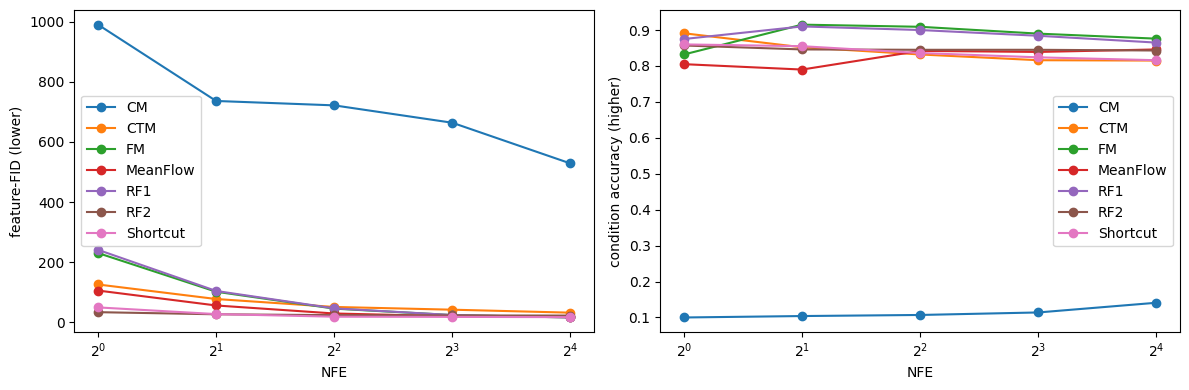

In [34]:
# @title Compare B — matched labels/noise, NFE-quality curves
budget_rows = []
eval_labels = balanced_labels(EVAL_N)

for name, sampler in SAMPLERS.items():
    for nfe in NFE_LIST:
        fake = generate_conditioned(MODELS[name], sampler, eval_labels, nfe)
        row = {"method": name, "nfe": nfe, **quality_metrics(fake, eval_labels)}
        budget_rows.append(row)
        print(row)

budget_table = pd.DataFrame(budget_rows)
budget_table.to_csv(RUN_DIR / "nfe_quality.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, group in budget_table.groupby("method"):
    axes[0].plot(group.nfe, group.feature_fid, marker="o", label=name)
    axes[1].plot(group.nfe, group.condition_accuracy, marker="o", label=name)

for ax, ylabel in zip(axes, ("feature-FID (lower)", "condition accuracy (higher)")):
    ax.set_xscale("log", base=2)
    ax.set_xlabel("NFE")
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.show()

In [35]:
# @title Compare C — FM vs RF trajectory geometry
def path_geometry(trajectory):
    flat = trajectory.float().flatten(2)
    increments = flat[1:] - flat[:-1]
    length = increments.norm(dim=-1).sum(0)
    chord = (flat[-1] - flat[0]).norm(dim=-1).clamp_min(1e-8)
    curvature = (flat[2:] - 2 * flat[1:-1] + flat[:-2]).norm(dim=-1).mean()

    return {
        "path_length_ratio": float((length / chord).mean()),
        "discrete_curvature": float(curvature),
    }


geometry_labels = balanced_labels(NUM_CLASSES * SAMPLES_PER_CLASS)
geometry_noise = make_noise(len(geometry_labels), SEED + 10_000)
geometry_rows = []

for name in ("FM", "RF1", "RF2"):
    trajectories = []

    for start in range(0, len(geometry_labels), SAMPLE_BATCH):
        noise = geometry_noise[start : start + SAMPLE_BATCH]
        labels = geometry_labels[start : start + SAMPLE_BATCH]
        t = torch.ones(len(noise), device=DEVICE)
        _, trajectory = integrate_fm(
            MODELS[name],
            noise,
            t,
            torch.zeros_like(t),
            labels,
            RF_TEACHER_NFE,
            return_traj=True,
        )
        trajectories.append(trajectory)

    geometry_rows.append(
        {"method": name, **path_geometry(torch.cat(trajectories, dim=1))}
    )

display(pd.DataFrame(geometry_rows))
print(
    "Reflow 이후 경로가 더 곧아졌는지는 측정 결과로 판단합니다. 품질 향상과 동일한 조건은 아닙니다."
)

,method,path_length_ratio,discrete_curvature
0,FM,1.012493,0.036317
1,RF1,1.012435,0.035440
2,RF2,1.000586,0.008122


Reflow 이후 경로가 더 곧아졌는지는 측정 결과로 판단합니다. 품질 향상과 동일한 조건은 아닙니다.


### CM과 CTM에서 확인할 차이

CM은 하나의 noise level에서 near-data endpoint를 반환한다. 반복 생성은 예측한 endpoint에 다시 noise를 더해 수행한다.
CTM은 시작·도착시간을 받아 중간 위치를 반환하므로, 같은 라벨에서 `t→s→r`과 `t→r`의 composition을 비교할 수 있다.
CM의 additive noise와 CTM의 linear FM teacher는 서로 다른 경로다. 아래 CM 지표는 인접 CT 입력의 차이, CTM 지표는 map composition 오차로 각각 해석한다.


In [36]:
# @title Compare D — CM adjacent consistency / CTM composition
with torch.no_grad(), isolated_rng():
    images, labels = next(iter(test_loader))
    images, labels = images[:SAMPLE_BATCH].to(DEVICE), labels[:SAMPLE_BATCH].to(DEVICE)
    noise = torch.randn_like(images)
    grid = cm_grid_size(max(1, RUN_INFO["CM"]["train_steps"]))
    i = torch.randint(1, grid + 1, (len(images),), device=DEVICE)
    sigma, lower = (
        cm_noise_levels(i.float() / grid),
        cm_noise_levels((i.float() - 1) / grid),
    )
    a = cm_f(cm, images + expand_time(sigma) * noise, sigma, labels)
    b = cm_f(cm, images + expand_time(lower) * noise, lower, labels)
    cm_adjacent_mse = float(F.mse_loss(a, b))
    t, s, r = (
        torch.full((len(images),), value, device=DEVICE) for value in (1.0, 0.5, 0.0)
    )
    direct = ctm_map(ctm, noise, t, r, labels)
    composed = ctm_map(ctm, ctm_map(ctm, noise, t, s, labels), s, r, labels)
    print(
        {
            "cm_adjacent_ct_mse": cm_adjacent_mse,
            "ctm_composition_mse": float(F.mse_loss(direct, composed)),
        }
    )

{'cm_adjacent_ct_mse': 0.0005582452868111432, 'ctm_composition_mse': 0.007290135603398085}


## 8. Flow Map 관점 — 조건부 finite-time map

공통 입력 공간은 \(\mathbb R^{1\times32\times32}\), 클래스 \(y\)는 모든 이동 동안 고정한다.
FM/RF는 ODE 적분, CTM은 trajectory map, Shortcut은 전진 구간 속도, MeanFlow는 역방향 평균 속도로 이동을 표현한다.
CM은 noise scale에서 \(\sigma_\min\) endpoint로 가는 특수한 map이다. 임의 구간 이동으로 확장해 해석하지 않는다.

GFM 논문의 Euclidean 관점으로 기존 함수를 재표현한다. 이 절에서는 새 모델을 학습하지 않는다.
representation 등식은 구현 검증이고, composition 오차는 학습 결과의 진단이다. MeanFlow composition은 직접 학습한 손실이 아니다.


In [37]:
# @title Flow Map — adapters and identity checks with labels
@torch.no_grad()
def flow_map(name, model, z, t, s, labels, nfe=16):
    if name in ("FM", "RF1", "RF2"):
        return integrate_fm(model, z, t, s, labels, nfe)

    if name == "CTM":
        return ctm_map(model, z, t, s, labels)

    if name == "MeanFlow":
        return z - expand_time(t - s) * model(z, t, t - s, labels)

    if name == "Shortcut":
        return z + expand_time(s - t) * model(z, t, s - t, labels)

    raise ValueError("CM uses its own noise-scale endpoint adapter")


@torch.no_grad()
def cm_endpoint_map(model, z, sigma, labels):
    return cm_f(model, z, sigma, labels)


z, labels = make_noise(NUM_CLASSES, SEED), torch.arange(NUM_CLASSES, device=DEVICE)
one = torch.ones(len(z), device=DEVICE)
zero = torch.zeros_like(one)

with torch.no_grad():
    for name in ("FM", "RF1", "RF2", "CTM", "MeanFlow"):
        nfe = DEFAULT_NFE[name] if name in ("FM", "RF1", "RF2") else 1
        mapped = flow_map(name, MODELS[name], z, one, zero, labels, nfe=nfe)
        sampled = SAMPLERS[name](MODELS[name], z, labels, nfe)
        assert torch.allclose(mapped, sampled, atol=1e-6)

    assert torch.allclose(
        flow_map("Shortcut", shortcut, z, zero, one, labels),
        sample_shortcut(shortcut, z, labels, 1),
        atol=1e-6,
    )
    sigma = torch.full_like(one, CM_SIGMA_MAX)
    assert torch.allclose(
        cm_endpoint_map(cm, CM_SIGMA_MAX * z, sigma, labels),
        sample_cm(cm, z, labels, 1),
        atol=1e-5,
        rtol=1e-5,
    )

print("Conditional flow-map adapters equal sampler updates: PASS")

composition_rows = []

for name in ("CTM", "Shortcut", "MeanFlow"):
    t, r = (zero, one) if name == "Shortcut" else (one, zero)
    s = (t + r) / 2
    direct = flow_map(name, MODELS[name], z, t, r, labels)
    middle = flow_map(name, MODELS[name], z, t, s, labels)
    composed = flow_map(name, MODELS[name], middle, s, r, labels)
    composition_rows.append(
        {"method": name, "composition_mse": float(F.mse_loss(direct, composed))}
    )

display(pd.DataFrame(composition_rows))

Conditional flow-map adapters equal sampler updates: PASS


,method,composition_mse
0,CTM,0.010989
1,Shortcut,0.007626
2,MeanFlow,0.026088


### 해석 순서

1. 실행 검증이 통과했는지 확인한다. 통과는 학습 수렴이나 생성 품질을 보장하지 않는다.
2. 각 모델의 클래스별 그림에서 요청한 의류 형태가 나오는지 확인한다.
3. raw error와 조건 일치율, NFE-quality 곡선을 함께 본다.
4. 실제 학습 step, 중단 이유, teacher 비용을 확인한 뒤 모델 간 결과를 비교한다.
5. 모든 모델의 기본 중단 시점은 각각 5,000 step이다. RF1과 RF2는 각 단계에서 5,000 step씩 학습한다. 모델별 조정은 `EARLY_STOP_AT`에서 지정한다.

각 모델 폴더에는 조건부 생성 PNG, `training.csv`, `last.pt`가 저장된다. 체크포인트는 현재 모델·optimizer·CM/CTM target·설정·중단 step을 담는다.
데이터 iterator 위치를 복원하는 완전 동일한 재개 기능은 포함하지 않는다. 새 실습을 재실행하면 별도의 run 폴더를 만든다.
